In [4]:
using NeuralPDE, Lux, Plots, DifferentialEquations, Distributions, Random
using BiochemicalAlgorithms
BA = BiochemicalAlgorithms
using Distributions

┌ Warning: Error requiring `Symbolics` from `Optimization`
│   exception = (LoadError("C:\\Users\\Dan\\.julia\\packages\\Optimization\\fPVIW\\ext\\OptimizationSparseDiffExt.jl", 1, ArgumentError("Package Optimization does not have ReverseDiff in its dependencies:\n- You may have a partially installed environment. Try `Pkg.instantiate()`\n  to ensure all packages in the environment are installed.\n- Or, if you have Optimization checked out for development and have\n  added ReverseDiff as a dependency but haven't updated your primary\n  environment's manifest file, try `Pkg.resolve()`.\n- Otherwise you may need to report an issue with Optimization")), Union{Ptr{Nothing}, Base.InterpreterIP}[Ptr{Nothing} @0x0000026e576dbec4, Ptr{Nothing} @0x0000026e576dc13a, Ptr{Nothing} @0x00007ffda1878434, Ptr{Nothing} @0x00007ffda187a02e, Ptr{Nothing} @0x00007ffda18797ec, Ptr{Nothing} @0x00007ffda18799a6, Ptr{Nothing} @0x00007ffda187ac1e, Ptr{Nothing} @0x00007ffd80b191da, Ptr{Nothing} @0x0000026e576d6e

In [5]:
#NeuralPDE setup
function MDS(du,u,p,t)
    mm = p
    atoms_df(mm.system).r = u
    atoms_df(mm.system).v = du
    compute_forces(mm)
    return [x for x in atoms_df(mm.system).F]
end

MDS (generic function with 1 method)

In [3]:
function old_sim()
    #system setup. Vel = F = 0
    sys = load_sdfile("../glucose.sdf")
    mm = MMFF94FF(sys)
    BA.update!(mm)
    nothing

    n = size(atoms_df(mm.system).v)[1]
    du0 = similar(atoms_df(mm.system).v)
    for v in 1:length(du0)
        du0[v] = Vector3(rand(-5e-20:5e-20), rand(-5e-20:5e-20), rand(-5e-20:5e-20))
    end
    u0 = similar(atoms_df(mm.system).r)
    p = mm
    tspan = (Float32(0.0), Float32(10.0))
    prob = SecondOrderODEProblem(MDS, du0, u0, tspan, p)


    sol = solve(prob)
    g = plot_pde(sol, mm, tspan, 100,2)
    #sols = [sol(i) for i in 0:0.1:10]
    #nothing
end

old_sim (generic function with 1 method)

In [4]:
#plot. old
#xl = extrema([pos.x for sol in sols for pos in sol]) .* 2
#yl = extrema([pos.y for sol in sols for pos in sol]) .* 2
#zl = extrema([pos.z for sol in sols for pos in sol]) .* 2
#xl = (floor(xl[1]), ceil(xl[1]))
#yl = (floor(yl[1]), ceil(yl[2]))
#zl = (floor(zl[1]), ceil(zl[2]))

#@gif for i in 1:length(sols)
#    Plots.plot(xlim=xl, ylim=yl, zlim=zl, legend=nothing)
#    Plots.plot!([pos.x for sol in sols for pos in sol],[pos.y for sol in sols for pos in sol], [pos.z for sol in sols for pos in sol], linealpha=1)
#    Plots.scatter!([pos.x for sol in sols for pos in sol],[pos.y for sol in sols for pos in sol], [pos.z for sol in sols for pos in sol], linealpha=1, color="blue", msize=6)
#end every 5

In [2]:
#create water MMFF94
function sep(names)
    name = first(names)
    load_op = endswith(name,".sdf") ? load_sdfile : load_pdb
    sys = load_op(name)
    d = Dict()

    for name in names[2:end]
        load_op = endswith(name,".sdf") ? load_sdfile : load_pdb
        new_sys = load_op(name)
        m = Molecule(sys)

        for at in atoms(new_sys)
            number  = maximum(atoms_df(sys).number) + 1
            new_at = Atom(m, number, at.element, at.name, at.atom_type, at.r, at.v, at.F,
                at.formal_charge, at.charge, at.radius, at.properties, at.flags)
            d[at.idx] = new_at.idx
        end

        for bond in bonds(new_sys)
            Bond(sys, d[bond.a1], d[bond.a2], bond.order, bond.properties, bond.flags)
        end

    end 
    return sys
end

function central(sys::BA.System{T}, dist) where T <:Real
    cent = molecules(sys)[1]
    mean_c = Vector3{T}(mean(atoms_df(cent).r))
    rotz(a) = [cos(deg2rad(a)) -sin(deg2rad(a)) 0; sin(deg2rad(a)) cos(deg2rad(a)) 0; 0 0 1]
    mov(a,b) = b-a

    rot = 360/(length(molecules(sys))-1)
    for (i,m) in enumerate(molecules(sys)[2:end])
        mean_m = Vector3{T}(mean(atoms_df(m).r))
        #move molecule onto central molecule
        atoms_df(m).r = map(at-> at + mov(mean_m, mean_c), atoms_df(m).r)
        #move molecule a certain dist away
        atoms_df(m).r = map(at-> at + Vector3{T}(dist, 0, 0), atoms_df(m).r)
        #move molecule to origin
        atoms_df(m).r = map(at-> at + mov(mean_c, Vector3{T}(0,0,0)), atoms_df(m).r)
        #rotate
        atoms_df(m).r = map(at -> Vector3{T}(rotz(i*rot) *at) , atoms_df(m).r)
        #move molec back around central mol
        atoms_df(m).r = map(at-> at + mean_c, atoms_df(m).r)
    end

end



central (generic function with 1 method)

In [19]:
function sim_pde(mm,tspan=(0f0,10f0), alg = nothing, deetee = 1e-3)
    du0 = [atoms_df(mm.system).v...]
    u0 = [atoms_df(mm.system).r...]
    p = mm
    prob = SecondOrderODEProblem(MDS, du0, u0, tspan, p)
    sol = if isnothing(alg)
        solve(prob)
    else
        solve(prob, alg(), dt=deetee)
    end

end

function plot_pde(sols, mm, tspan, evals, every_)
    d = Dict(id.idx => i for (i, id) in enumerate(atoms(mm.system)) ) 
    half = Int(floor(length(sols.u[1])/2))+1

    sim = [sols(i)[half:end] for i in range(tspan..., length = evals)]
    
    x_vals = [[at[1] for at in iter] for iter in sim]
    y_vals = [[at[2] for at in iter] for iter in sim]
    z_vals = [[at[3] for at in iter] for iter in sim]

    xl = extrema(Iterators.flatten(x_vals))
    xl = (floor(xl[1]), ceil(xl[2]))
    yl = extrema(Iterators.flatten(y_vals))
    yl = (floor(yl[1]), ceil(yl[2]))
    zl = extrema(Iterators.flatten(z_vals))
    zl = (floor(zl[1]), ceil(zl[2]))


    g = @gif for i in 1:evals
        Plots.plot(zlim=(-1,1), xlim=xl, ylim=yl, legend=nothing, dpi=600)
        for bond in bonds(mm.system) 
            Plots.plot!(
                [b for b in x_vals[i][[d[bond.a1], d[bond.a2]]]],
                [b for b in y_vals[i][[d[bond.a1], d[bond.a2]]]],
                [b for b in z_vals[i][[d[bond.a1], d[bond.a2]]]]
            )
        end
    end every every_
    return g
end

function plot_sol(sol, mm, every_)

    d = Dict(id.idx => i for (i, id) in enumerate(atoms(mm.system)) ) 
    half = Int(floor(length(sol.u[1])/2))+1

    sim = [sol[i][half:end] for i in 1:length(sol)]

    x_vals = [[at[1] for at in iter] for iter in sim]
    y_vals = [[at[2] for at in iter] for iter in sim]
    z_vals = [[at[3] for at in iter] for iter in sim]

    xl = extrema(Iterators.flatten(x_vals))
    xl = (floor(xl[1]), ceil(xl[2]))
    yl = extrema(Iterators.flatten(y_vals))
    yl = (floor(yl[1]), ceil(yl[2]))
    zl = extrema(Iterators.flatten(z_vals))
    zl = (floor(zl[1]), ceil(zl[2]))


    g = @gif for i in 1:length(sim)
        Plots.plot(zlim=(-1,1), xlim=xl, ylim=yl, legend=nothing, dpi=600)
        for bond in bonds(mm.system) 
            Plots.plot!(
                [b for b in x_vals[i][[d[bond.a1], d[bond.a2]]]],
                [b for b in y_vals[i][[d[bond.a1], d[bond.a2]]]],
                [b for b in z_vals[i][[d[bond.a1], d[bond.a2]]]]
            )
        end
    end every every_
    return g
end

plot_sol (generic function with 1 method)

┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574
┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_gH436hArgF.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_gH436hArgF.gif")
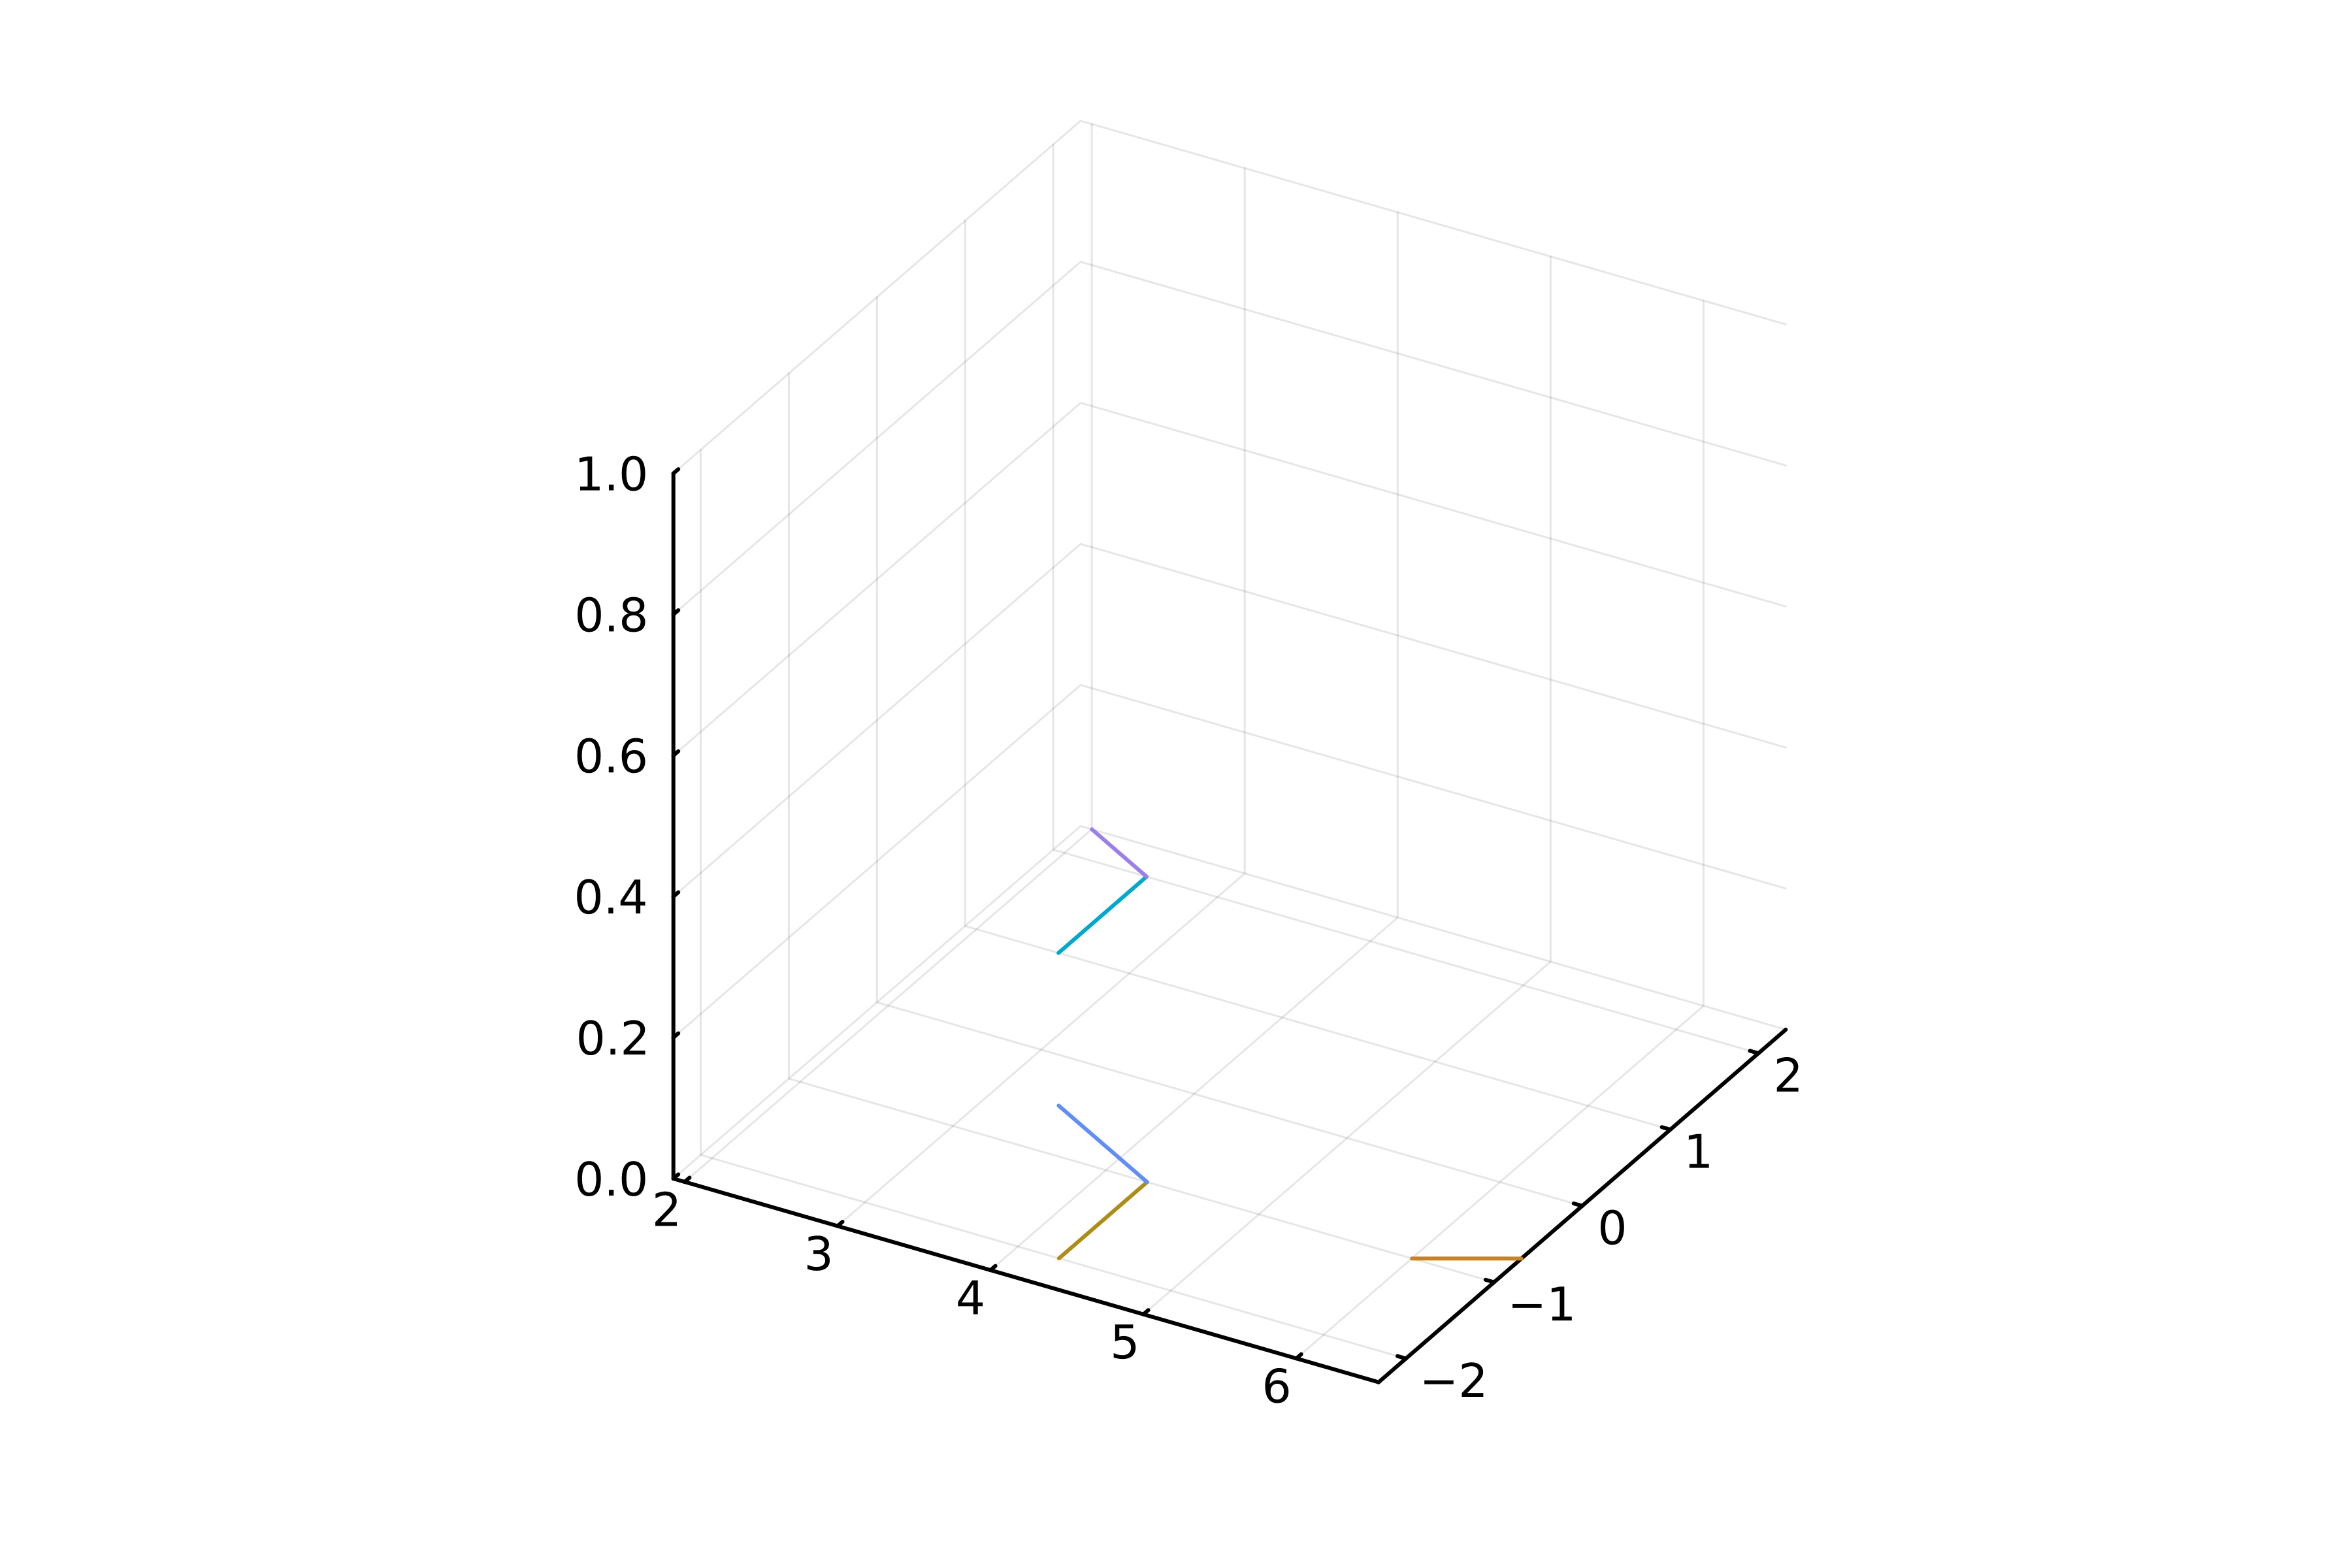

In [7]:
copies = 0
dist = 1.7
tspan = (0f0,1f0)

#sys = sep(vcat("../water.sdf",repeat(["../water.sdf"],copies)))
#atoms_df(sys).r .*= Vector3(2,2,2)
#central(sys,dist)#
sys = load_sdfile("../glucose.sdf")
mm = MMFF94FF(sys)
BA.update!(mm)
sol = sim_pde(mm, tspan)

g = plot_pde(sol, mm, tspan, 100,5)
display(g)

┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Info: 2 unassigned Out Of Plane Bends.
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_out_of_plane_bend.jl:78
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:606


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_e12byHsLy9.gif")
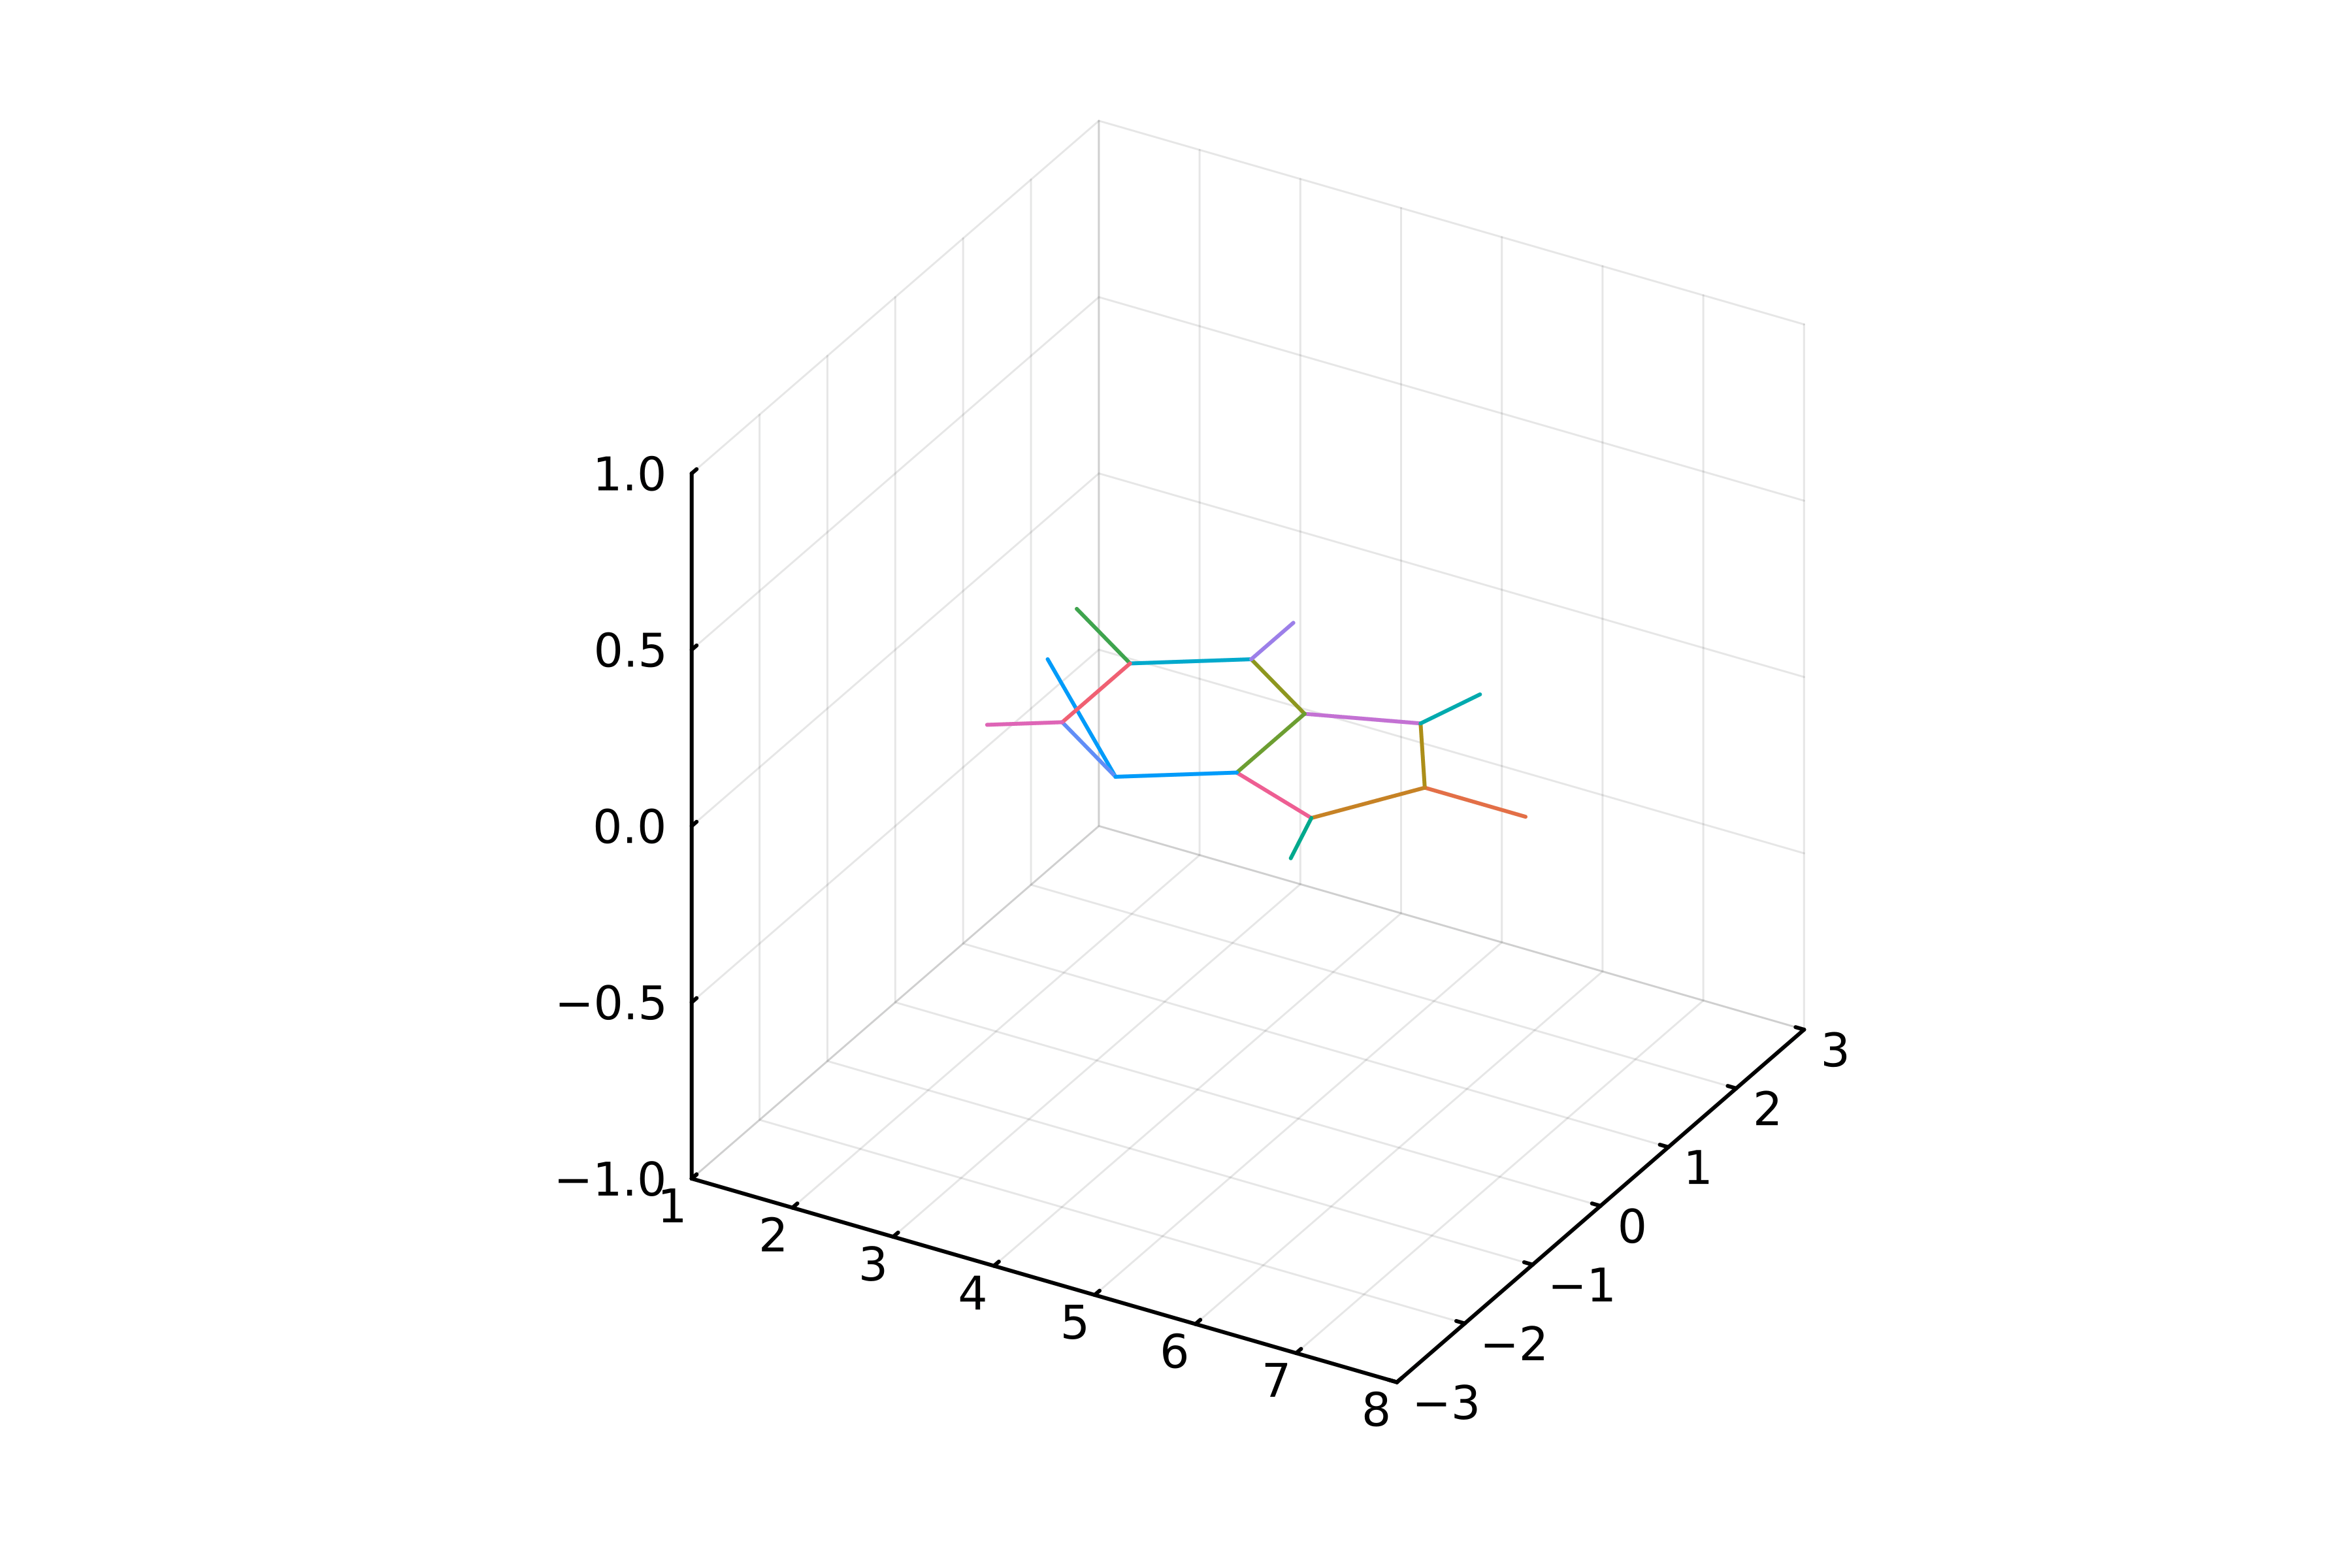

Integrator: SymplecticEuler


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_e12byHsLy9.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156


In [23]:
#algs = [VelocityVerlet, SymplecticEuler, VerletLeapfrog, PseudoVerletLeapfrog, McAte2,]
#for alg in algs
    tspan = (0f0, 10000f0)
    sys = load_sdfile("../Structure2D_COMPOUND_CID_1175.sdf")
    mm = MMFF94FF(sys)
    first(atoms(mm.system)).r += Vector3(0,0,0.5)
    BA.update!(mm)
    sol = sim_pde(mm, tspan, SymplecticEuler, 1e2)
    #g = plot_pde(sol, mm, tspan, 1000,1)
    g = plot_sol(sol, mm, 1)

    println("Integrator: $SymplecticEuler")
    display(g)
#end


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_S3qncbQD25.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_S3qncbQD25.gif")
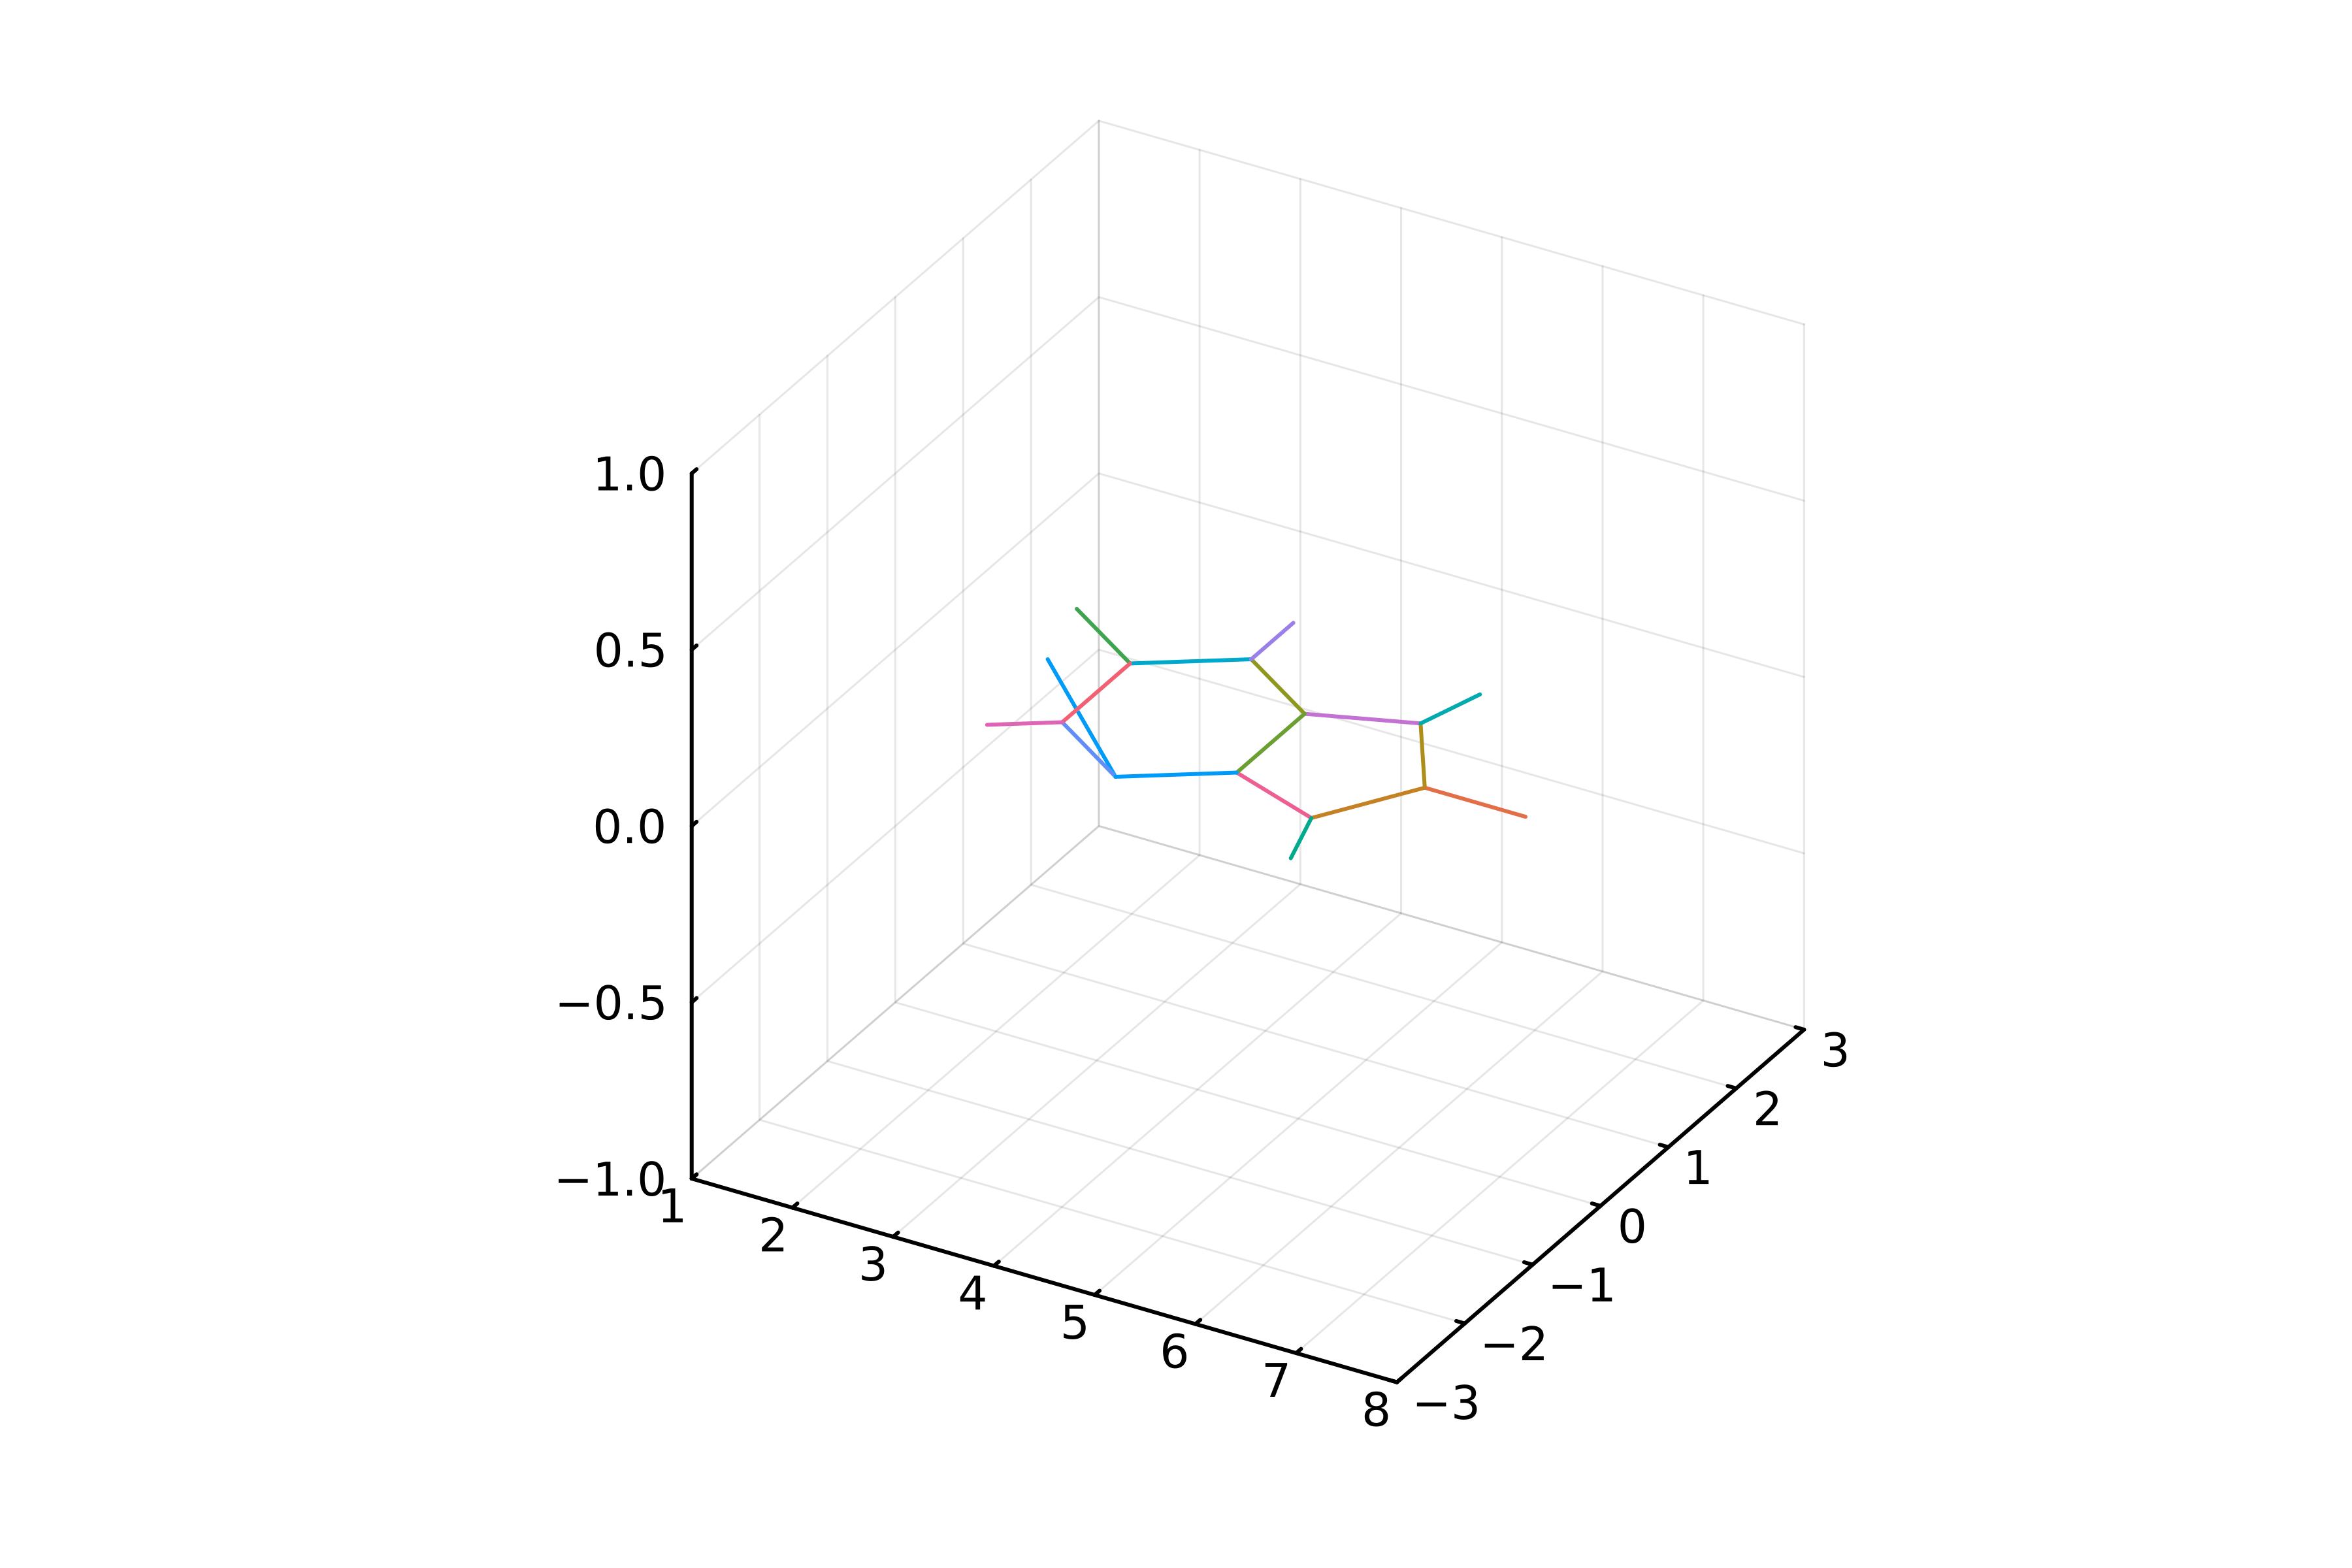

In [20]:
plot_sol(sol, mm, 1)


┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_s7yxUlwdMP.gif")
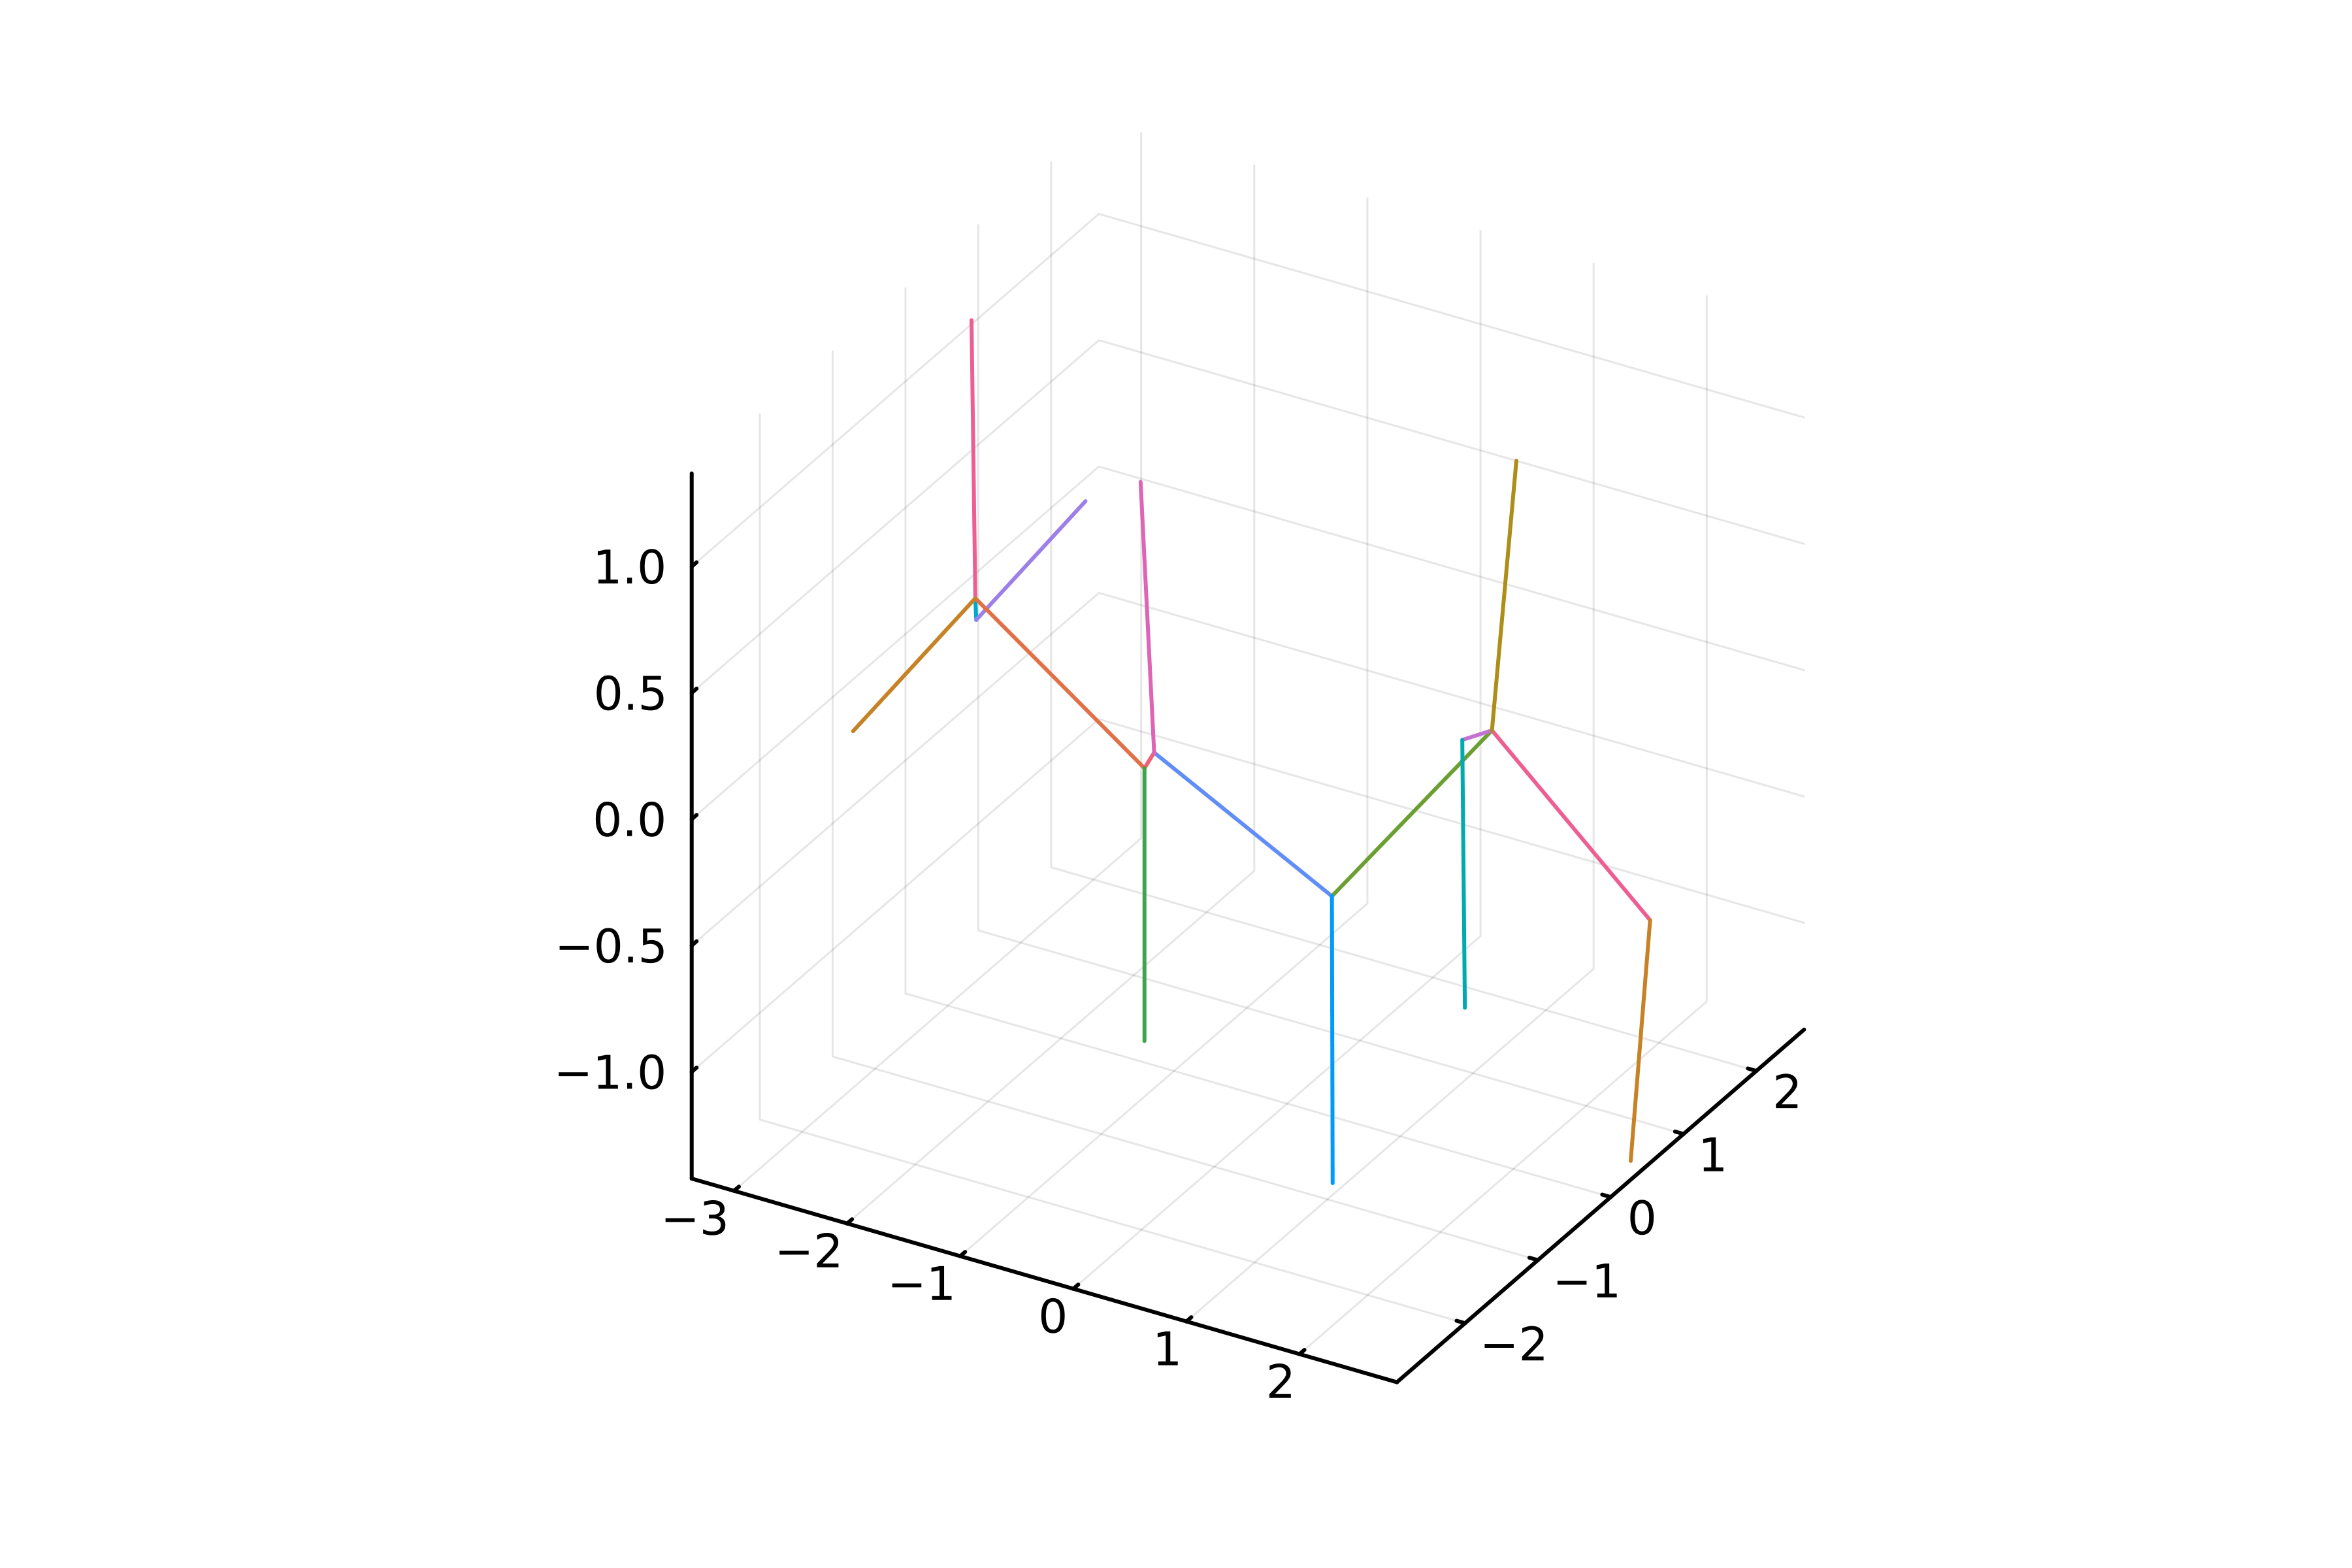

../Conformer3D_COMPOUND_CID_5793.sdf

┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_s7yxUlwdMP.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156


┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_e5kRCBOhoT.gif")
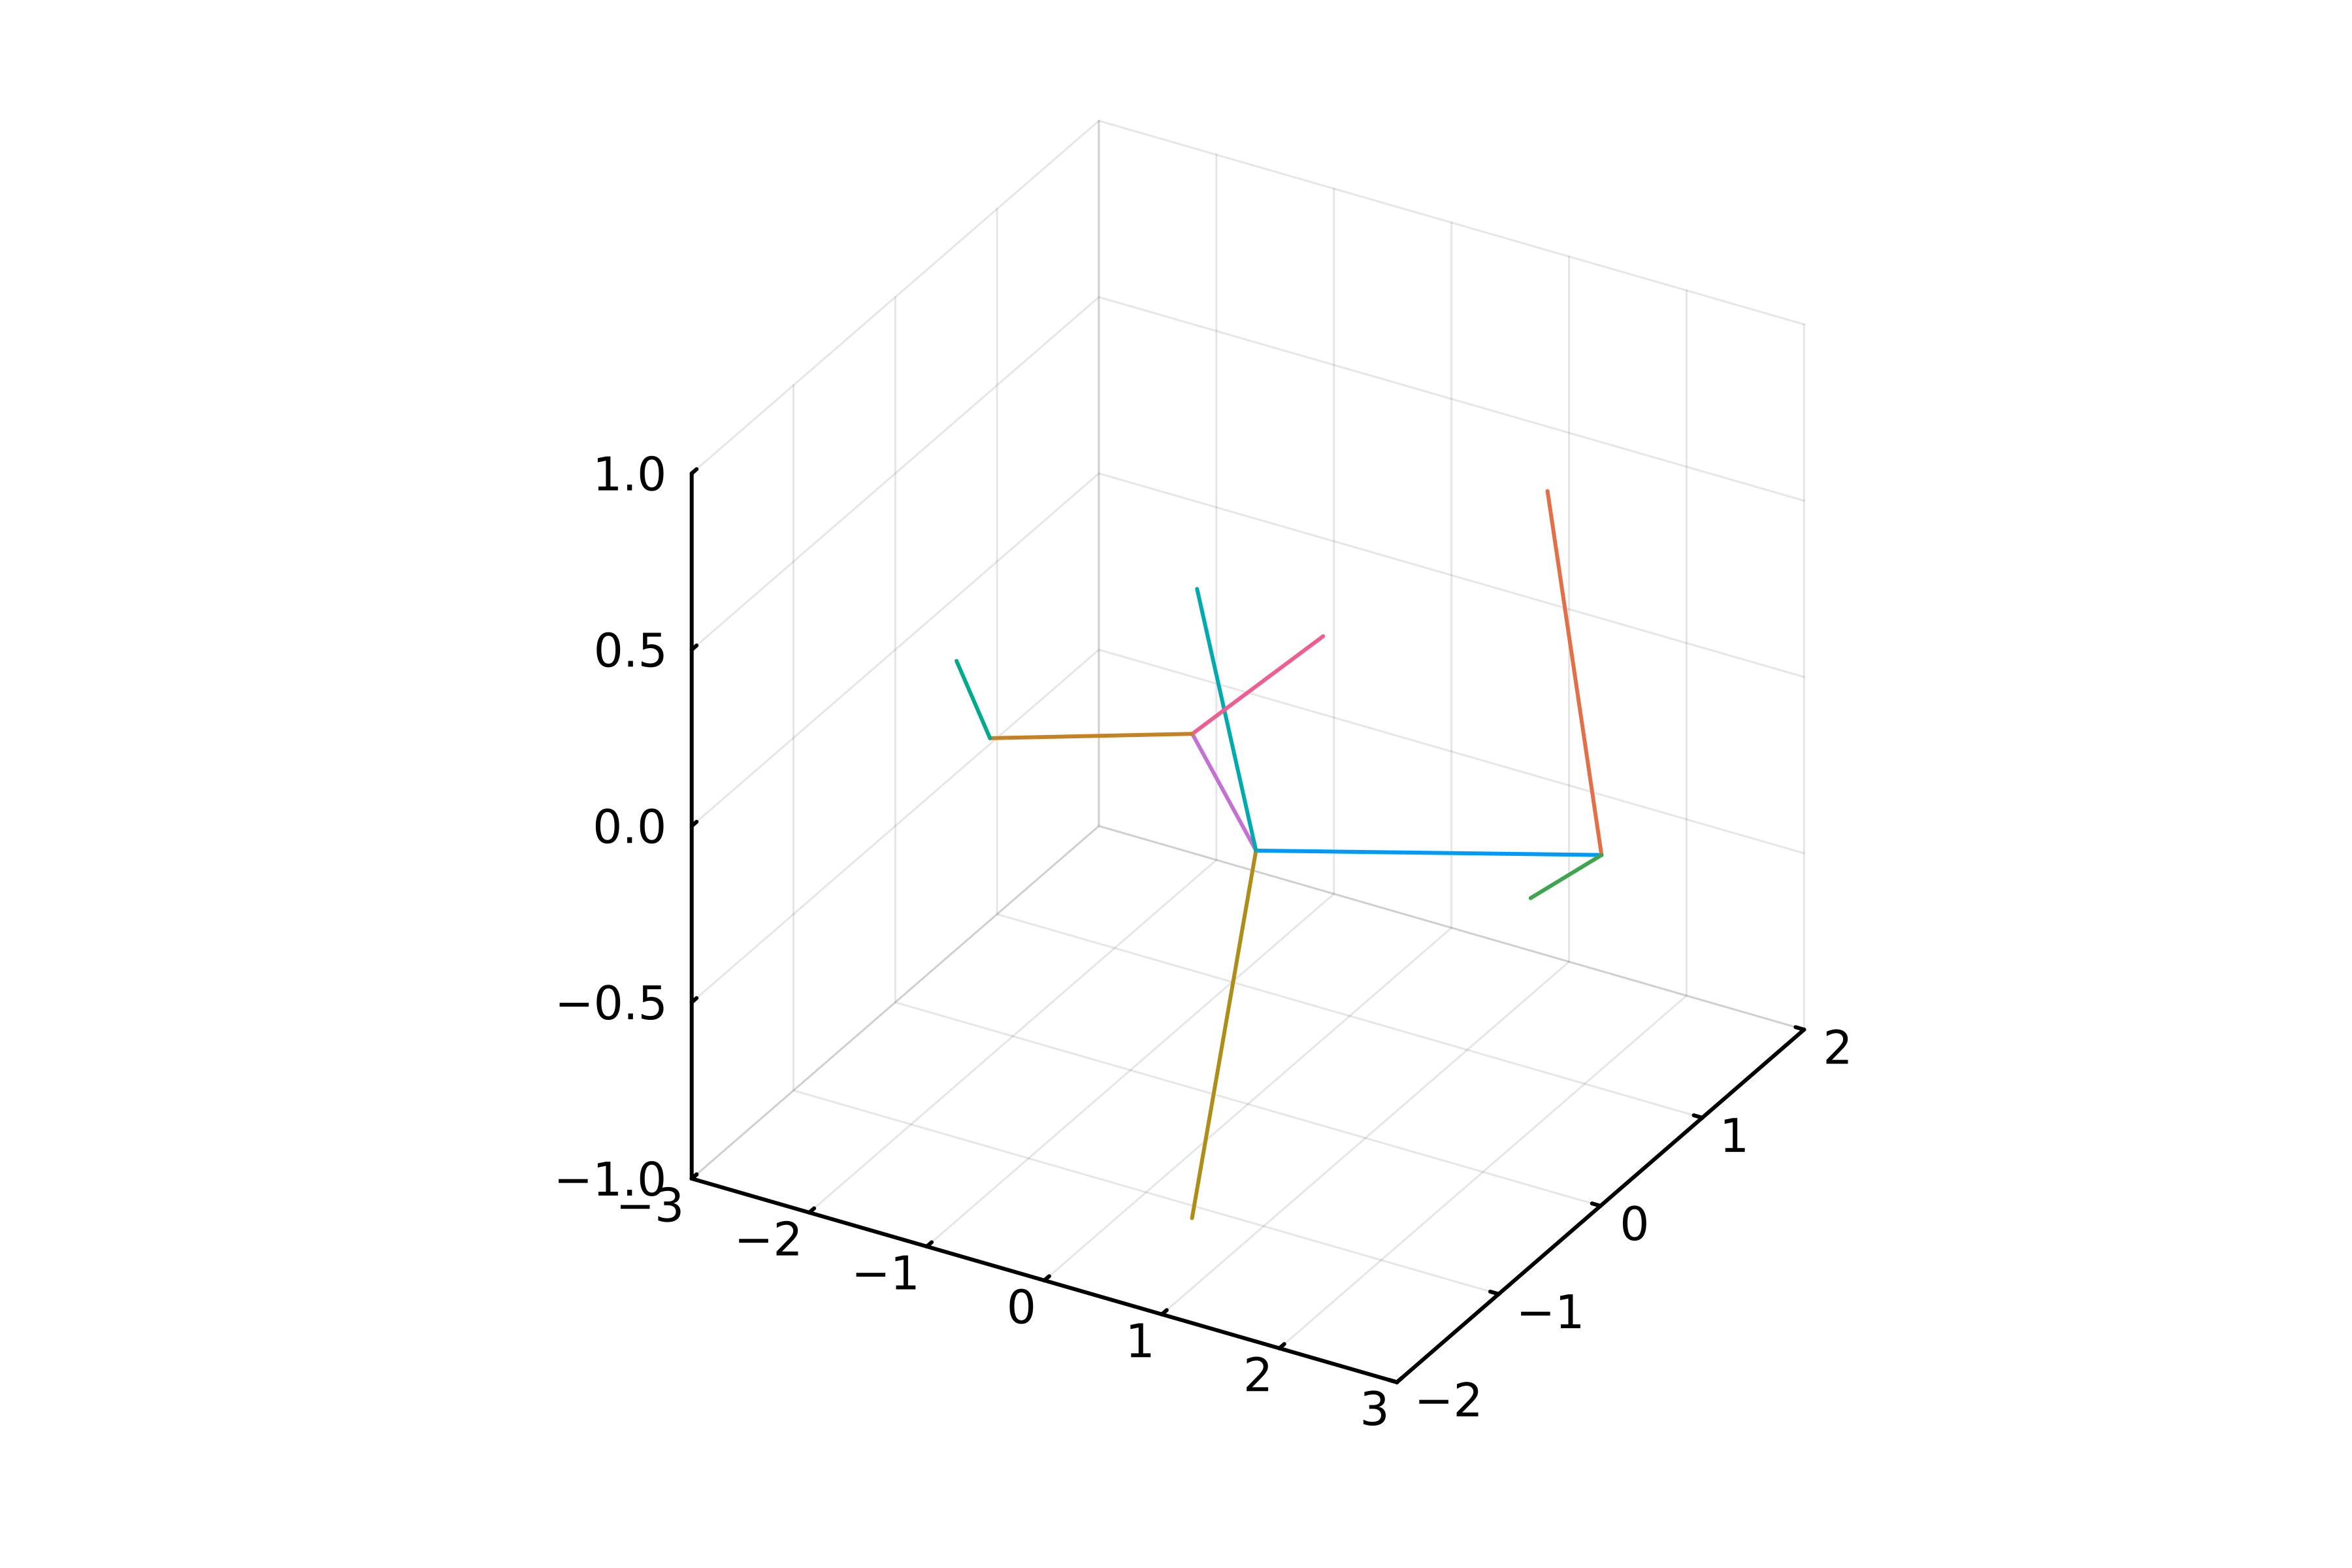

../GLY_ideal.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_e5kRCBOhoT.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_eHqvwd69k5.gif")
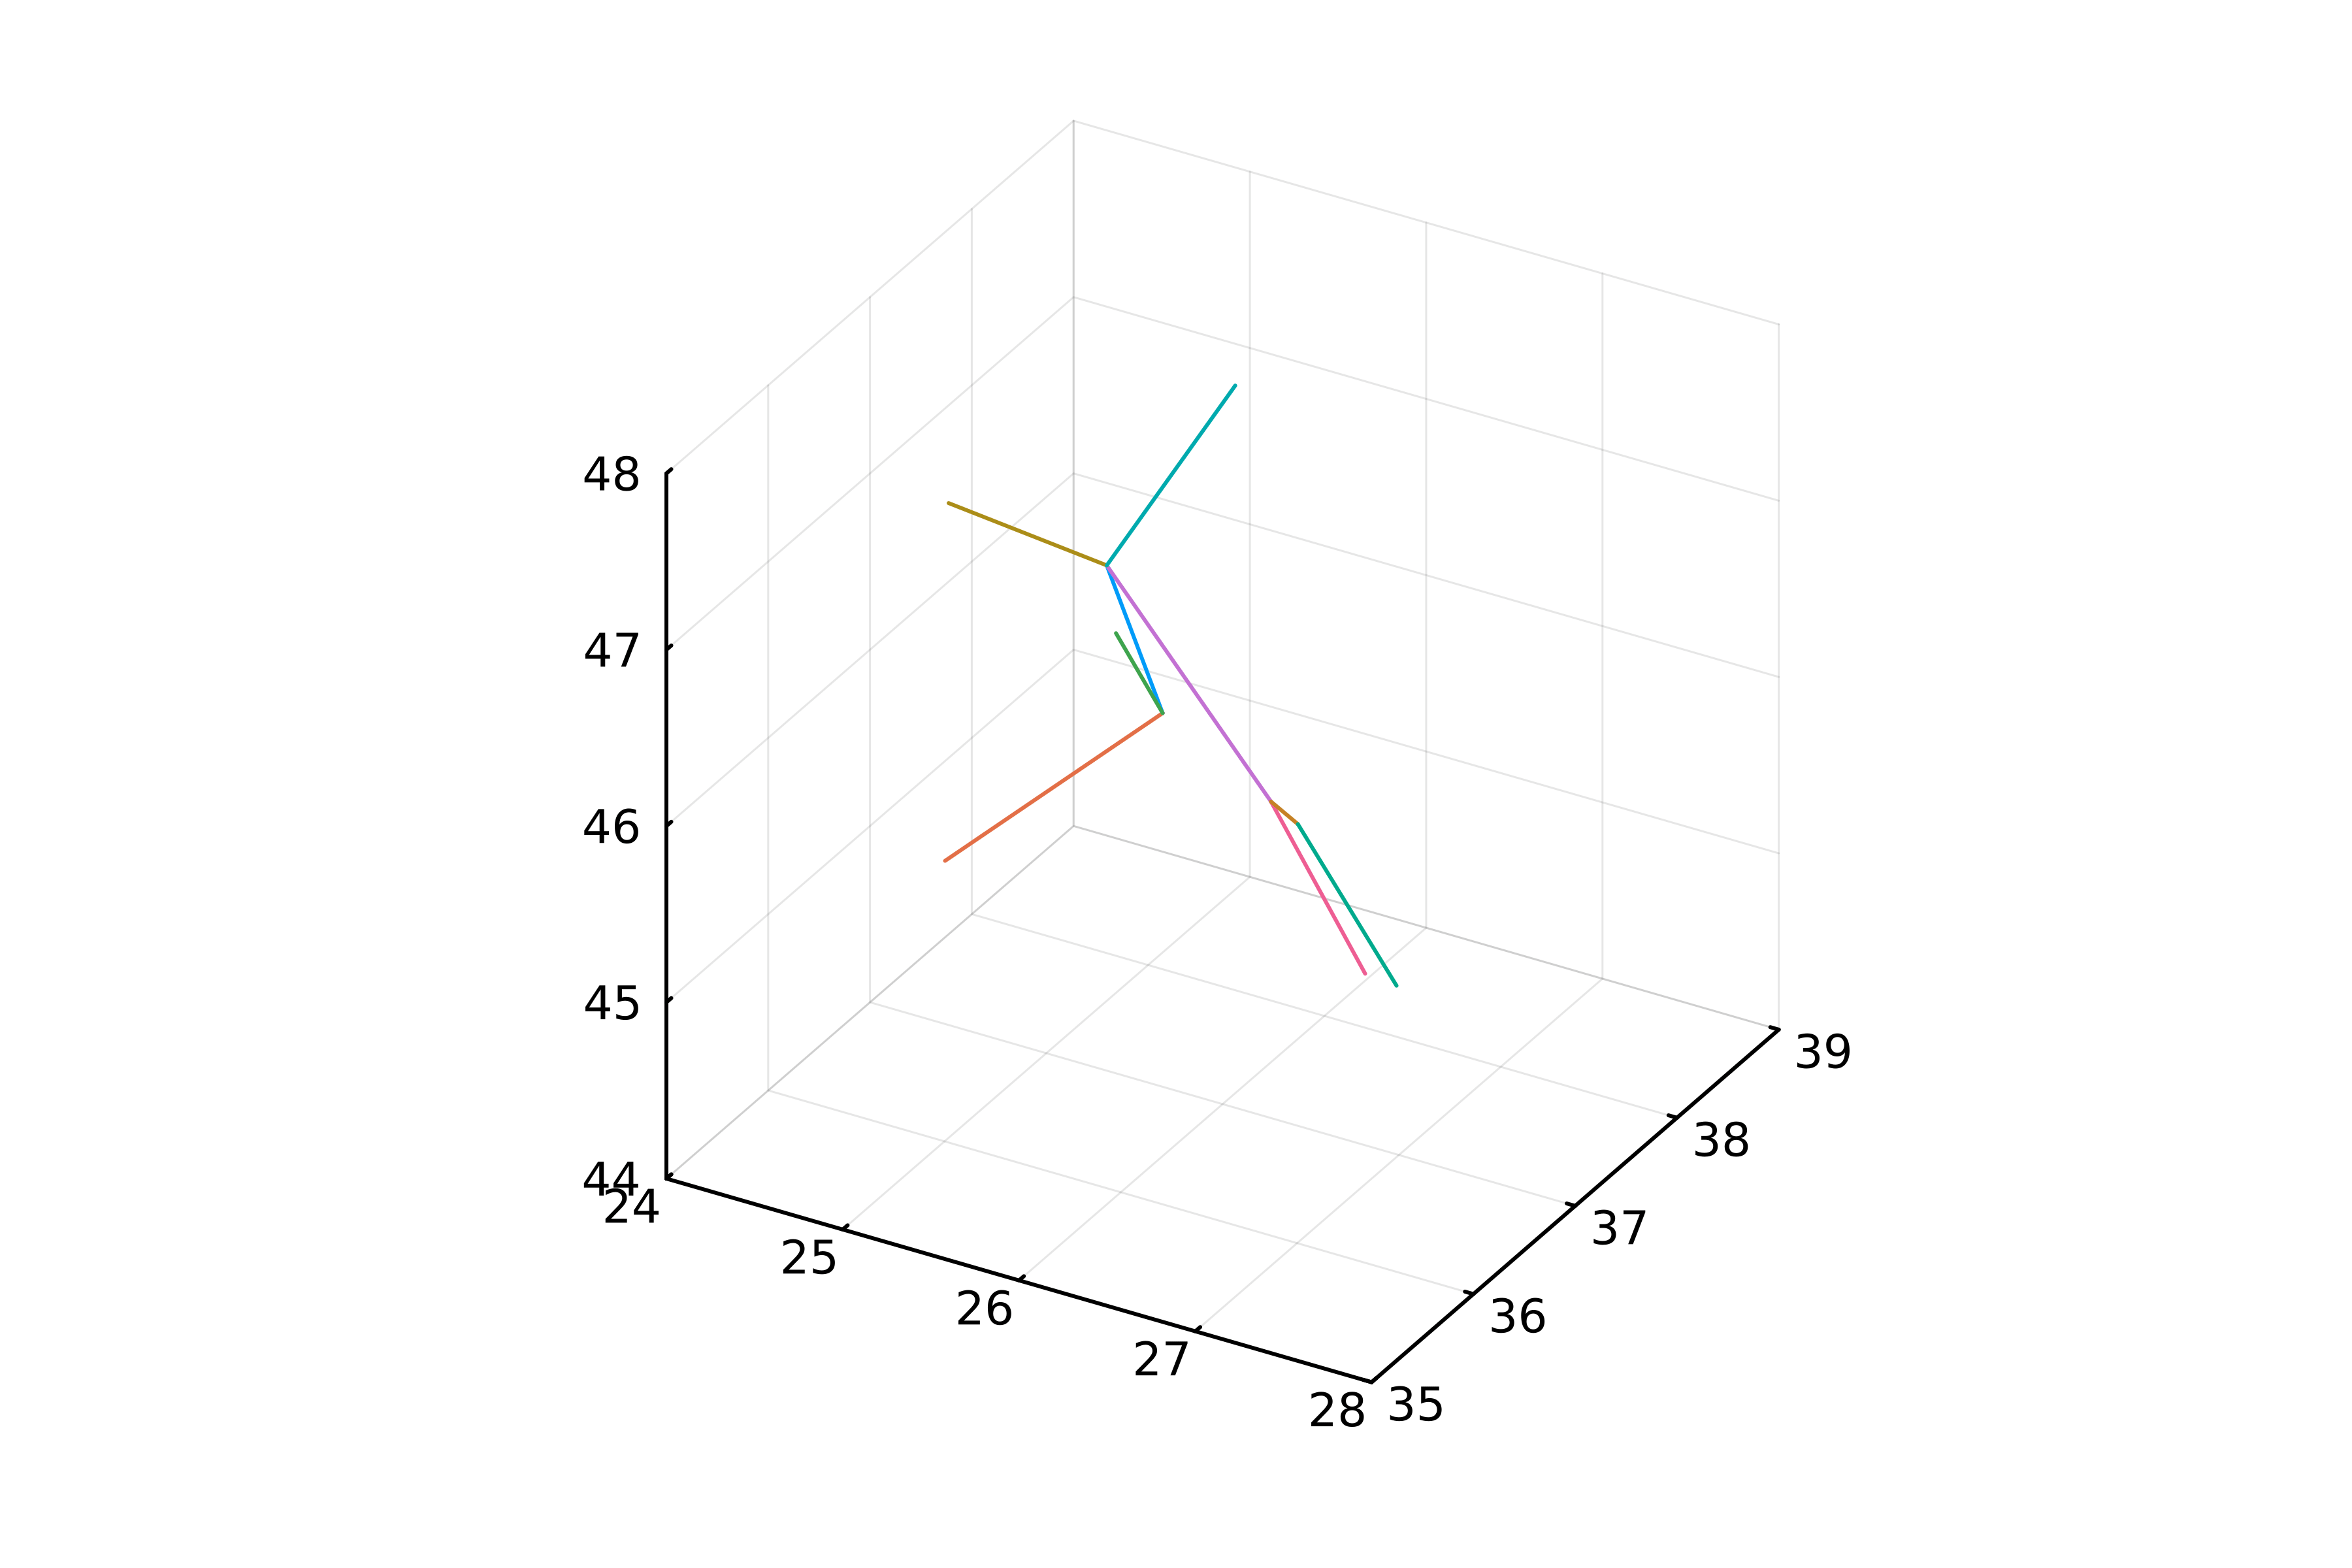

../GLY_model.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_eHqvwd69k5.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Info: 2 unassigned Out Of Plane Bends.
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_out_of_plane_bend.jl:78
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_qpAZgZ4HYJ.gif")
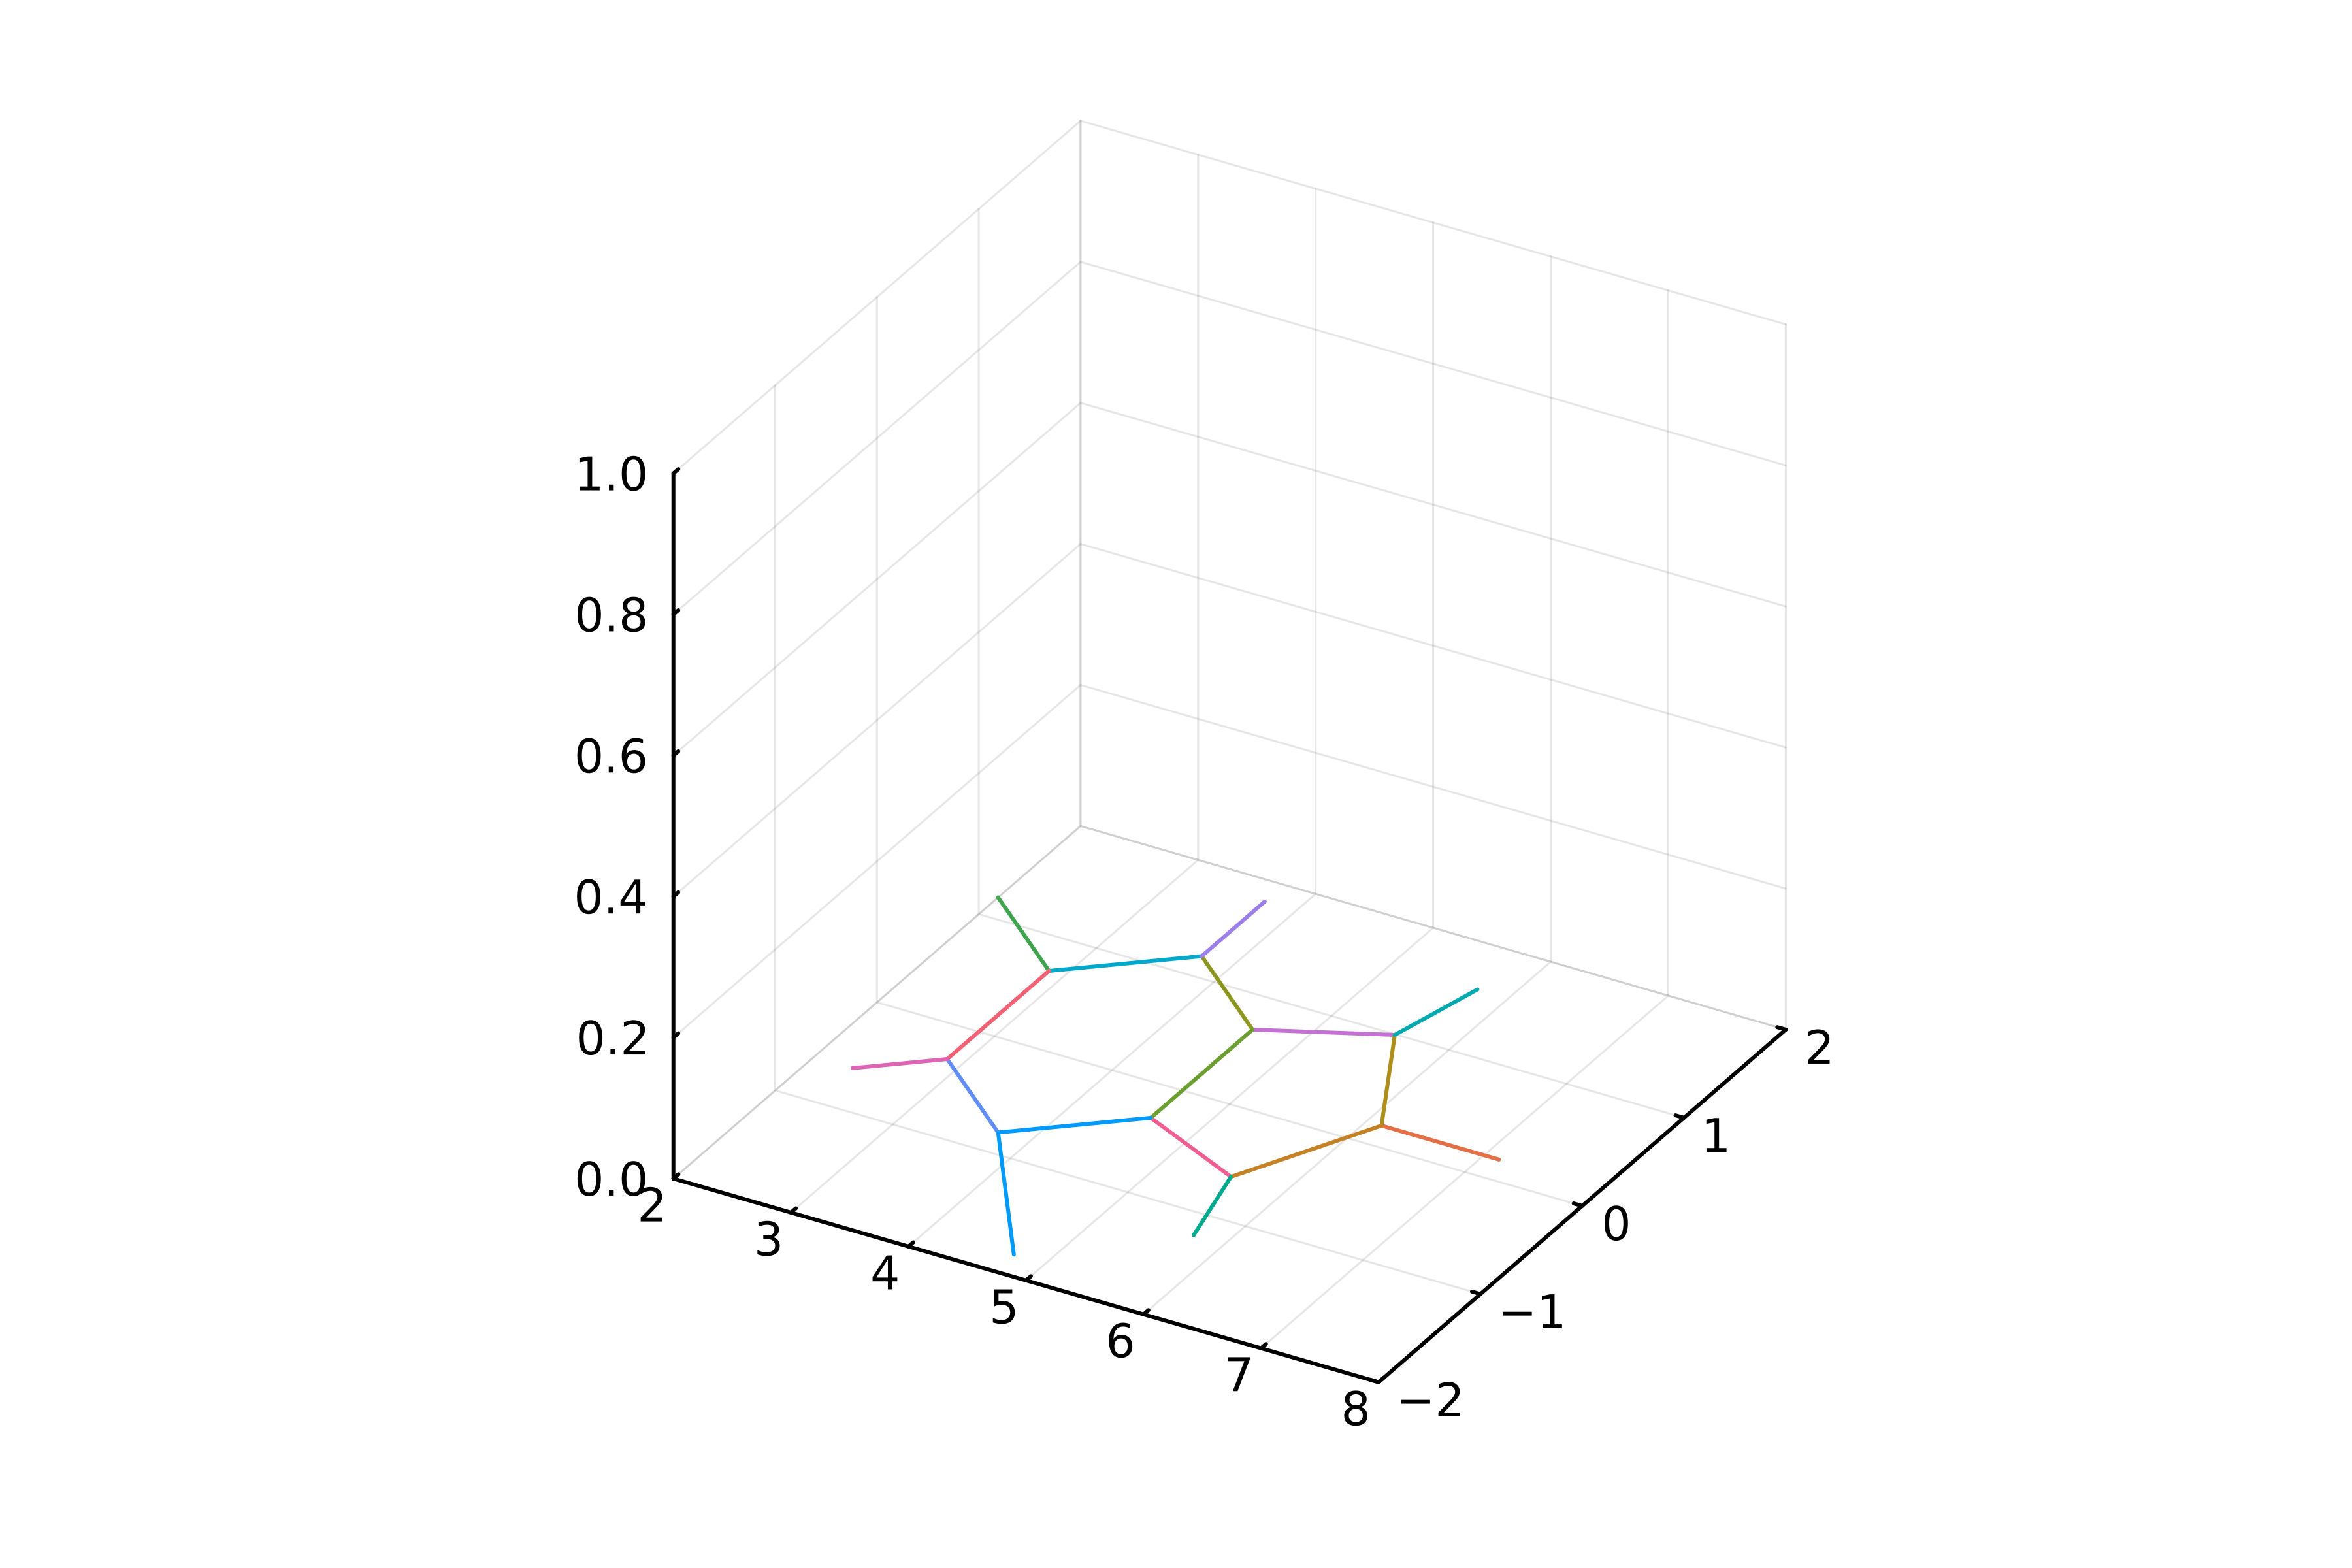

../Structure2D_COMPOUND_CID_1175.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_qpAZgZ4HYJ.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Info: 1 unassigned Out Of Plane Bends.
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_out_of_plane_bend.jl:78
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_cXS7iRA5Wz.gif")
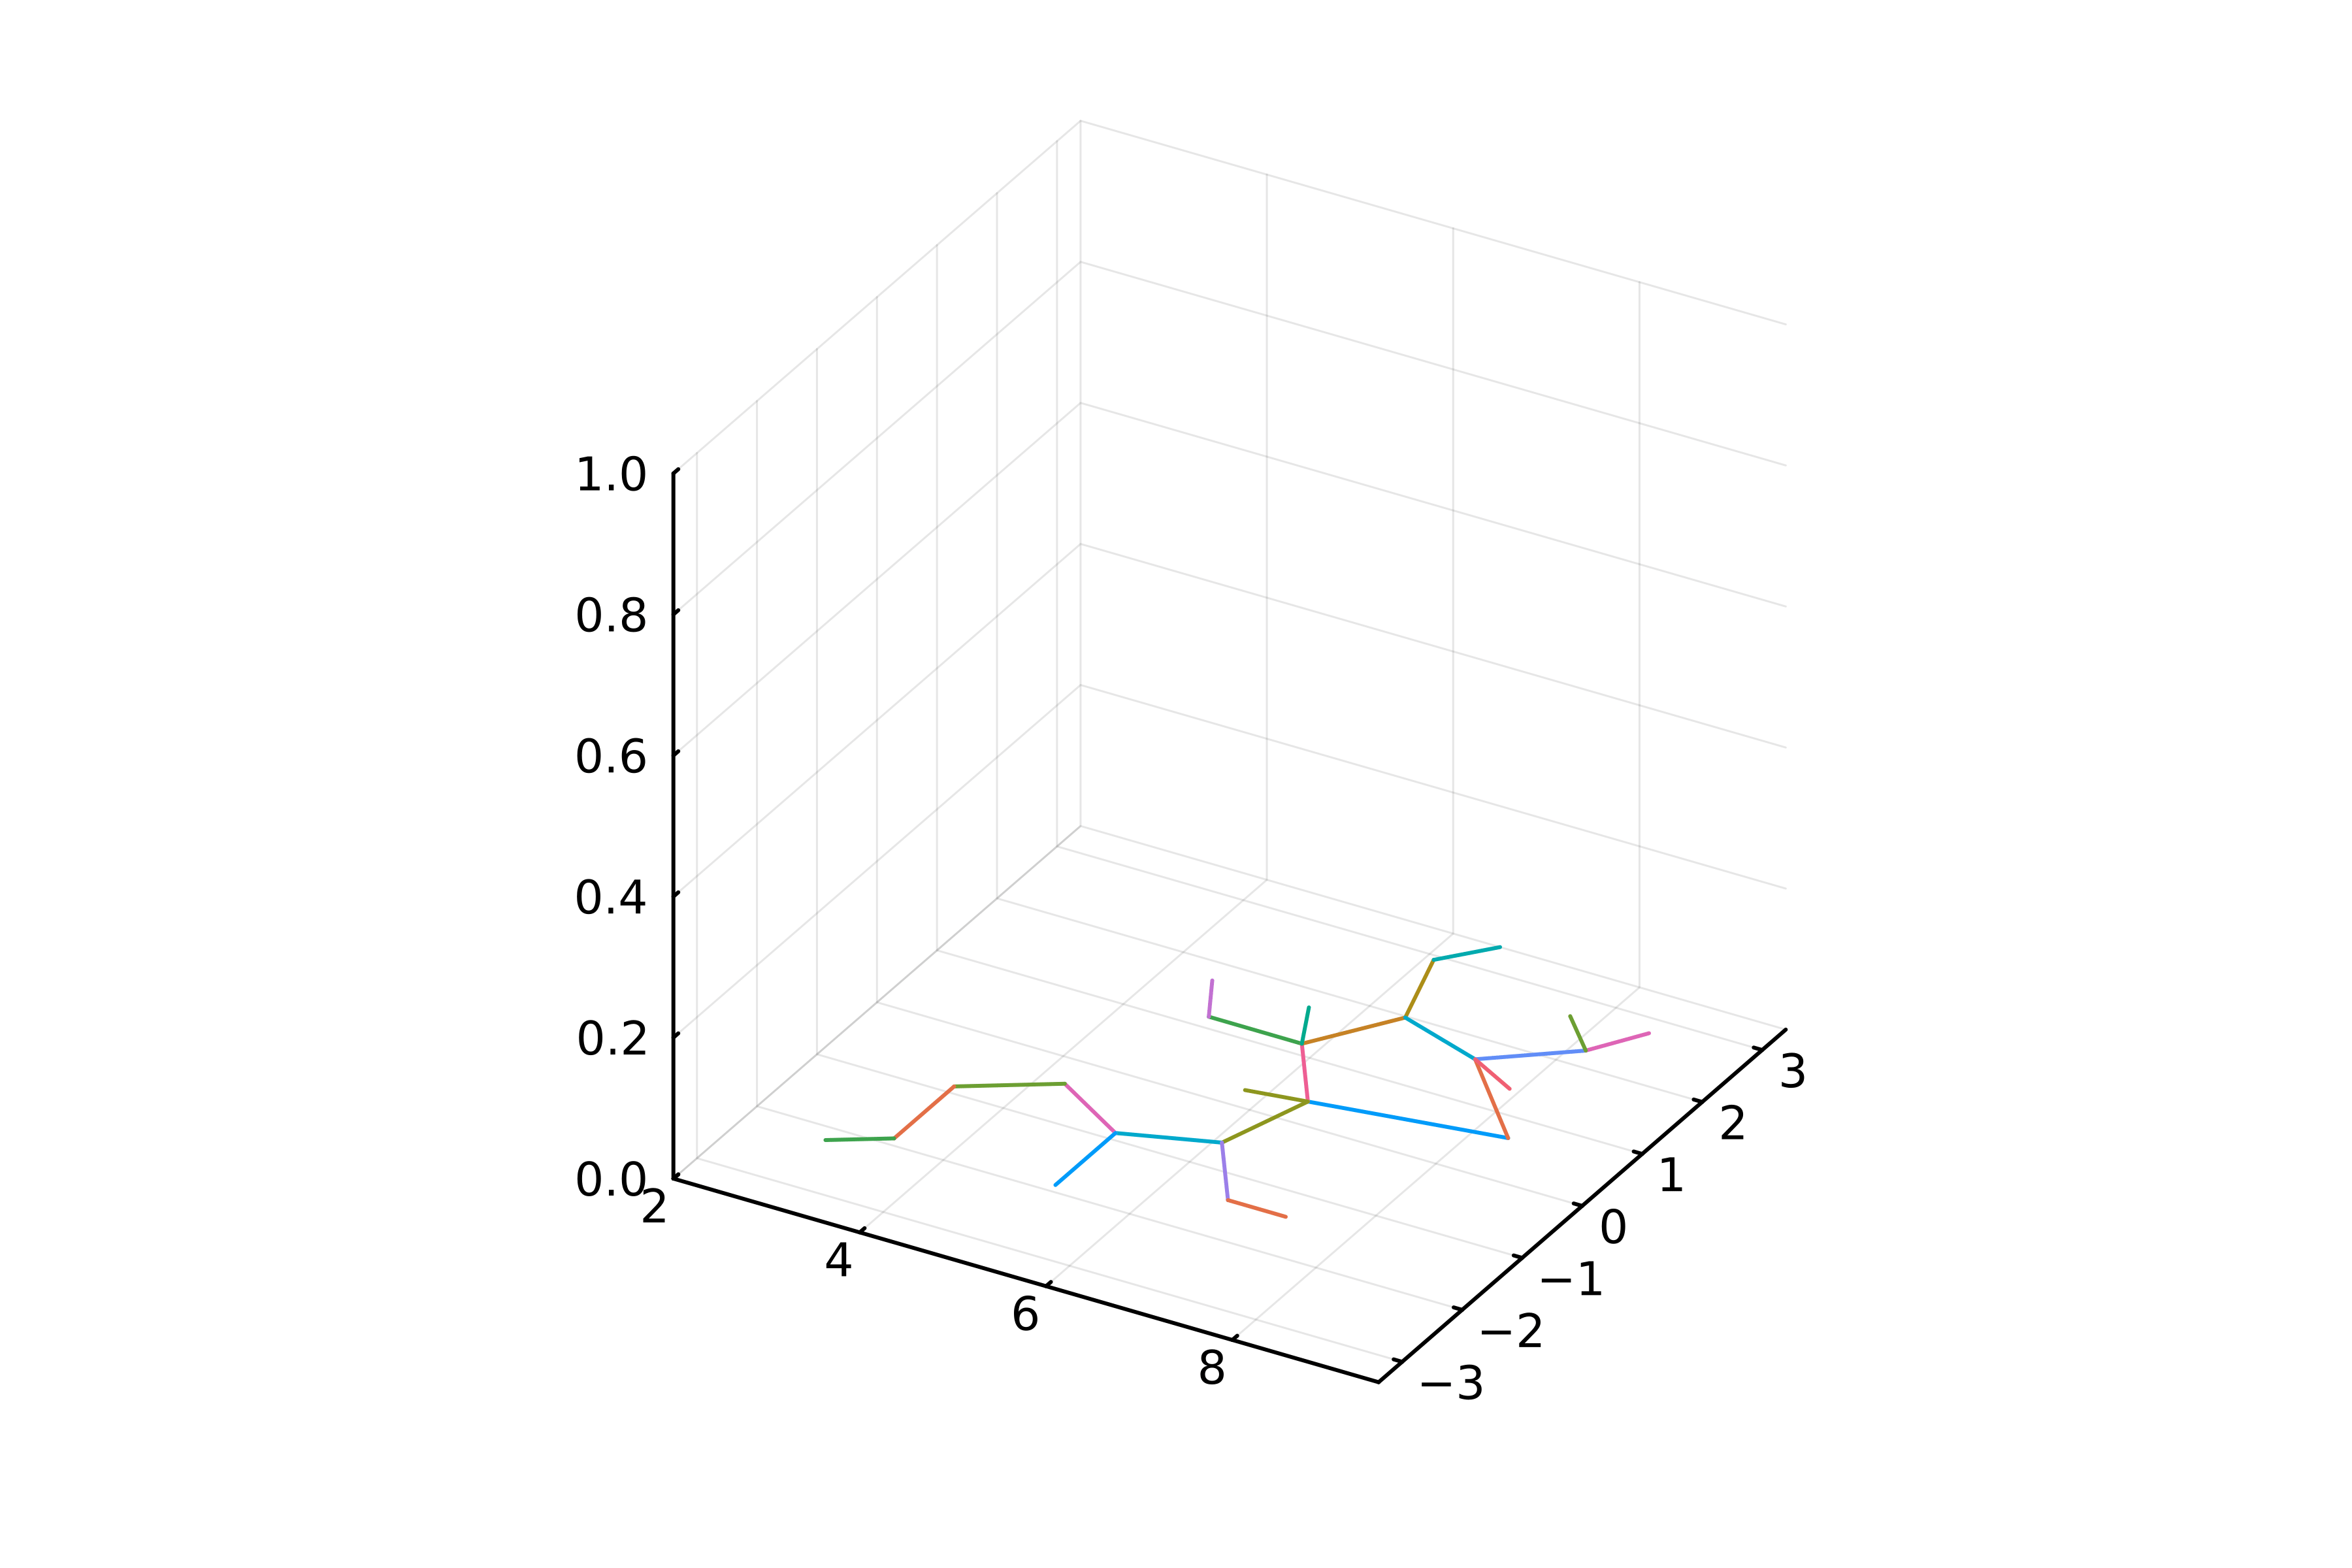

../Structure2D_COMPOUND_CID_135398635.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_cXS7iRA5Wz.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:606


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_WdG1Ixs5Ab.gif")
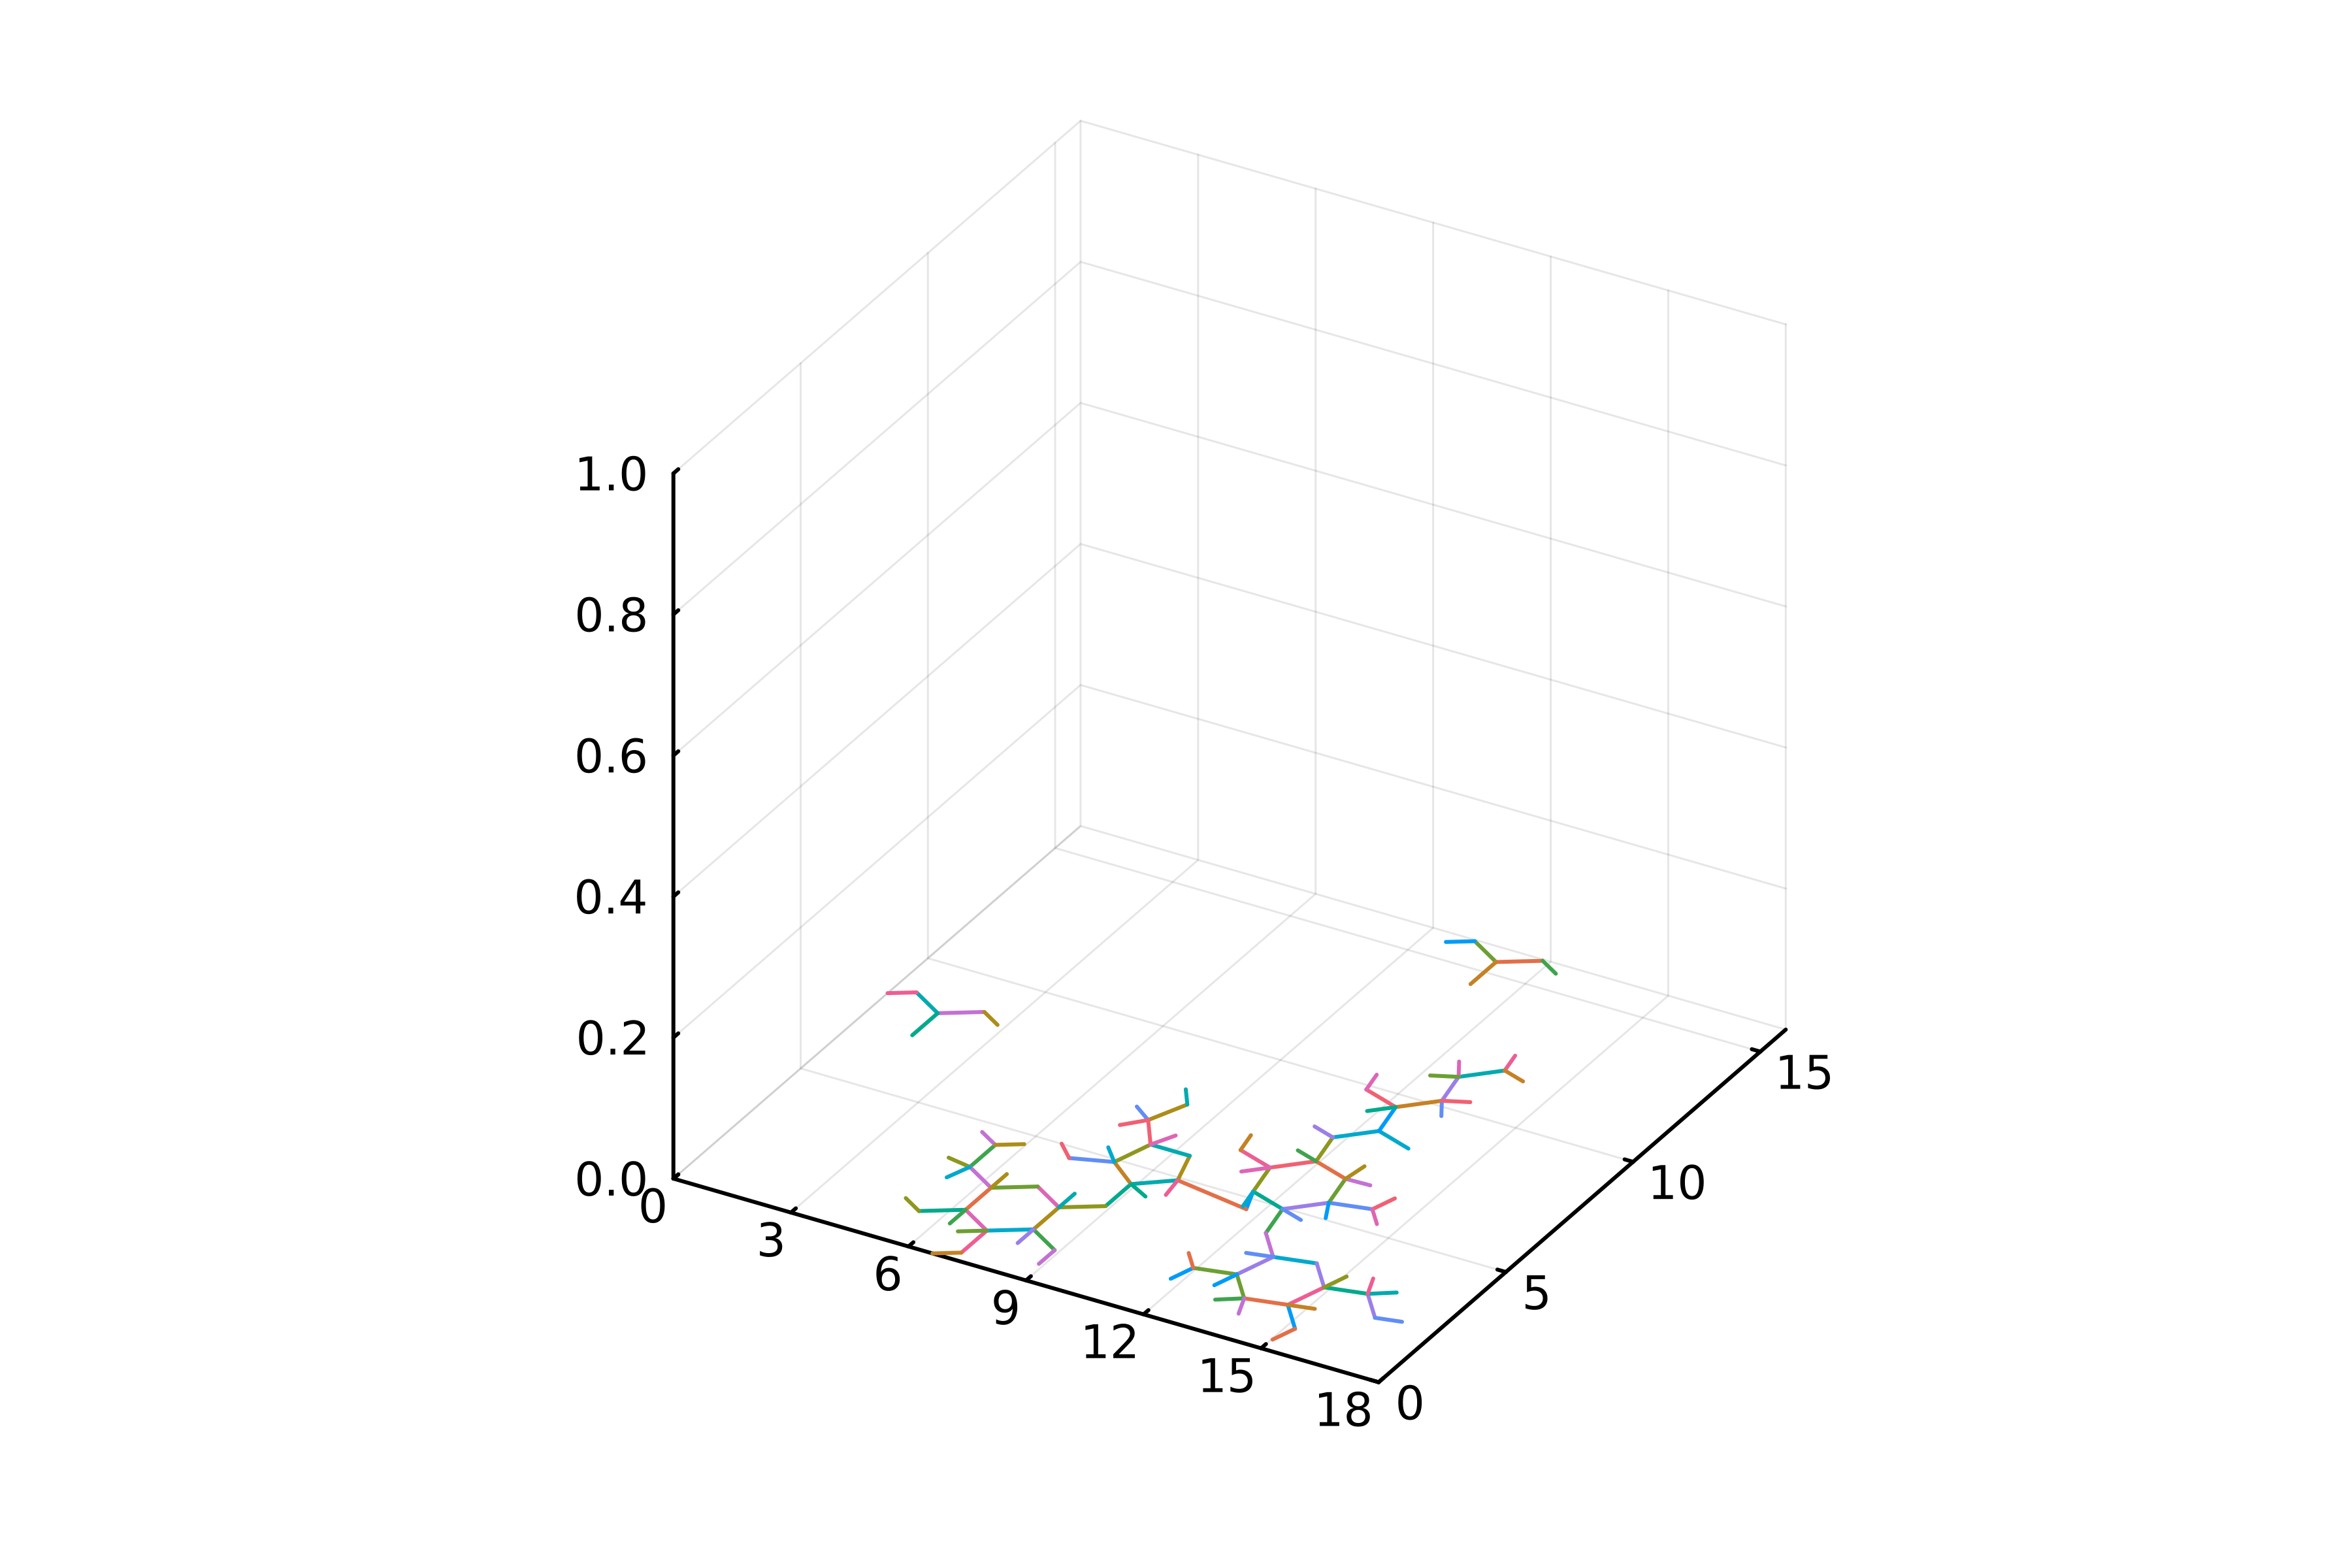

../Structure2D_COMPOUND_CID_196182.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_WdG1Ixs5Ab.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: dt(7.6293945e-6) <= dtmin(7.6293945e-6) at t=0.0, and step error estimate = 251.71089. Aborting. There is either an error in your model specification or the true solution is unstable.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:599


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_23k50FExUl.gif")
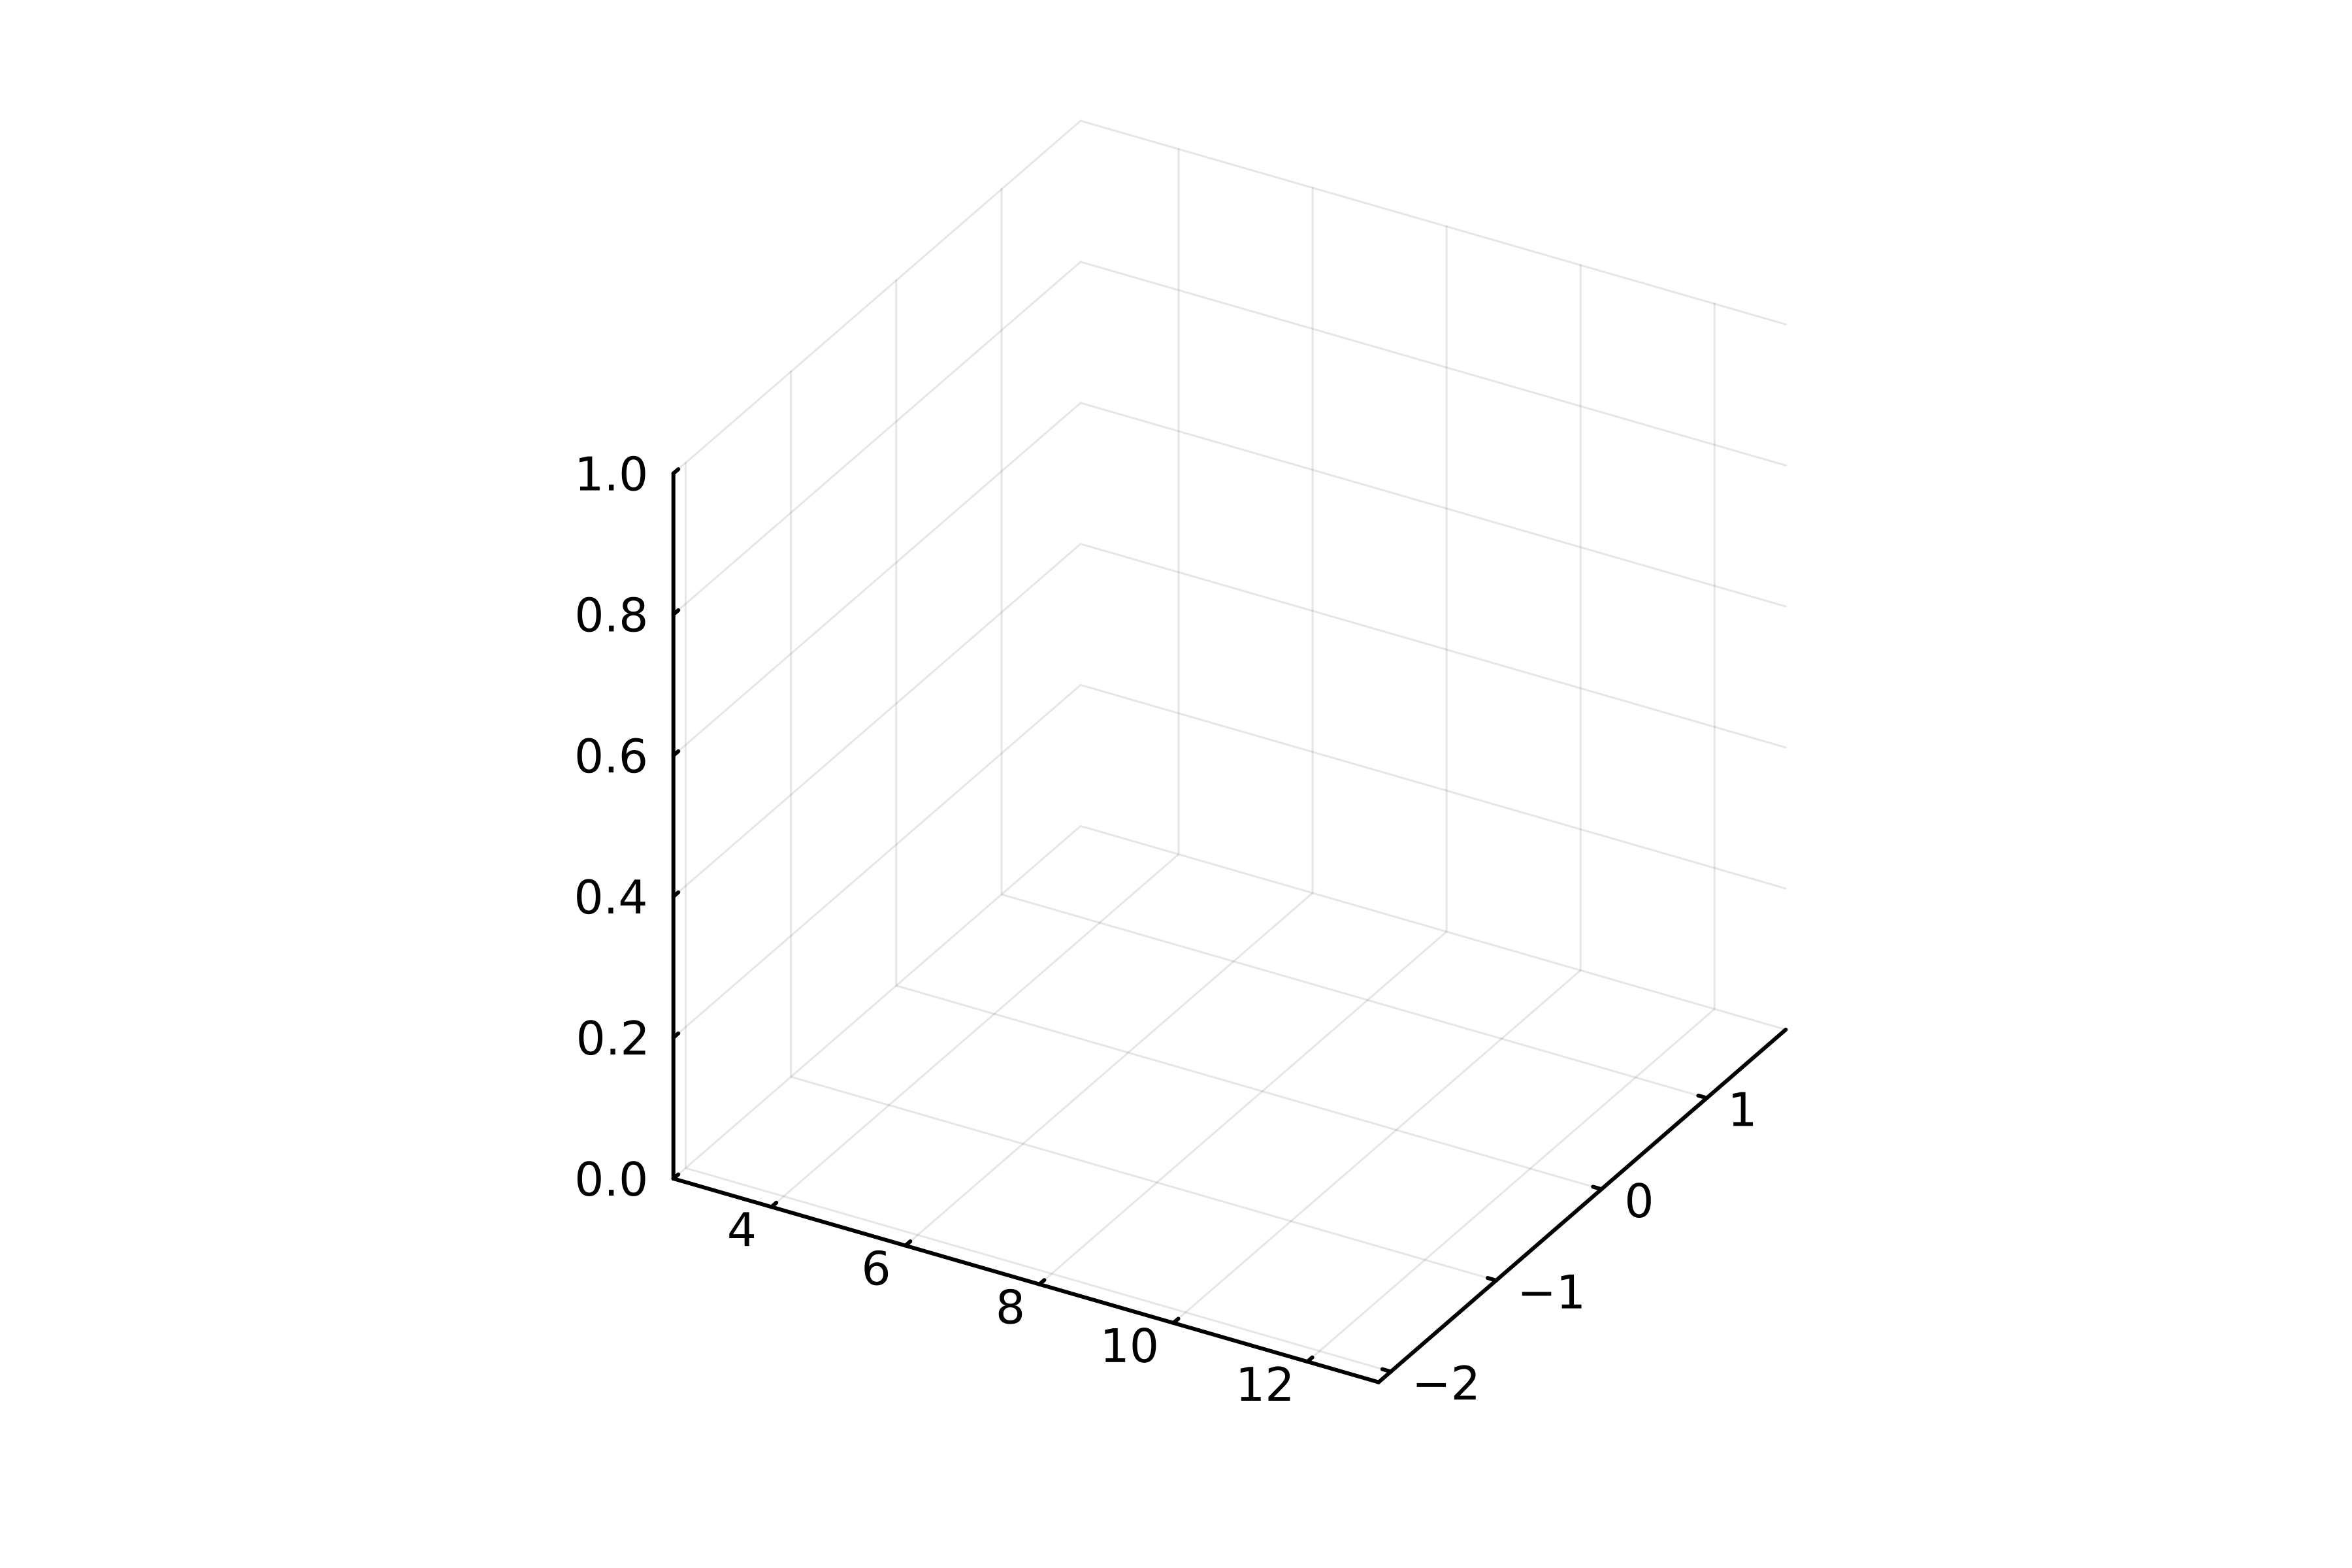

../Structure2D_COMPOUND_CID_22568738.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_23k50FExUl.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Info: 2 unassigned Out Of Plane Bends.
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_out_of_plane_bend.jl:78
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_k7YzkTyxGP.gif")
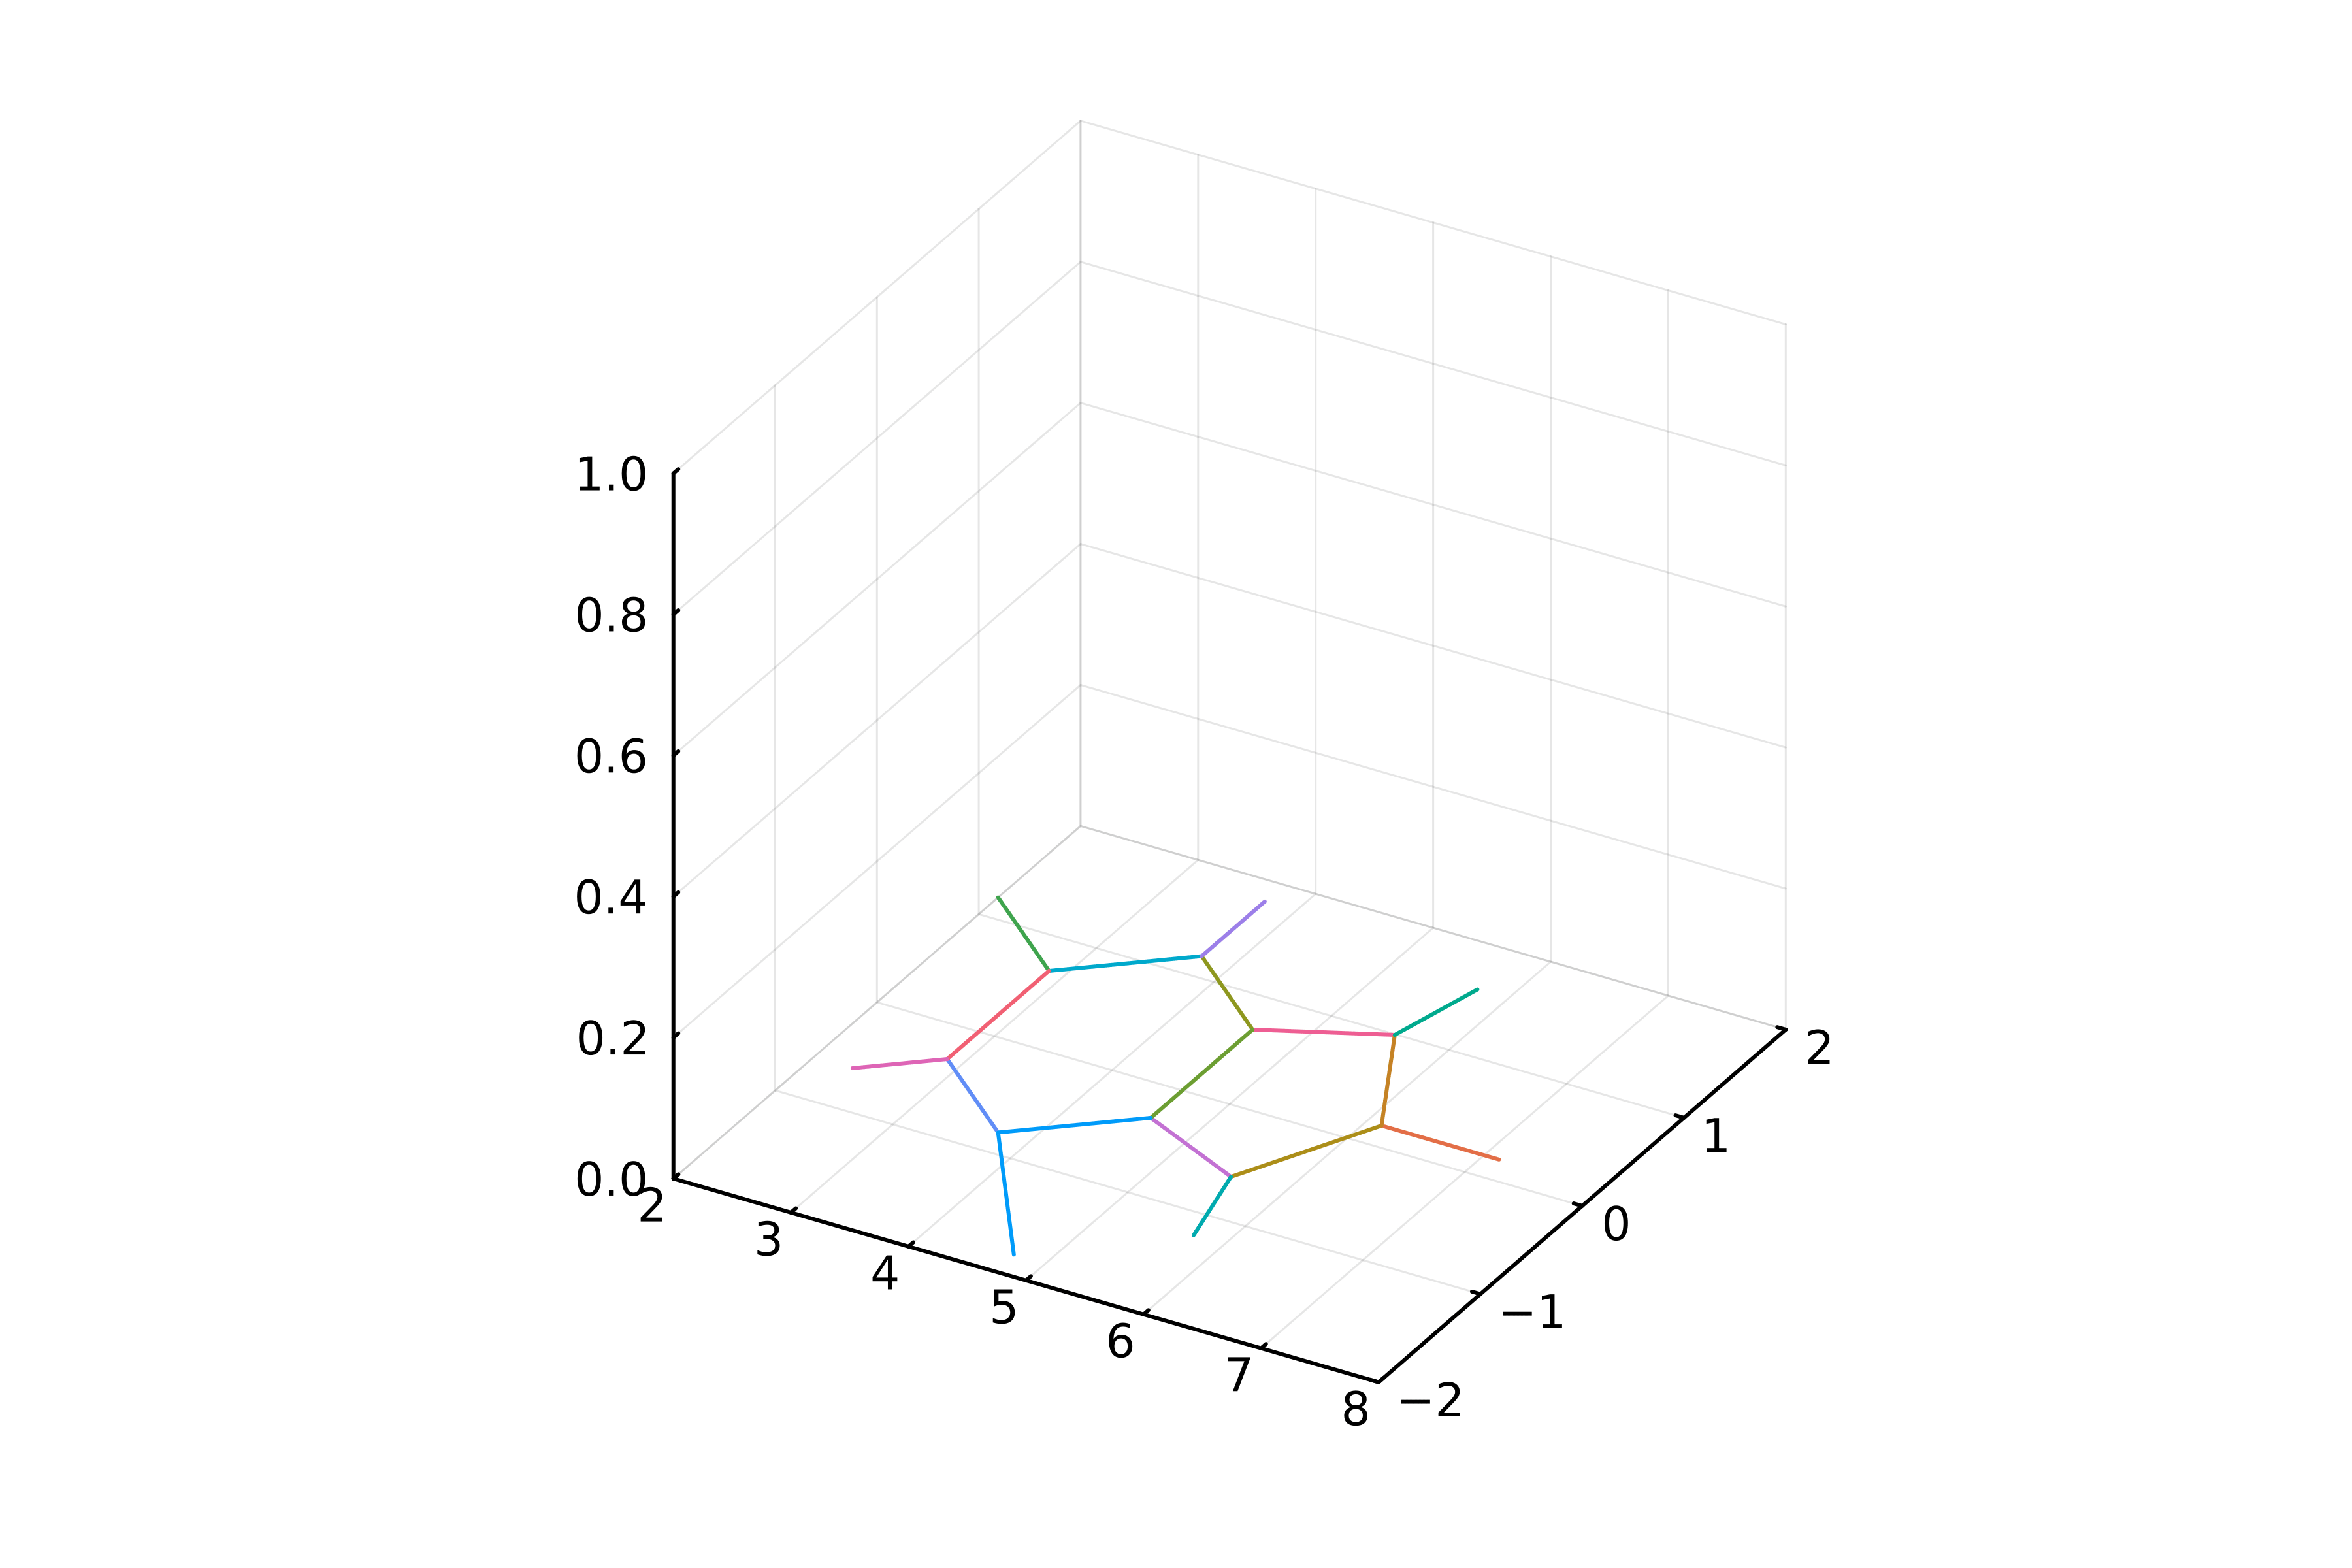

../Structure2D_COMPOUND_CID_56835164.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_k7YzkTyxGP.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_YfkrMd8PIl.gif")
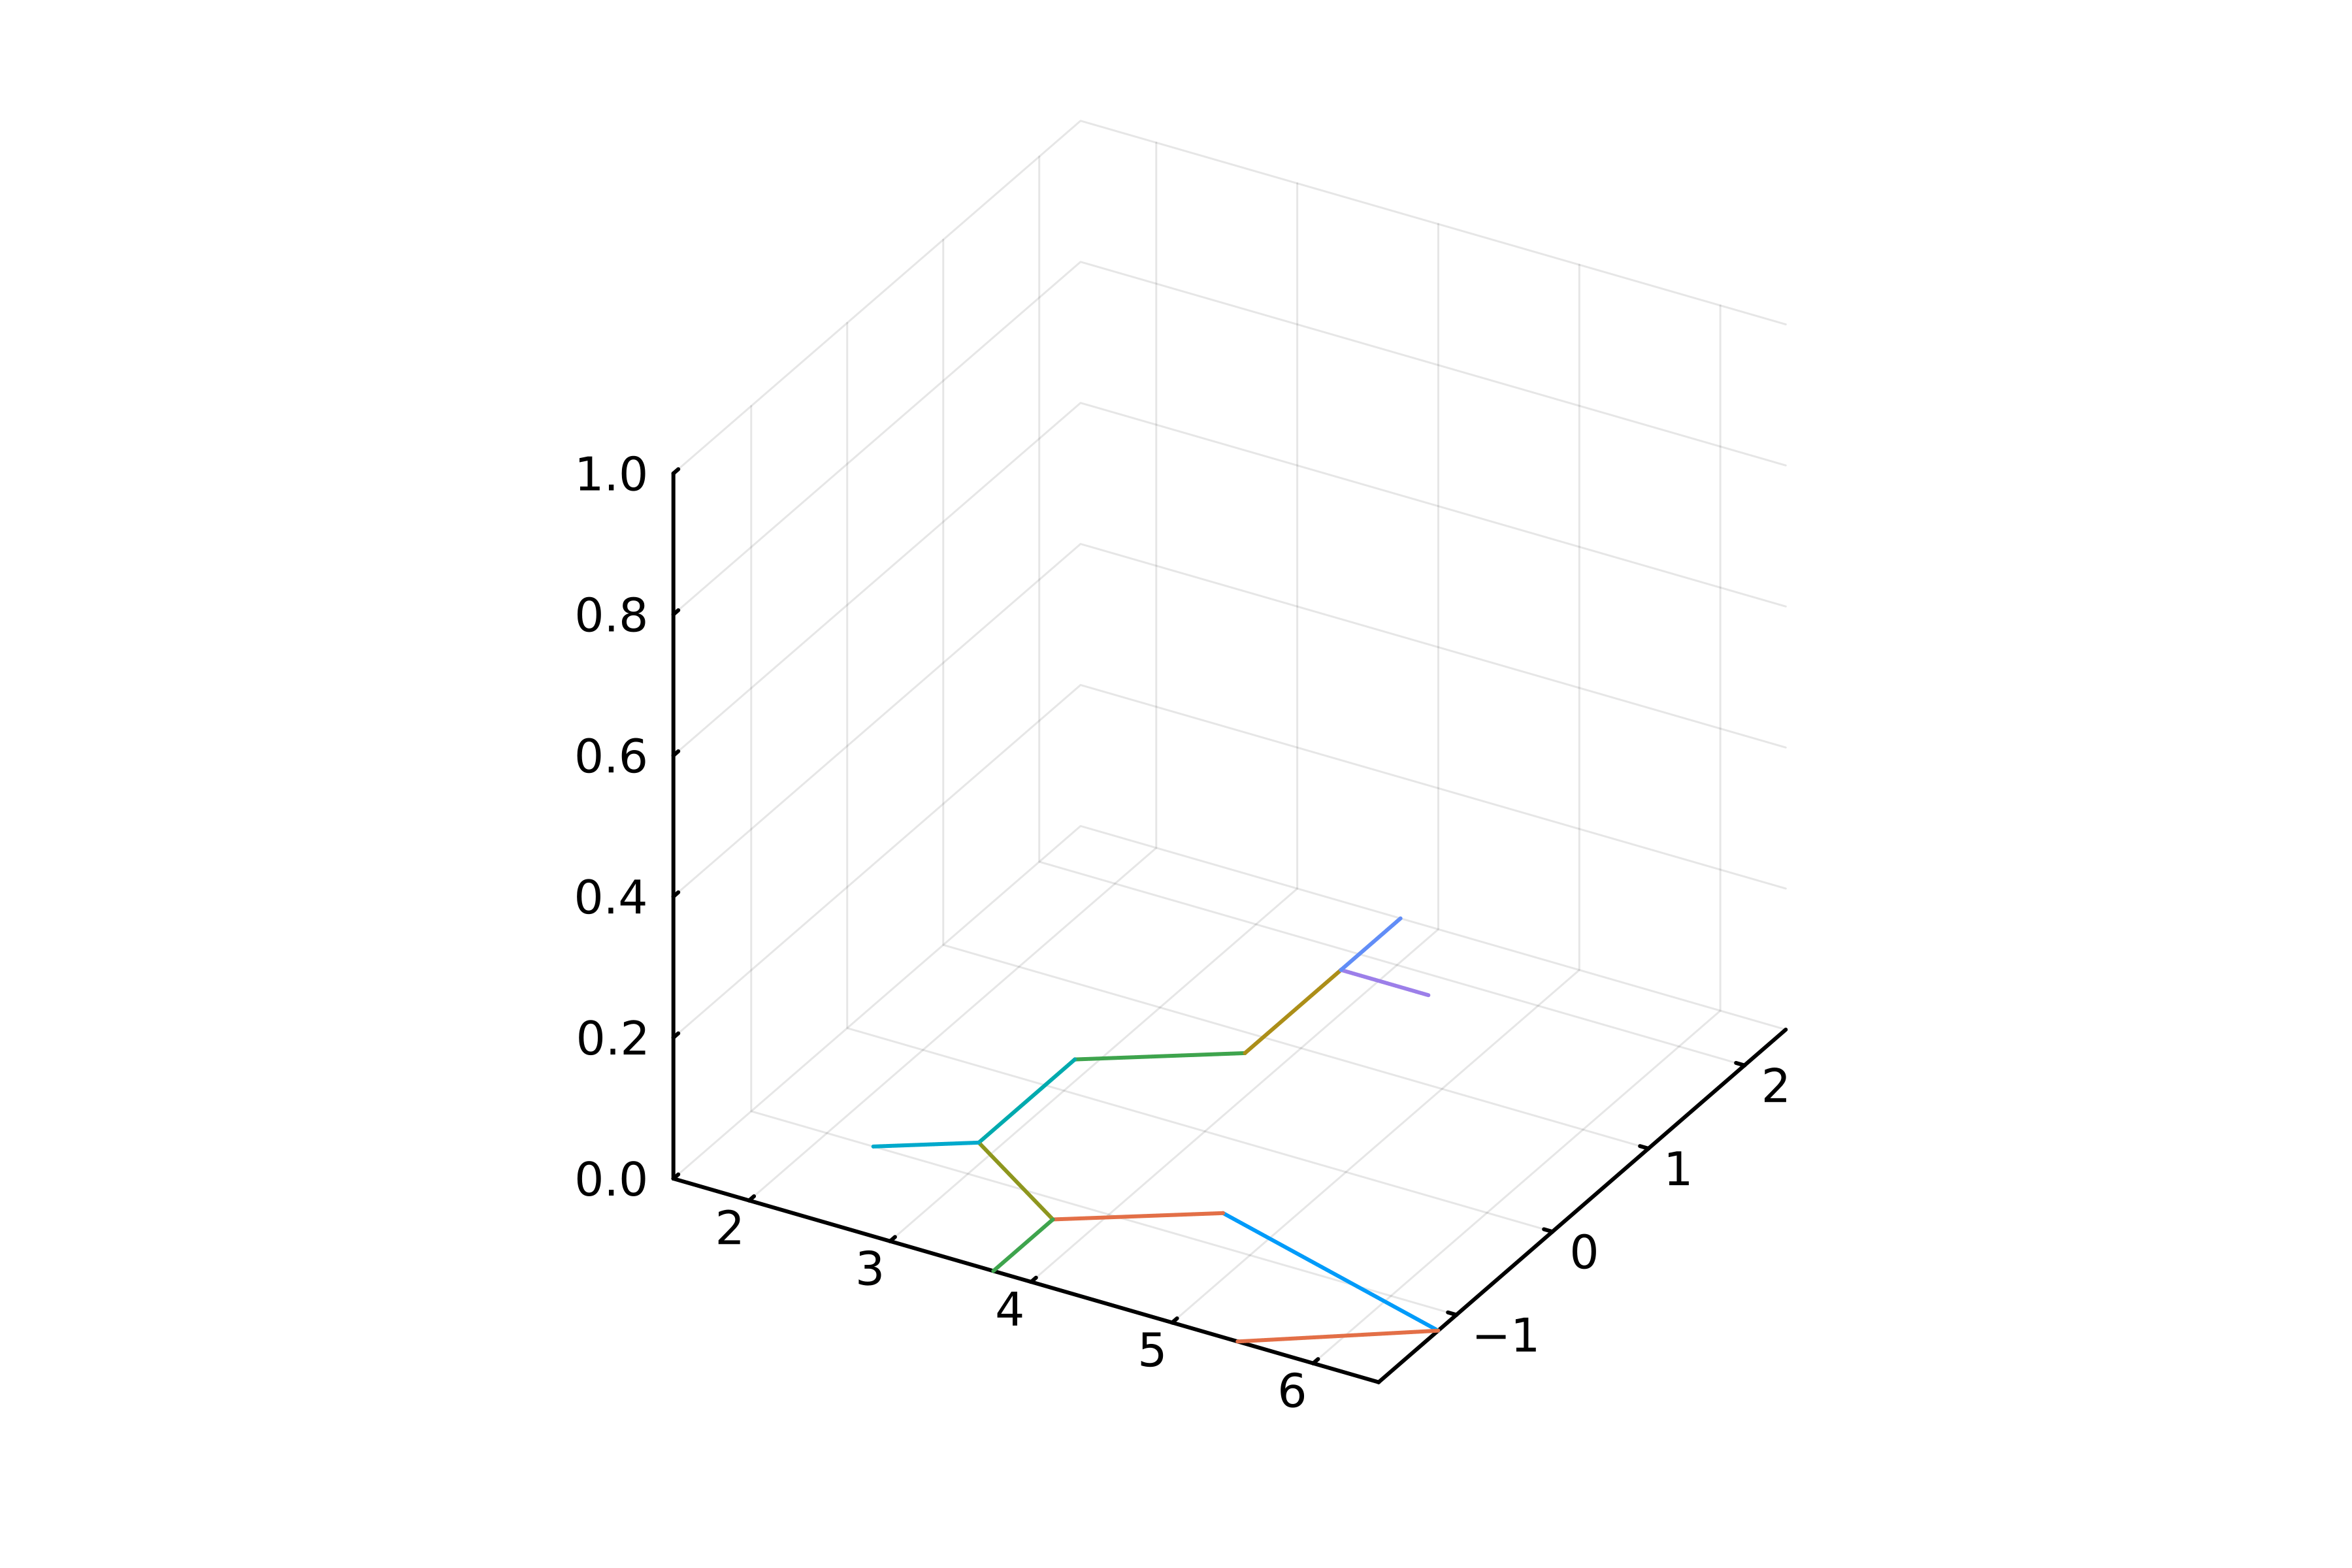

../Structure2D_COMPOUND_CID_7249.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_YfkrMd8PIl.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_YvSn8zATM1.gif")
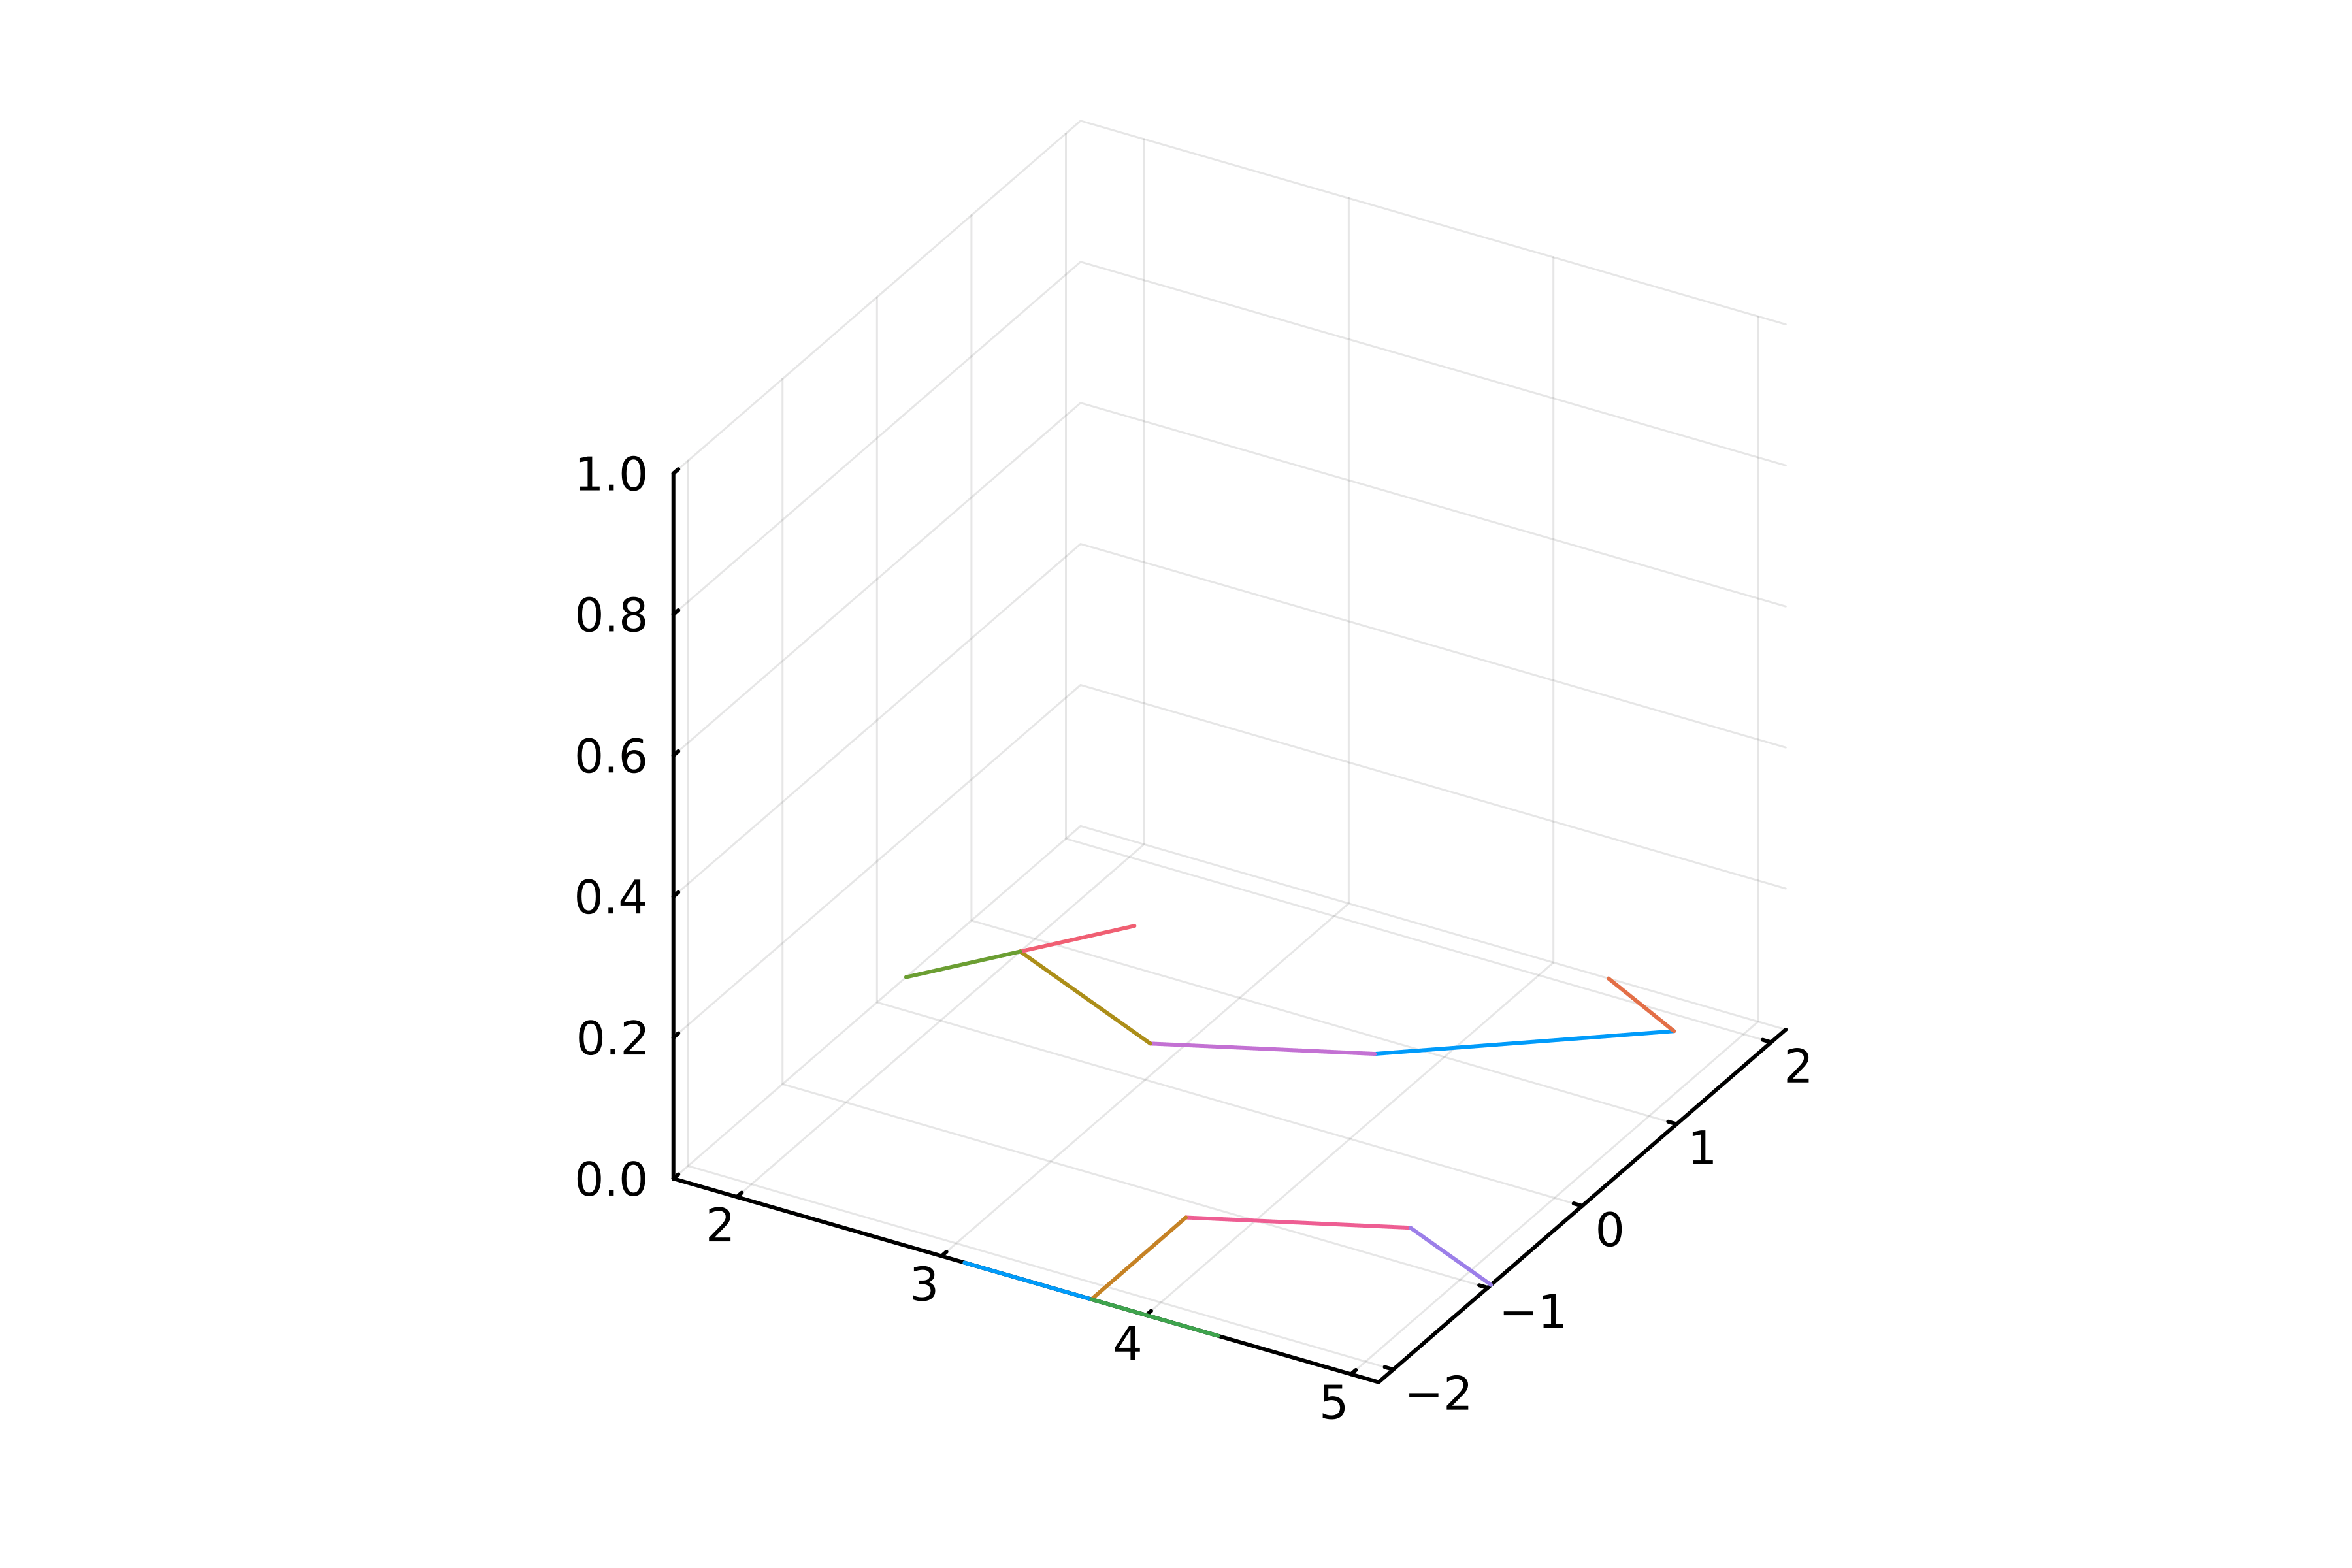

../Structure2D_COMPOUND_CID_7771.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_YvSn8zATM1.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_ejMPYDKFyb.gif")
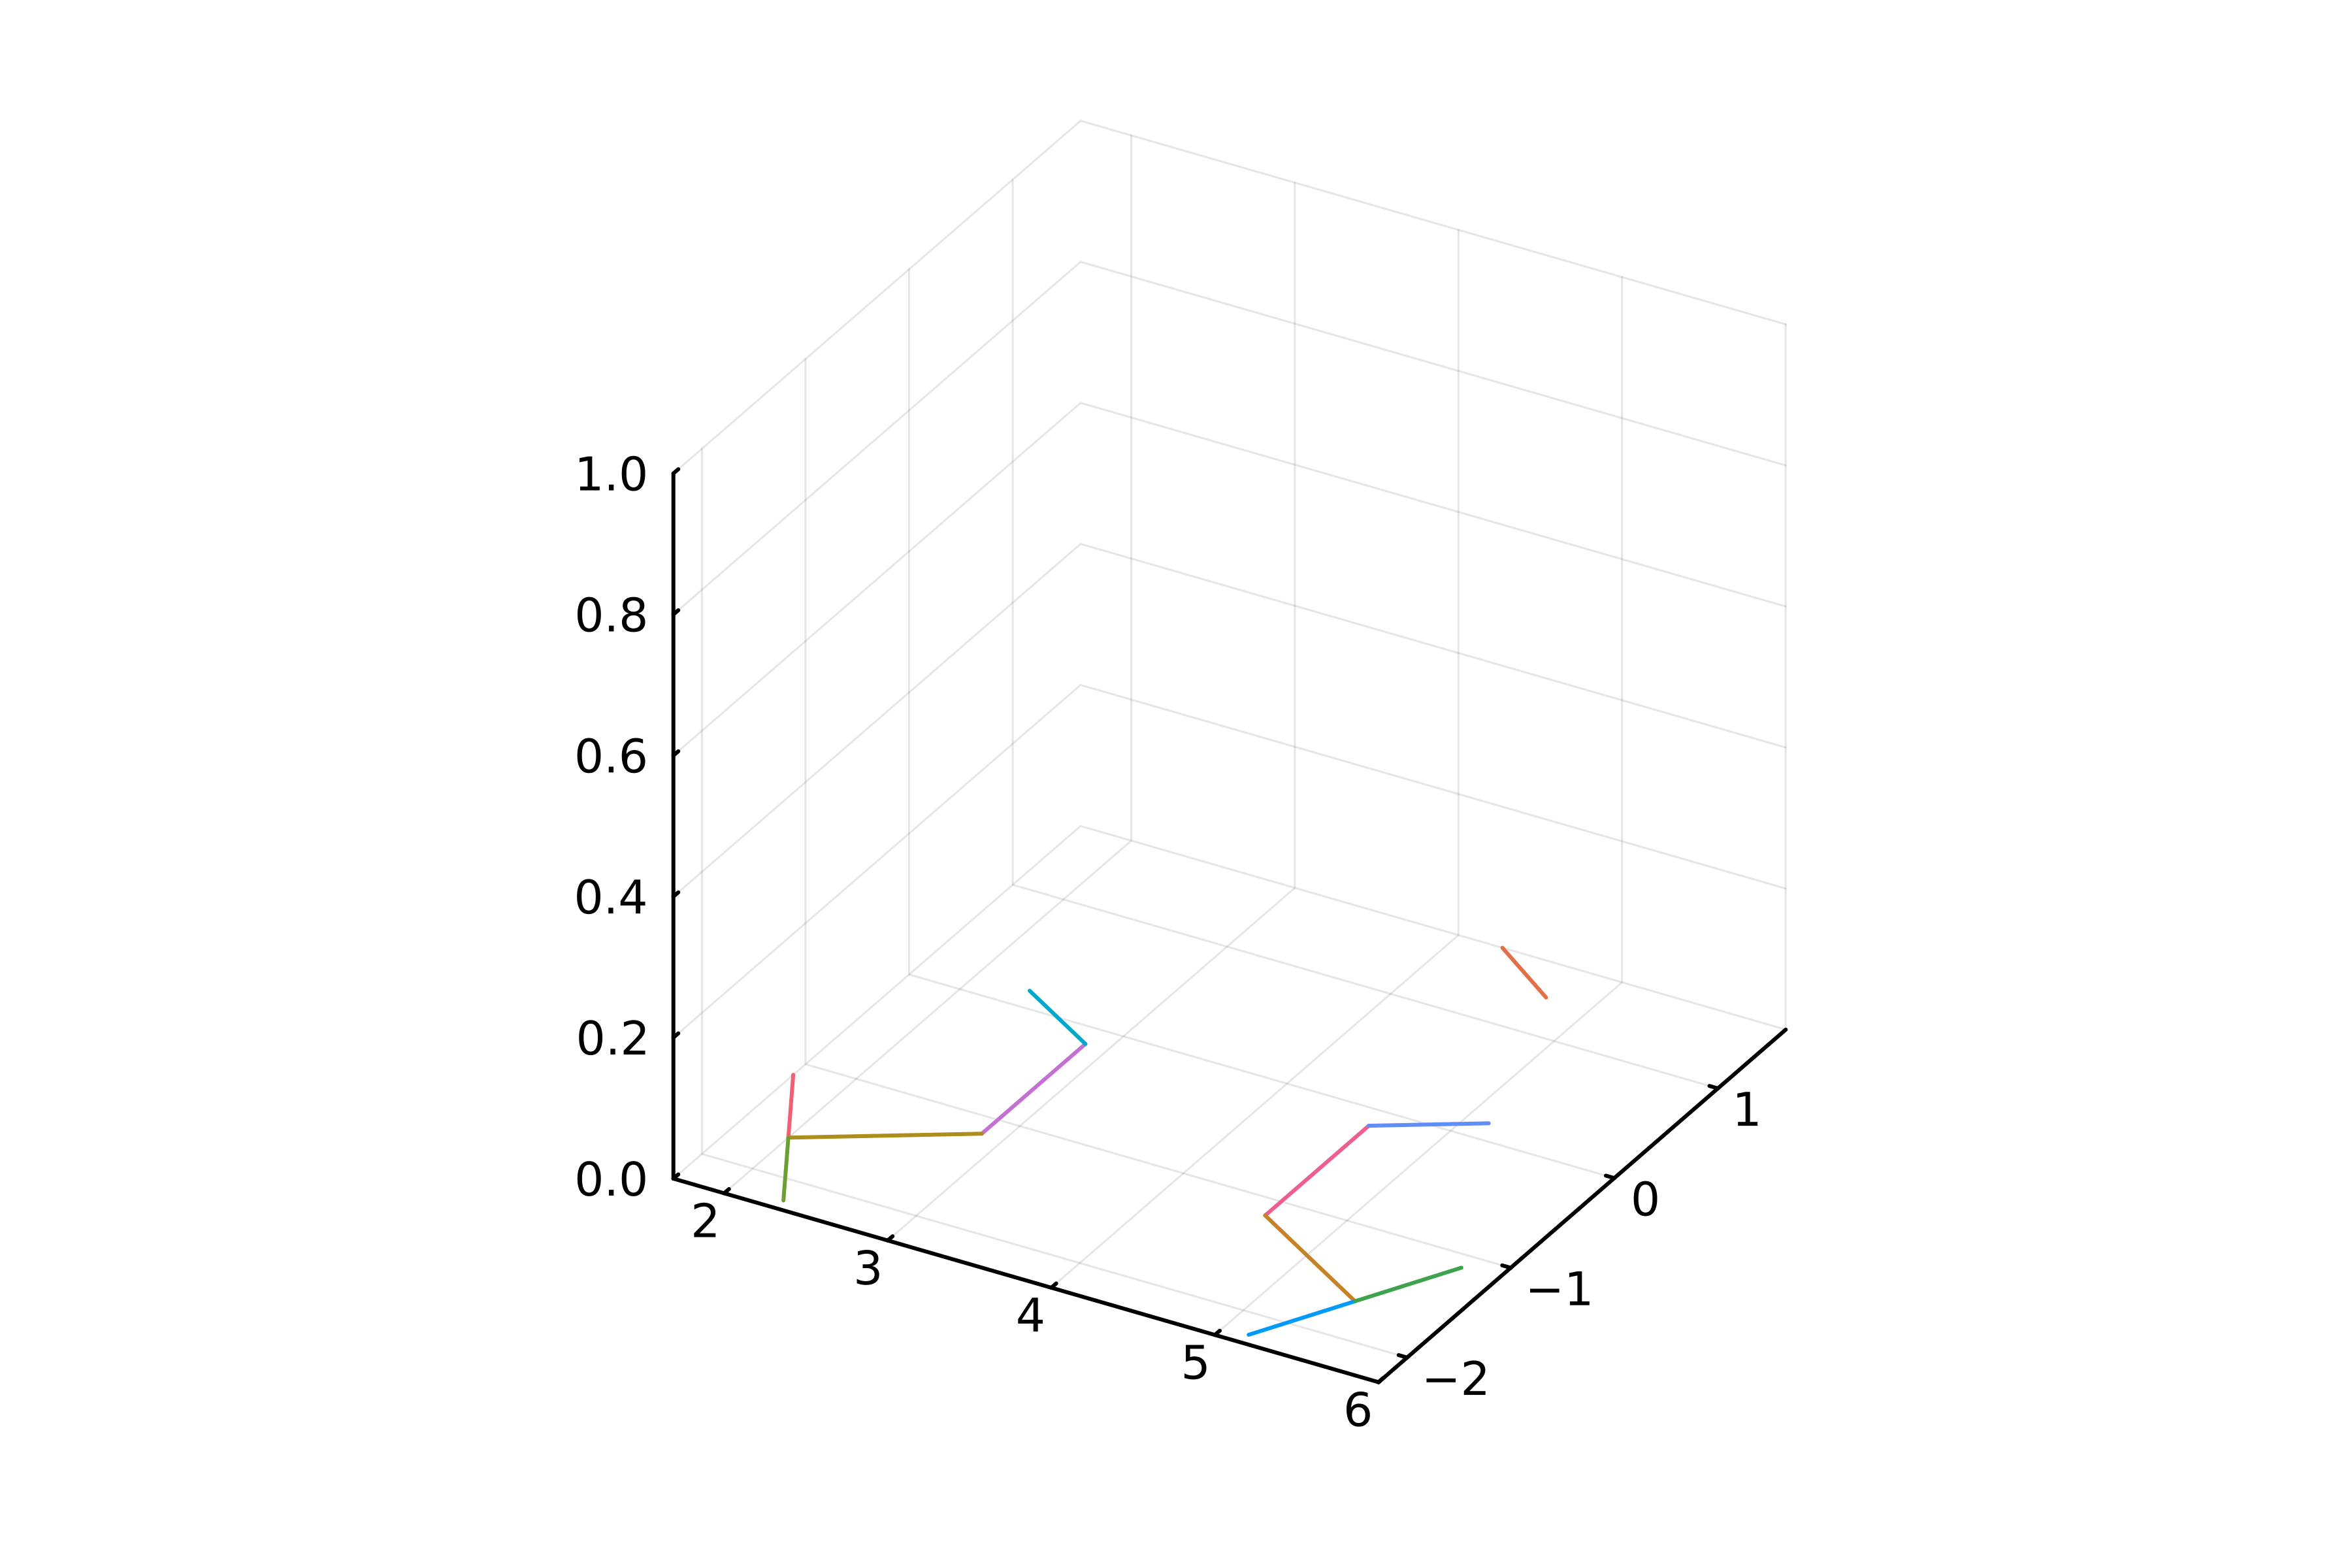

../Structure2D_COMPOUND_CID_7948.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_ejMPYDKFyb.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_IPonYdmxQZ.gif")
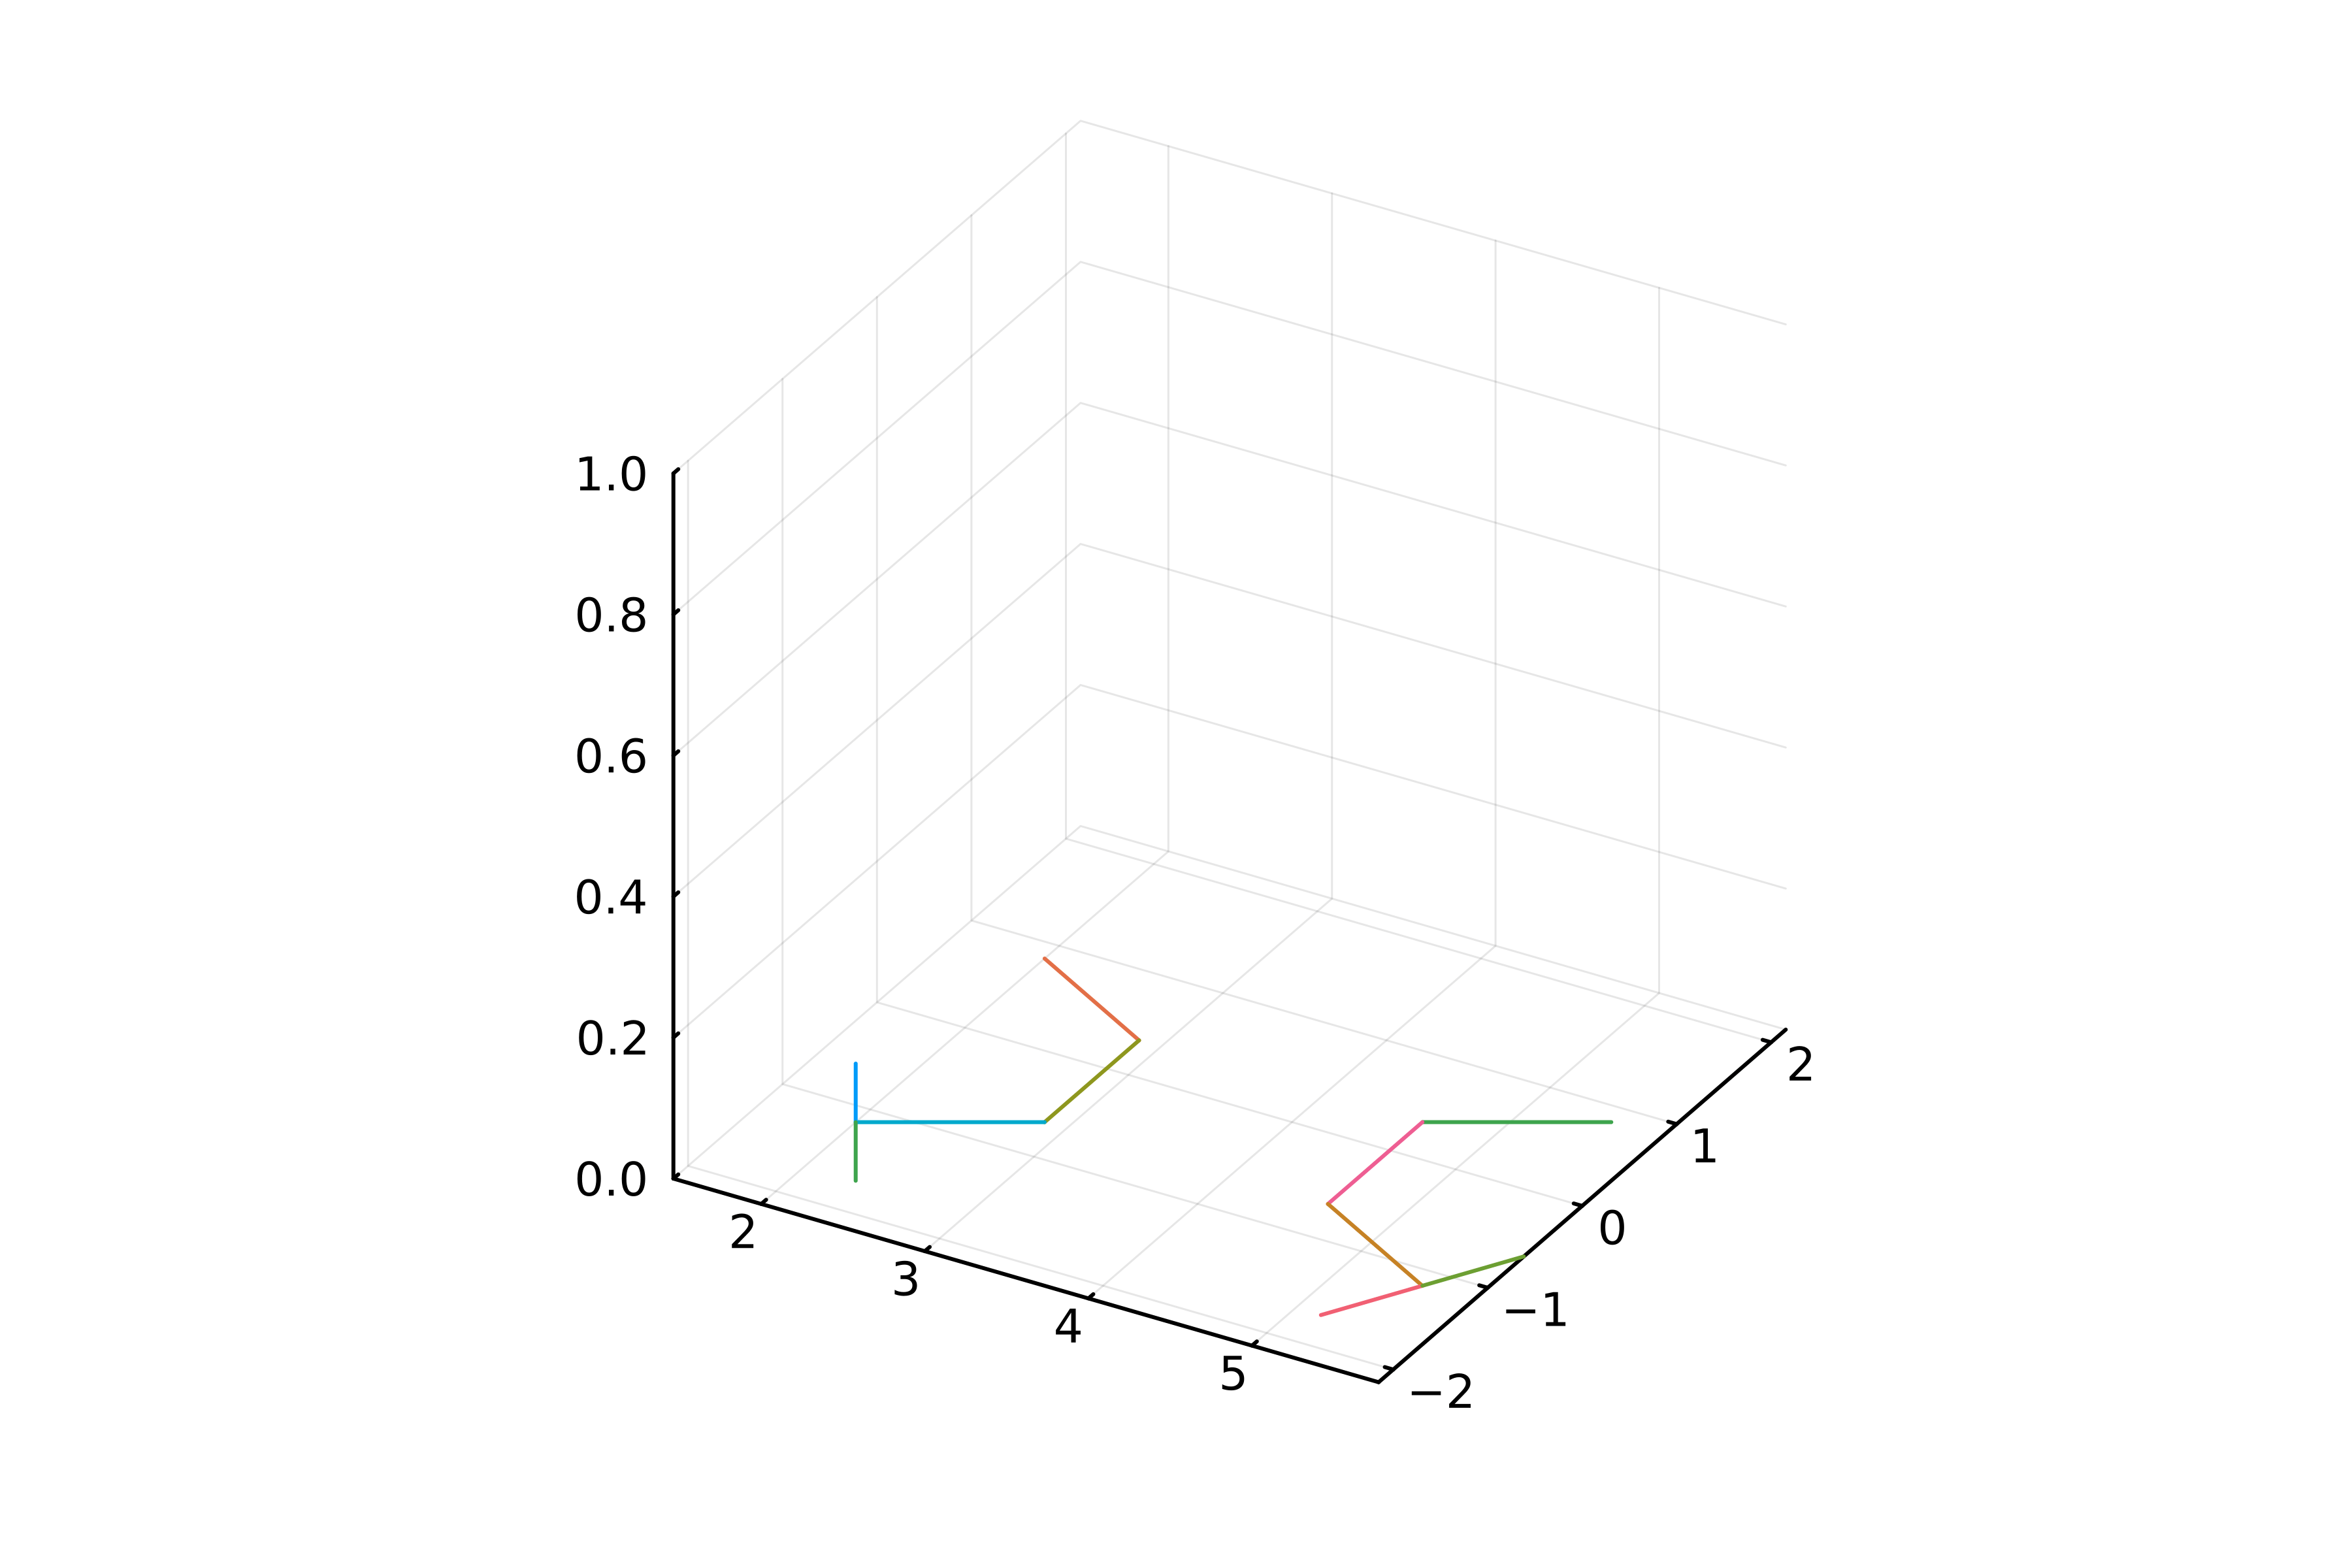

../Structure2D_COMPOUND_CID_81443.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_IPonYdmxQZ.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:606


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_ebMjiTErgz.gif")
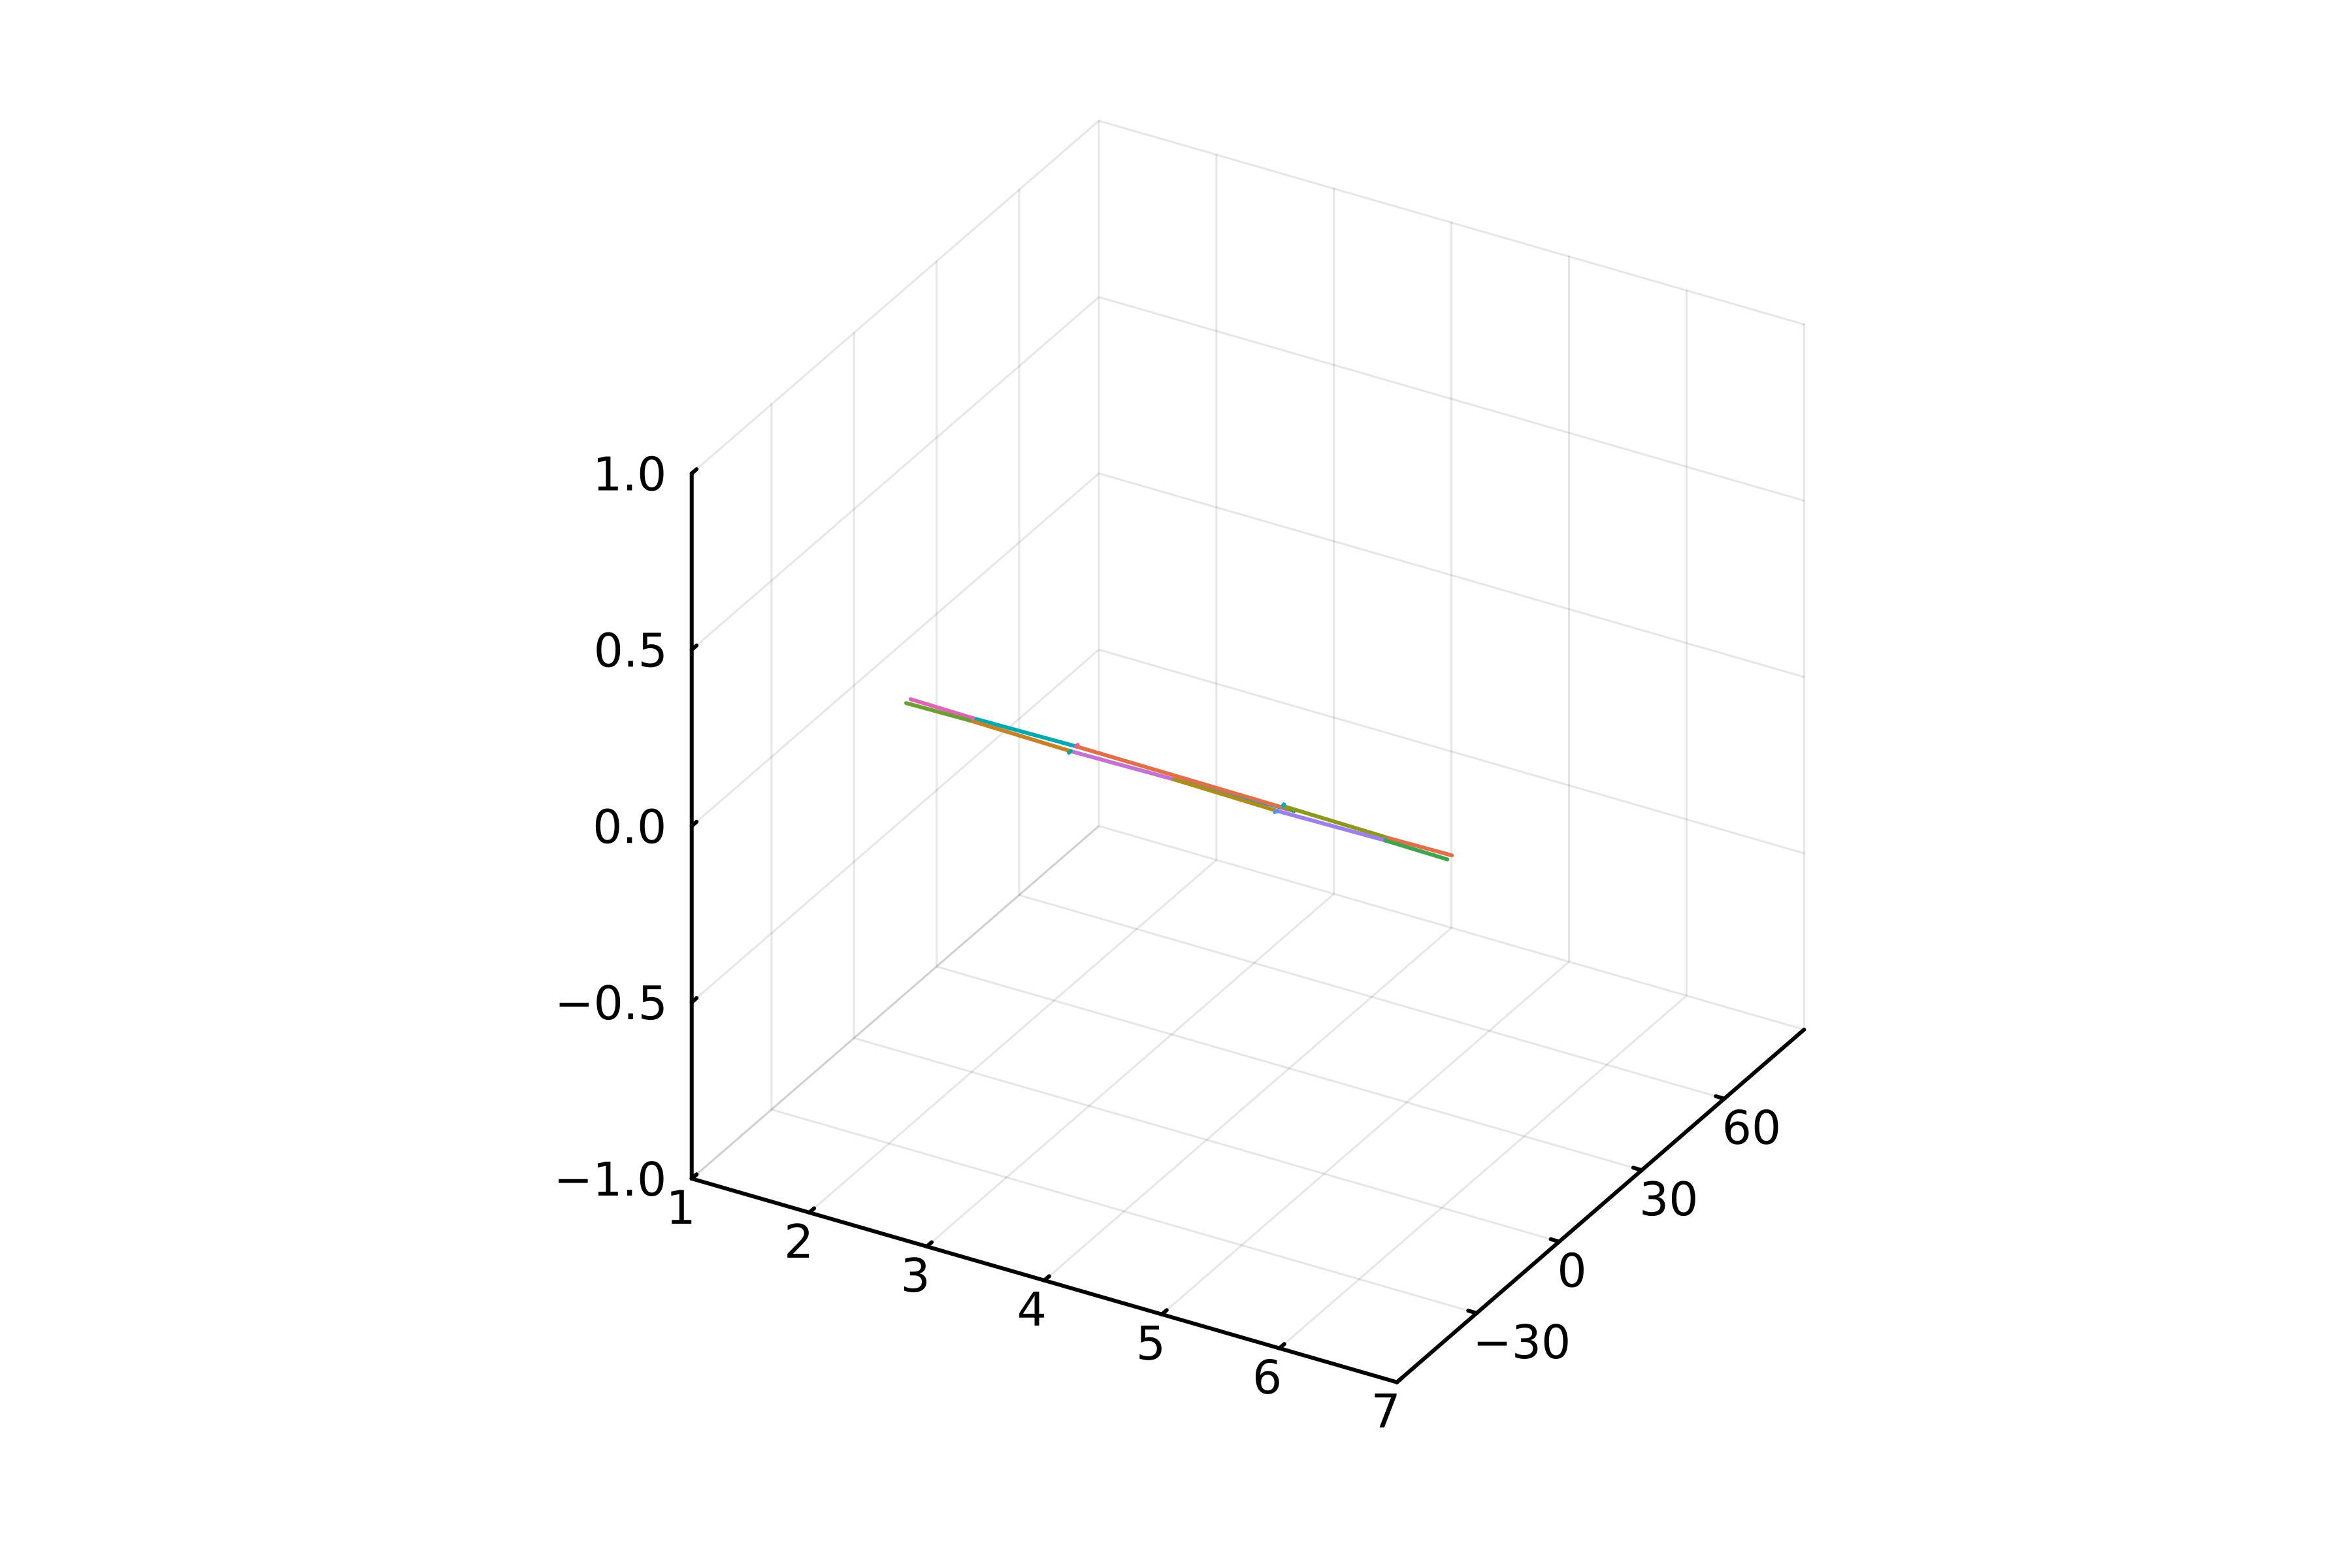

../Structure2D_COMPOUND_CID_931.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_ebMjiTErgz.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: dt(7.6293945e-6) <= dtmin(7.6293945e-6) at t=0.0, and step error estimate = NaN. Aborting. There is either an error in your model specification or the true solution is unstable.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:599


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_uNCh8JO3qr.gif")
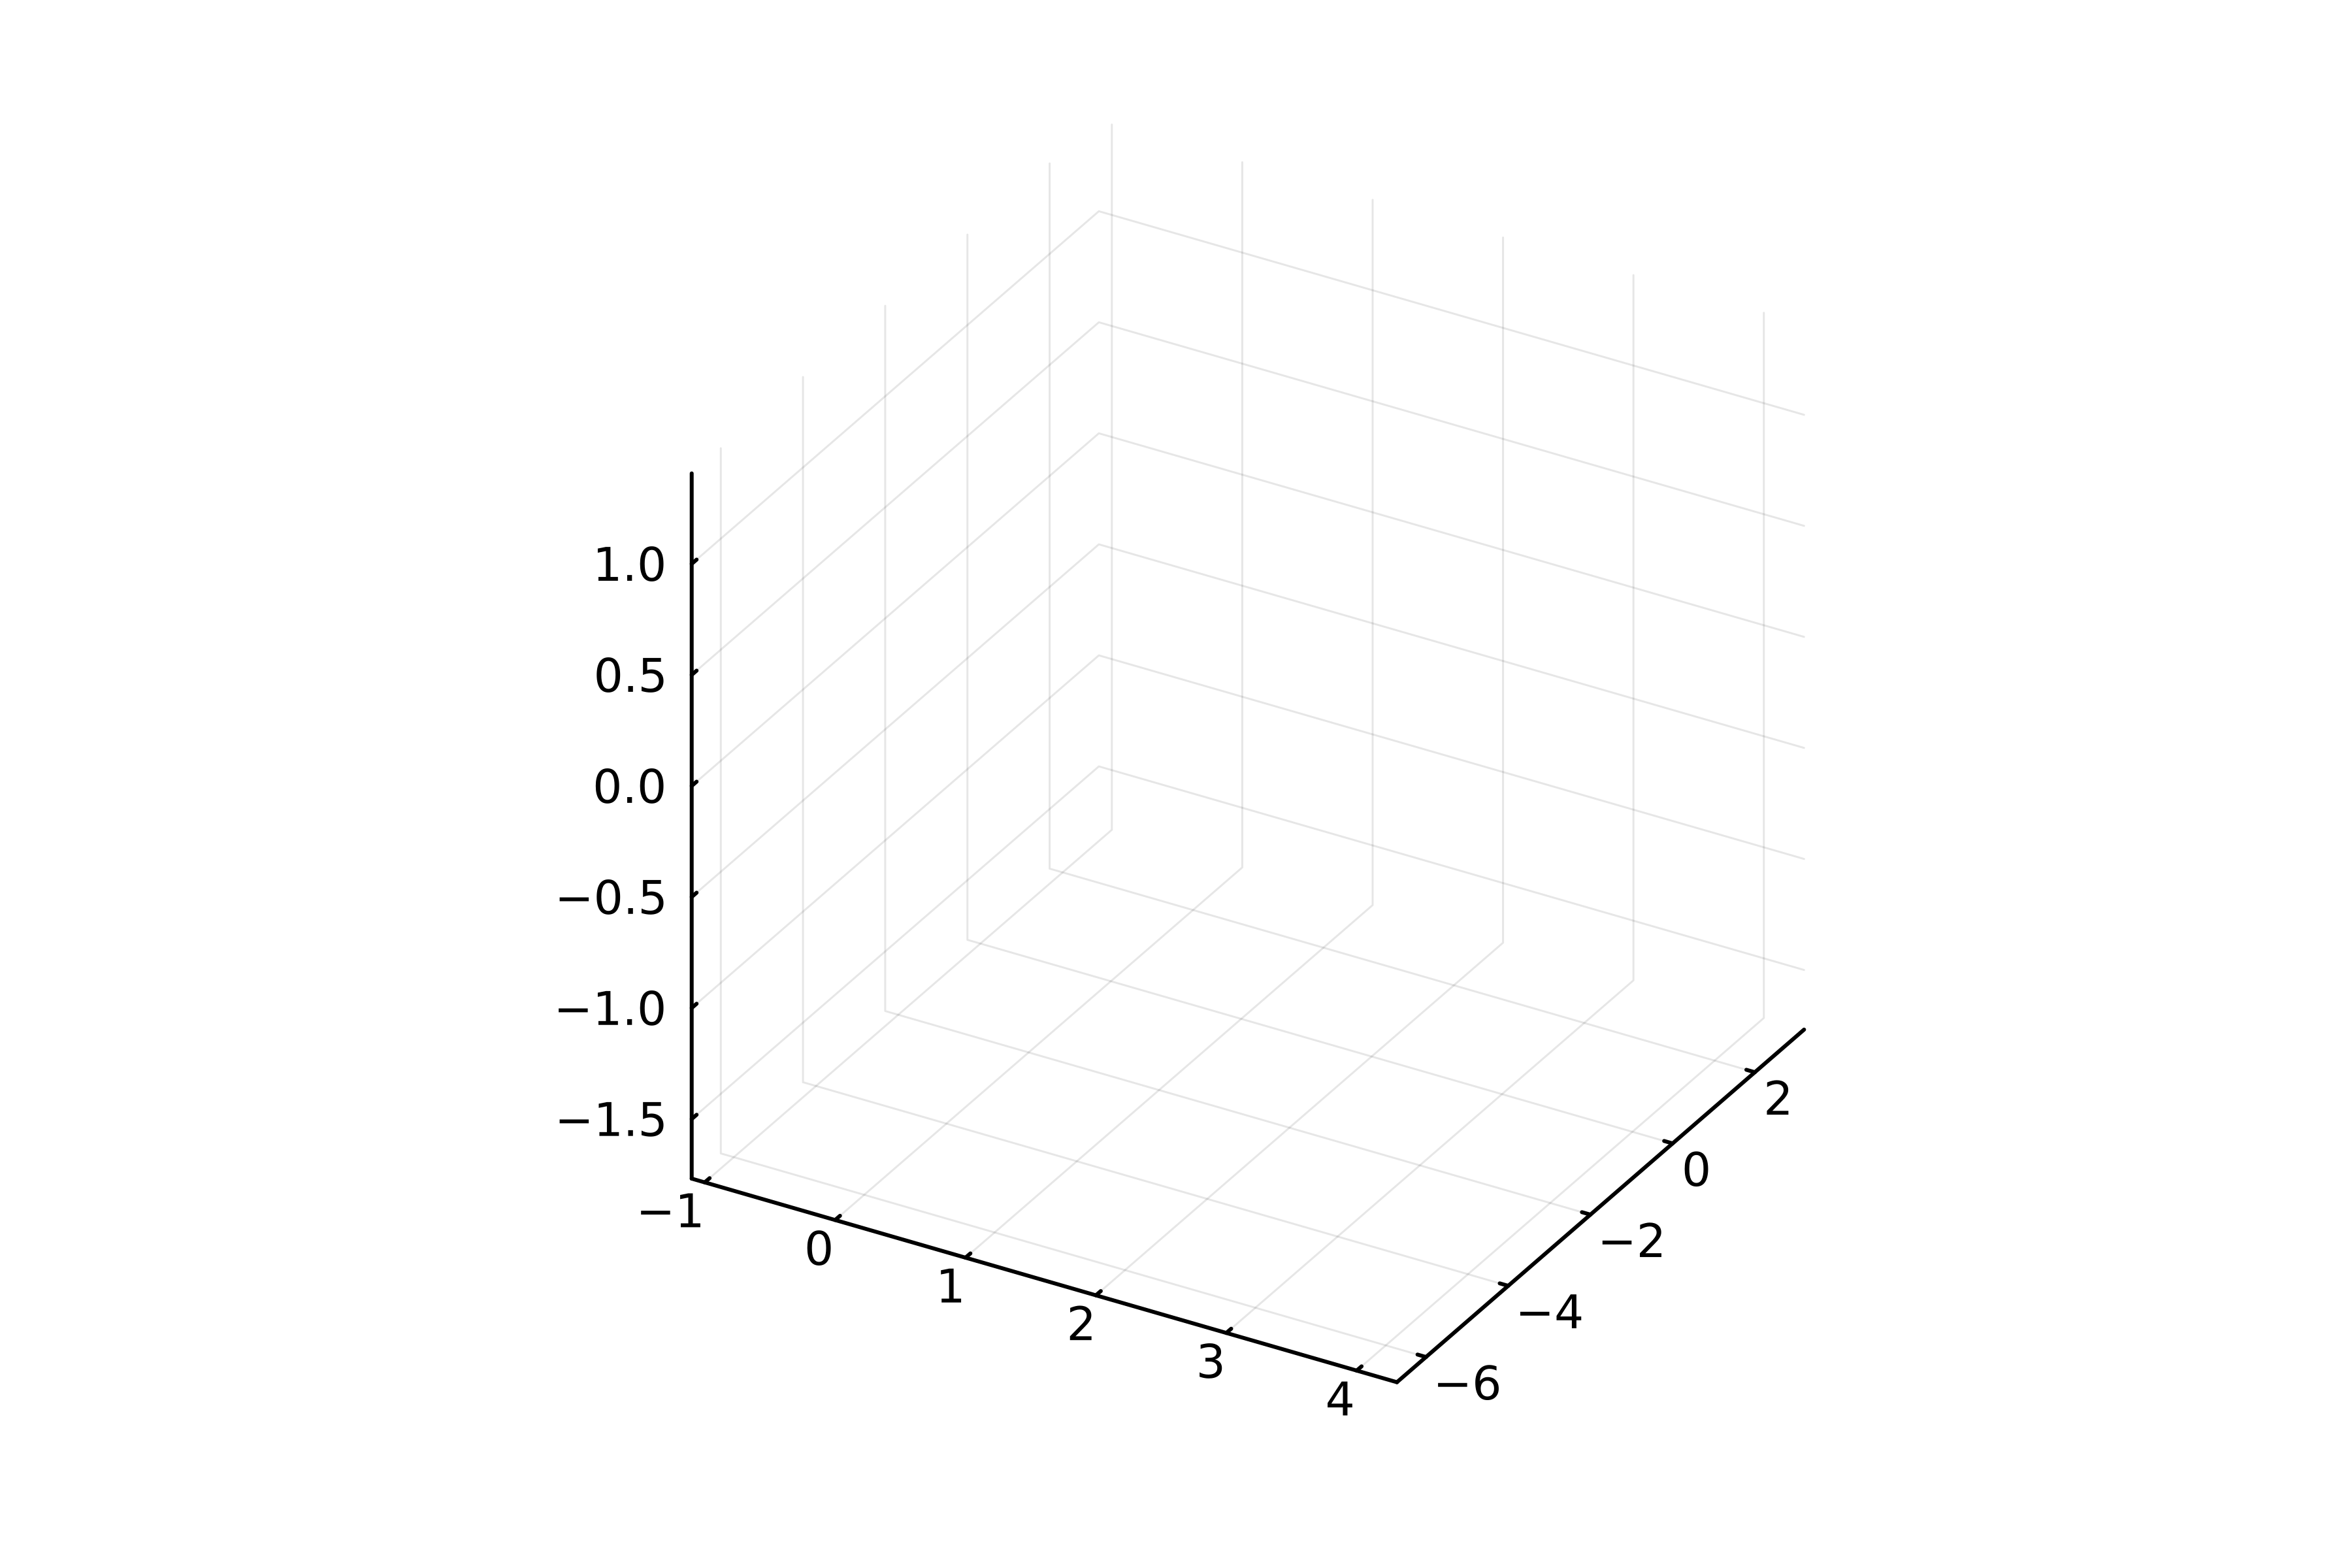

../adenosine.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_uNCh8JO3qr.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_I1OxUj4Vup.gif")
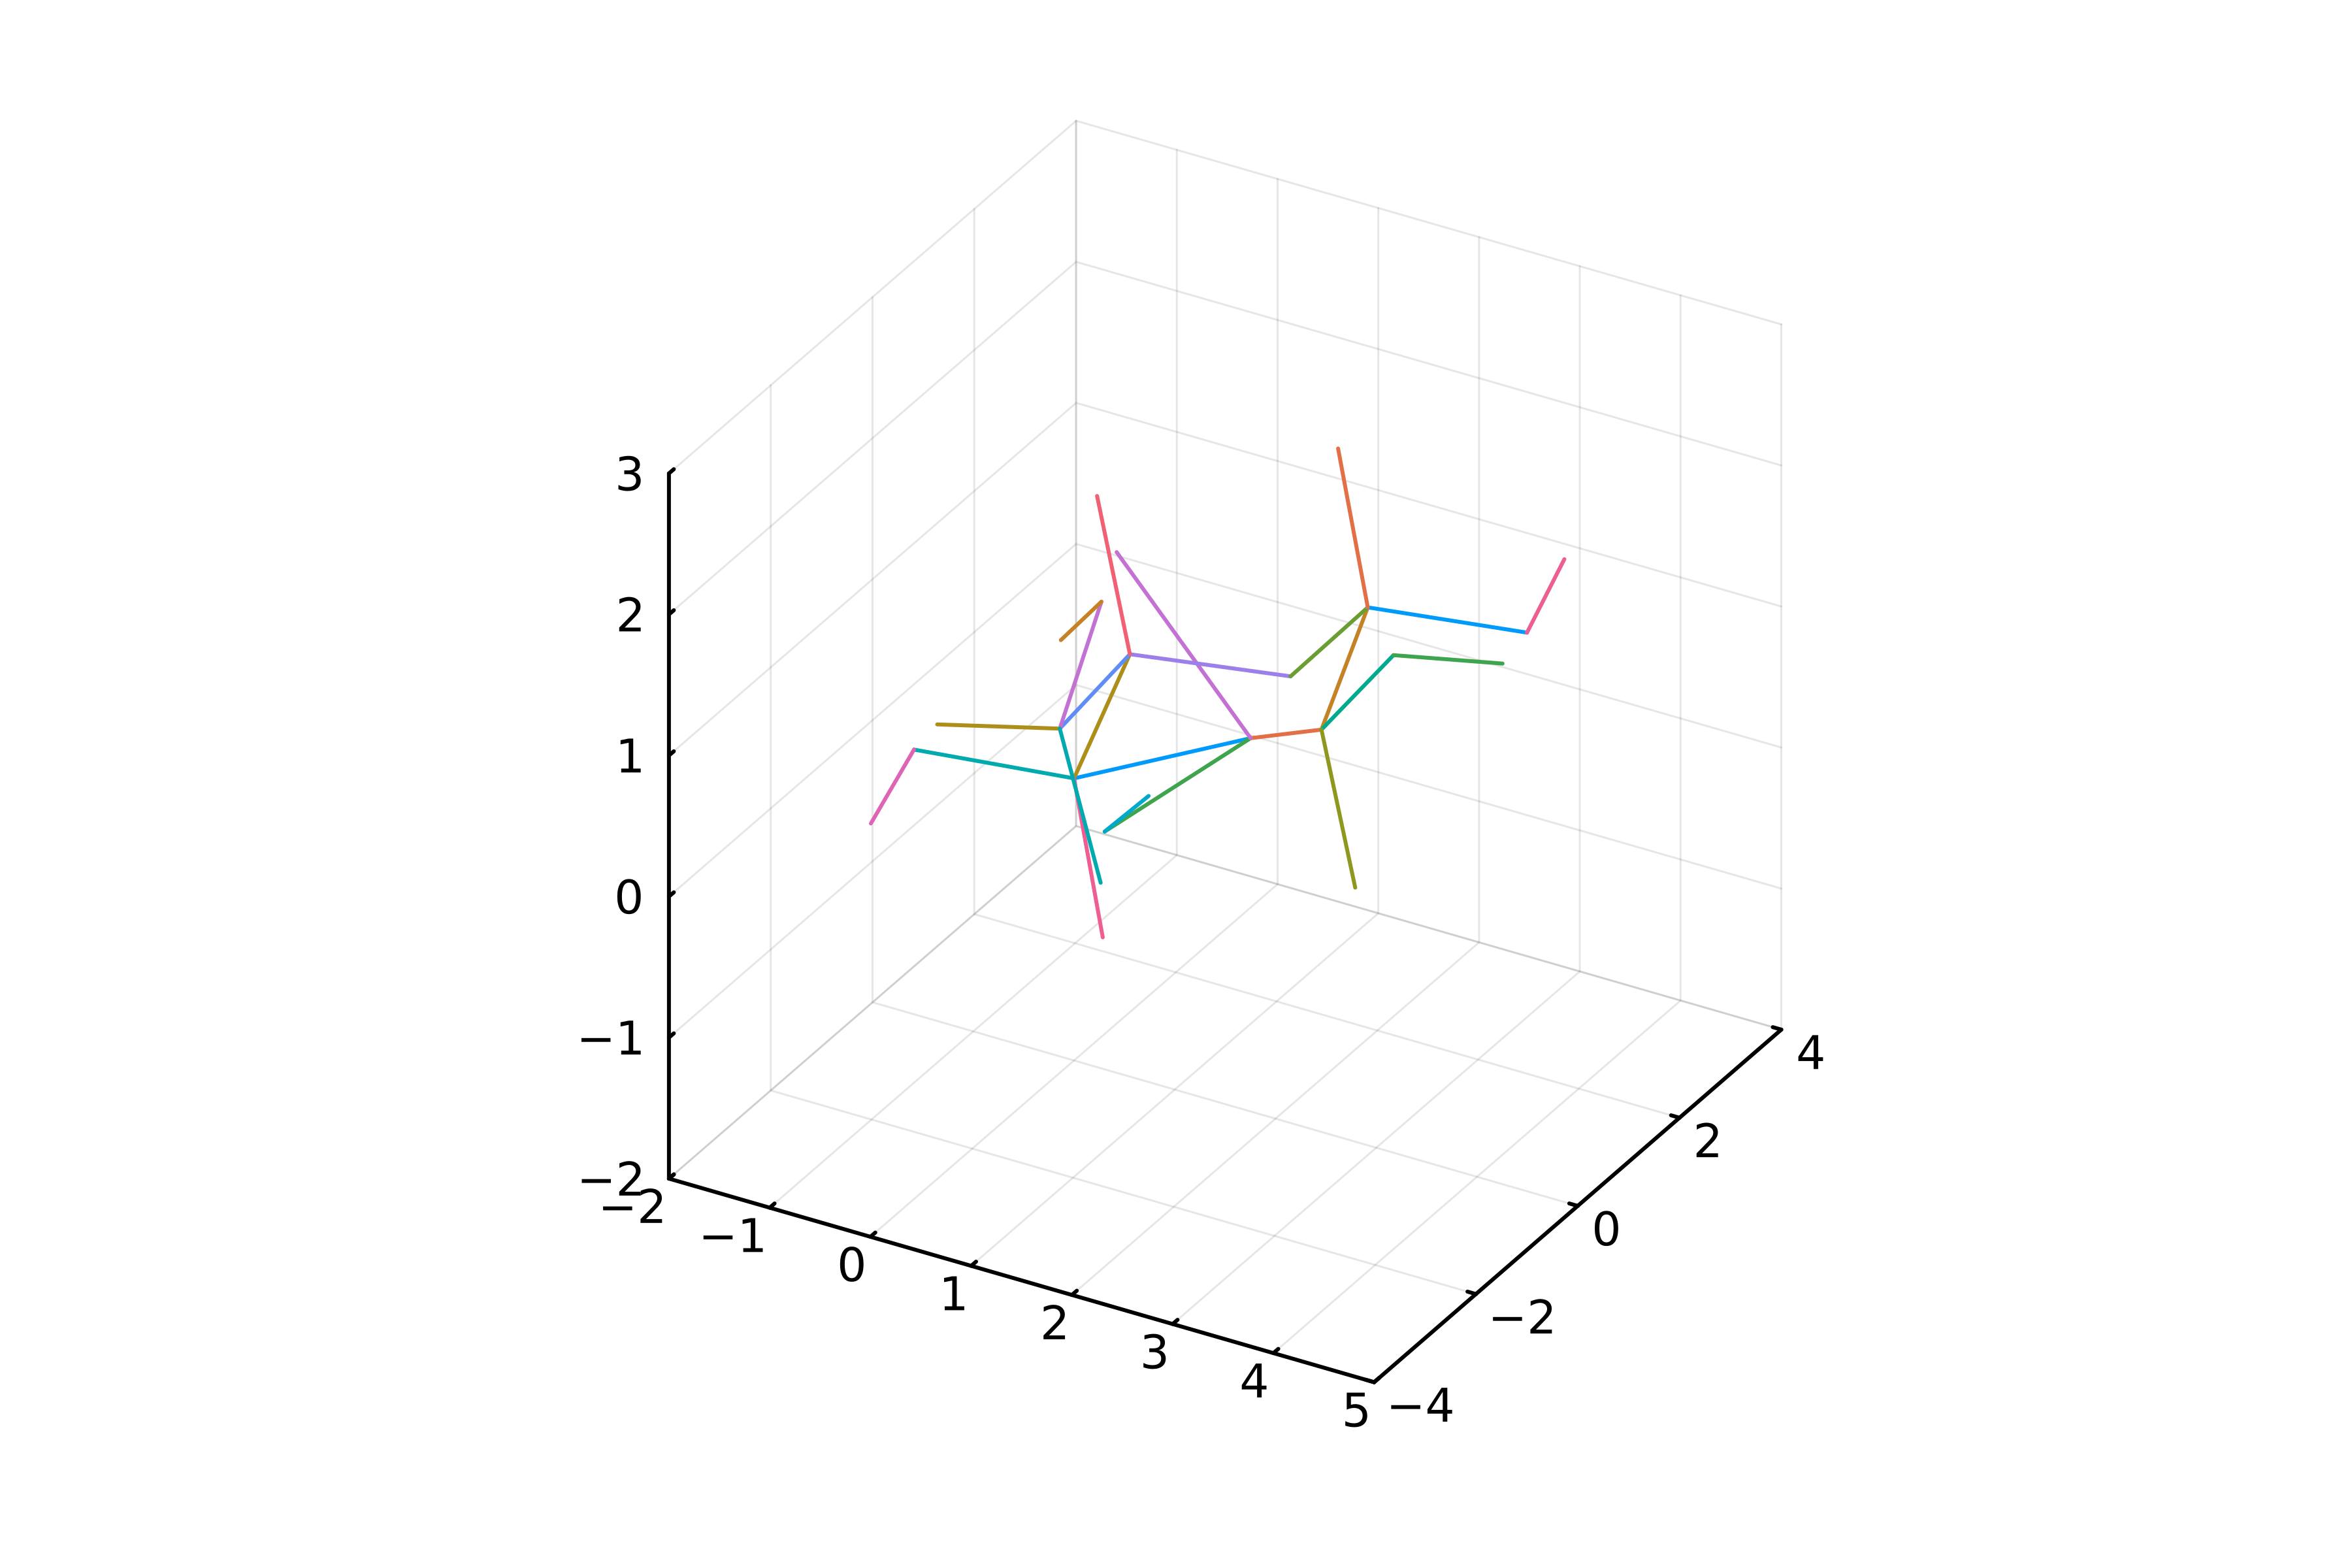

../beta-D-glucose-3D-structure-CT1000926869.sdf

┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_I1OxUj4Vup.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156


┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Info: 1 unassigned Out Of Plane Bends.
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_out_of_plane_bend.jl:78
┌ Warning: dt(7.6293945e-6) <= dtmin(7.6293945e-6) at t=0.0, and step error estimate = NaN. Aborting. There is either an error in your model specification or the true solution is unstable.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:599


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_4xIFY7Orev.gif")
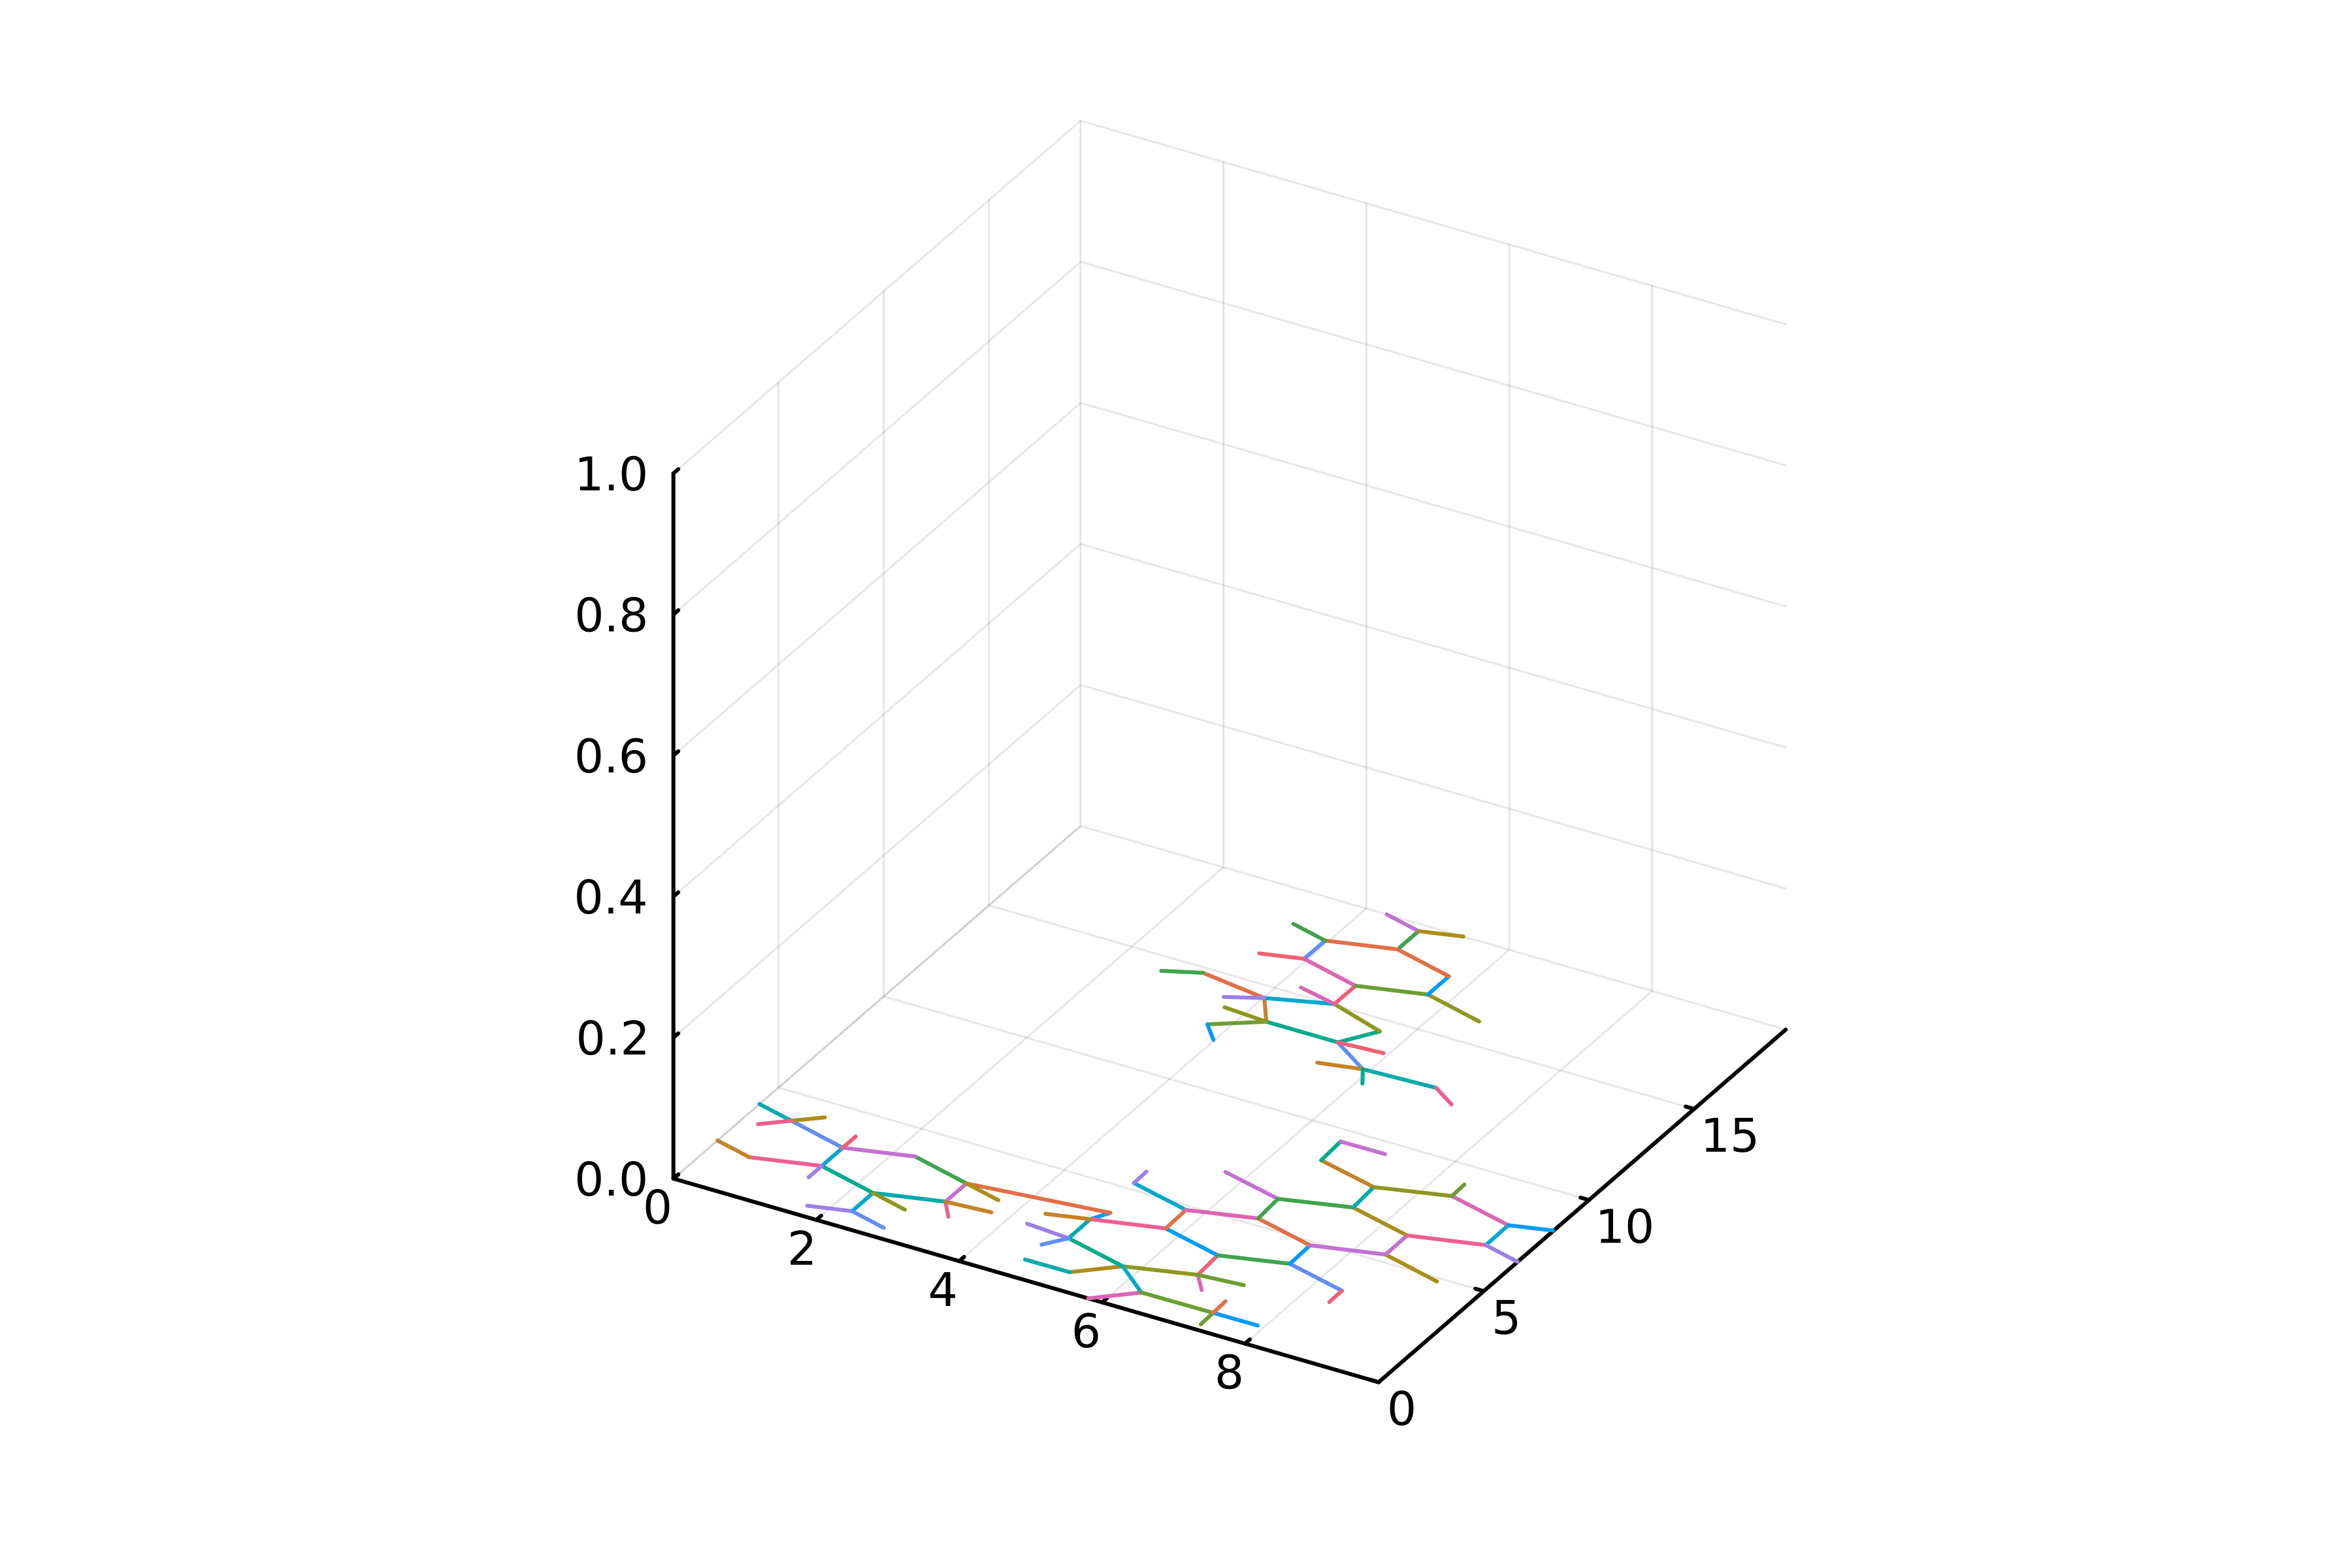

../cpx351.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_4xIFY7Orev.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_AlMvUjwpMD.gif")
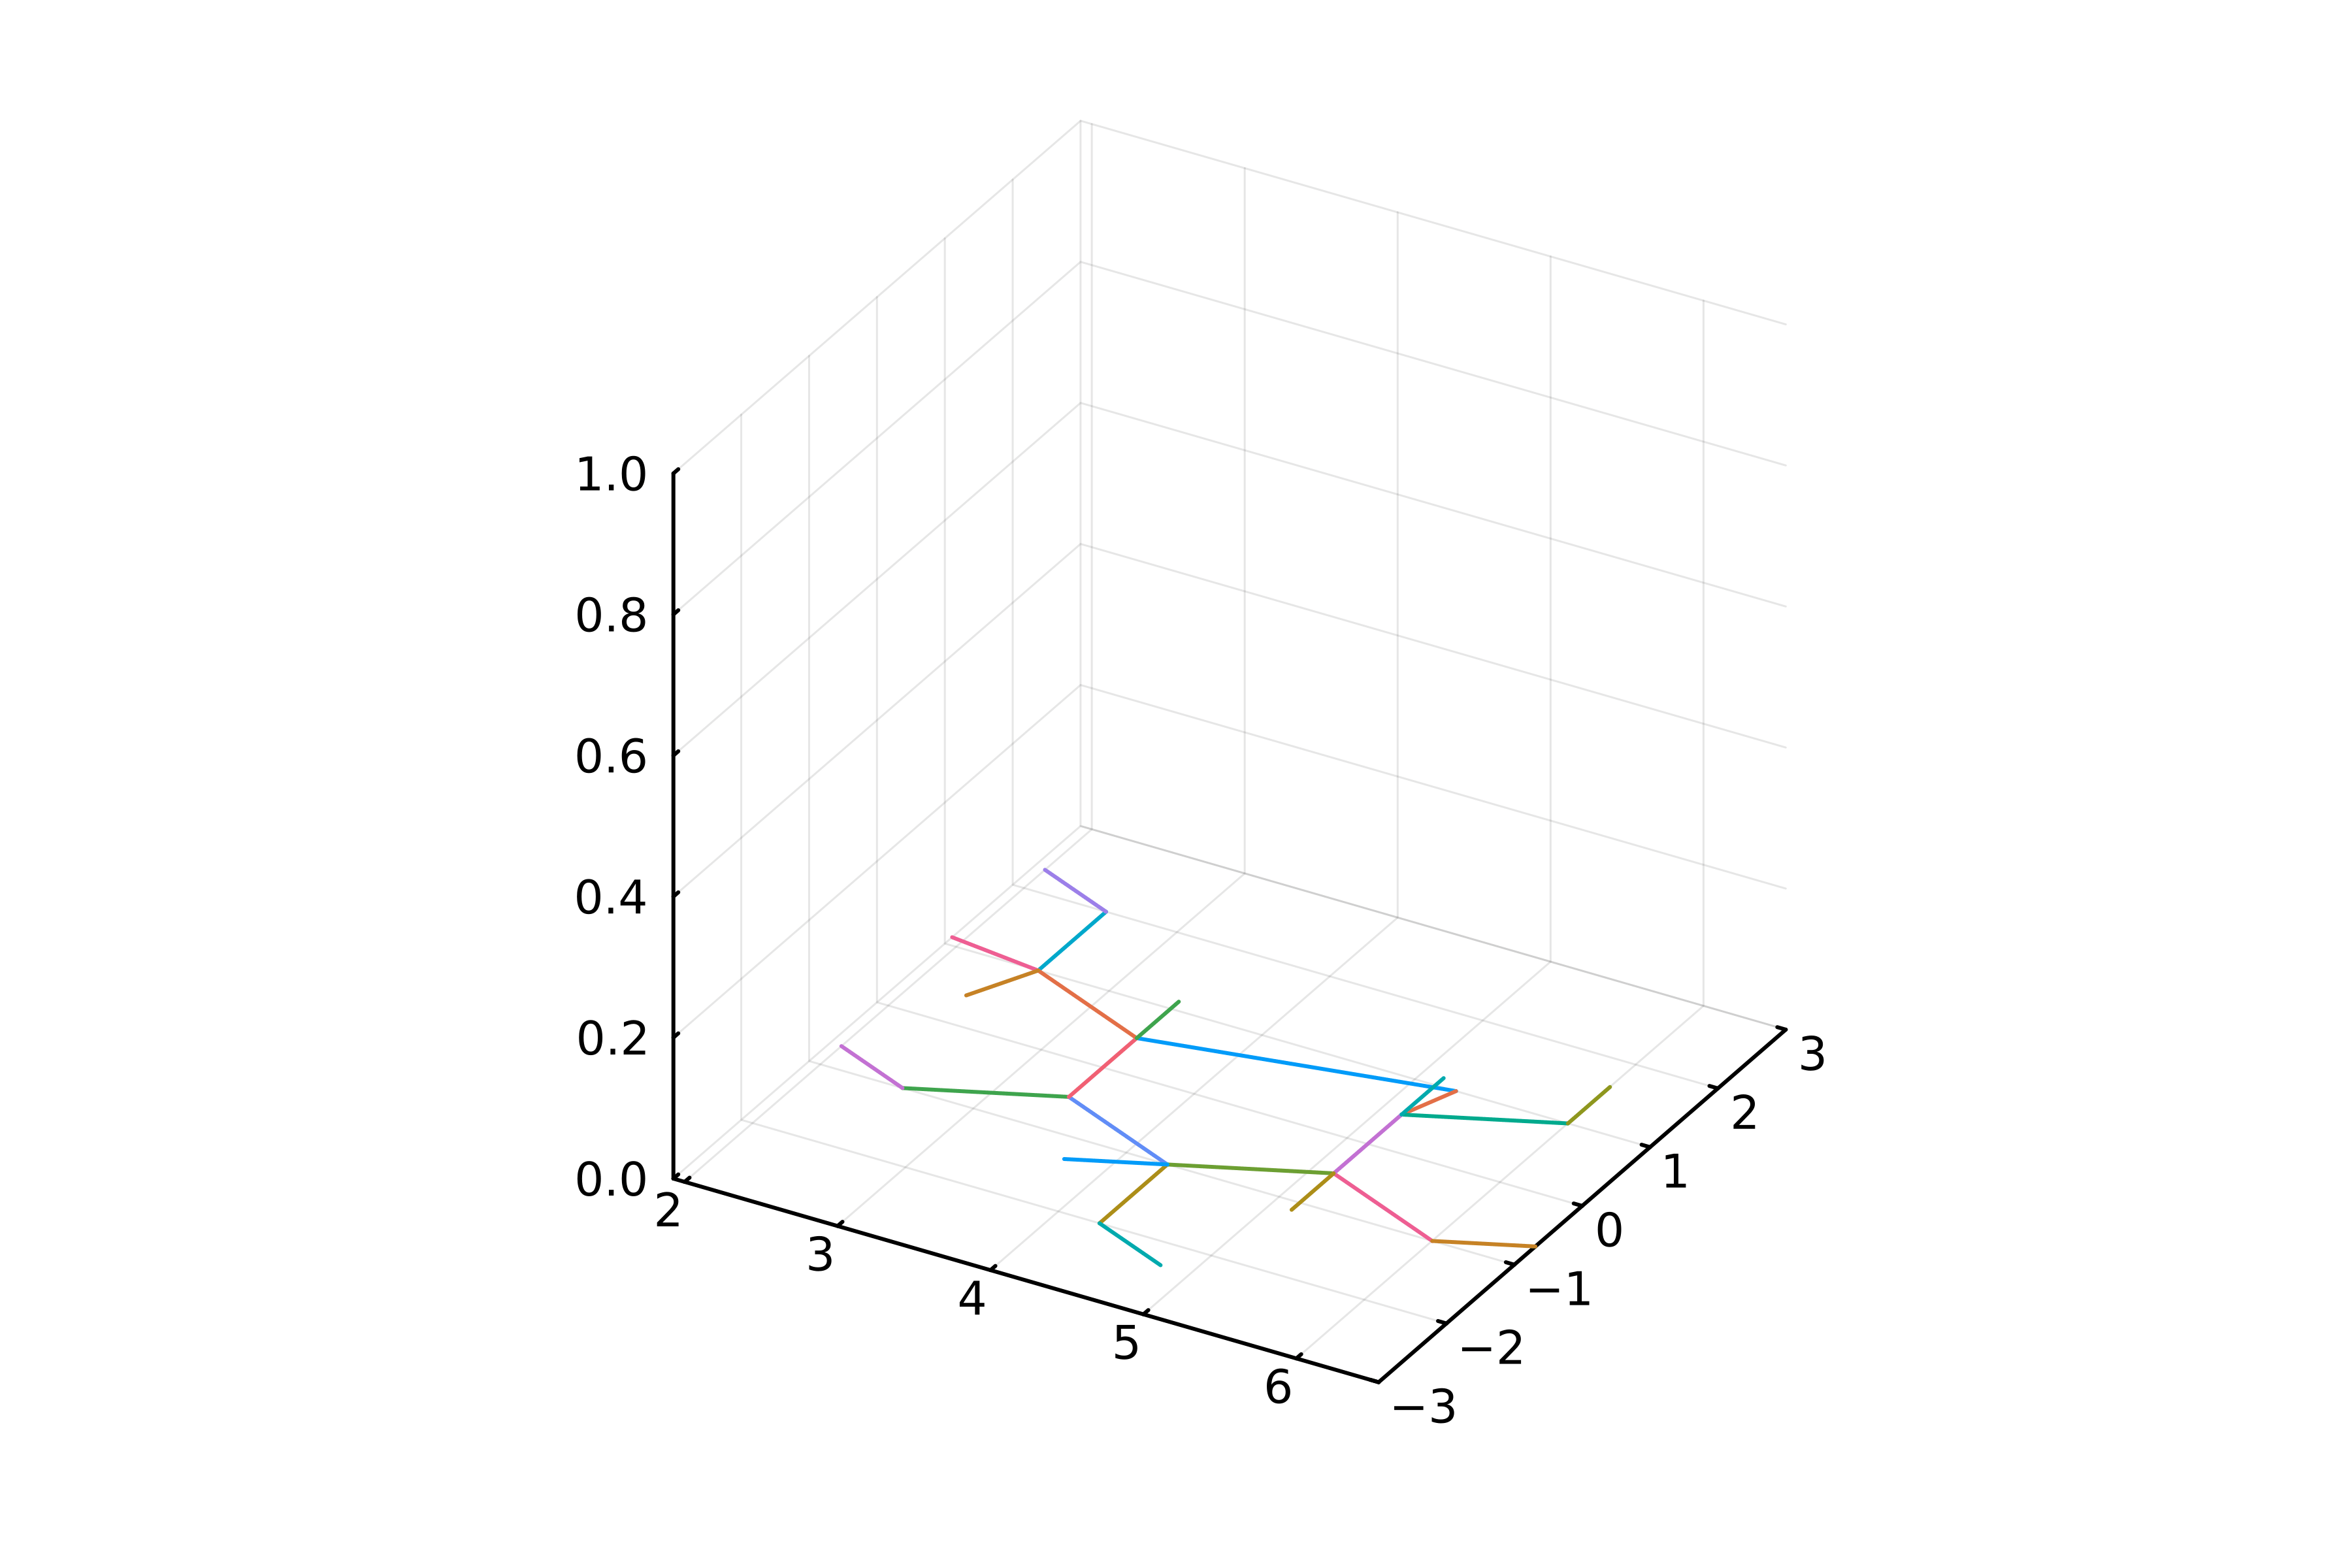

../glucose.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_AlMvUjwpMD.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_CjA1arWH2b.gif")
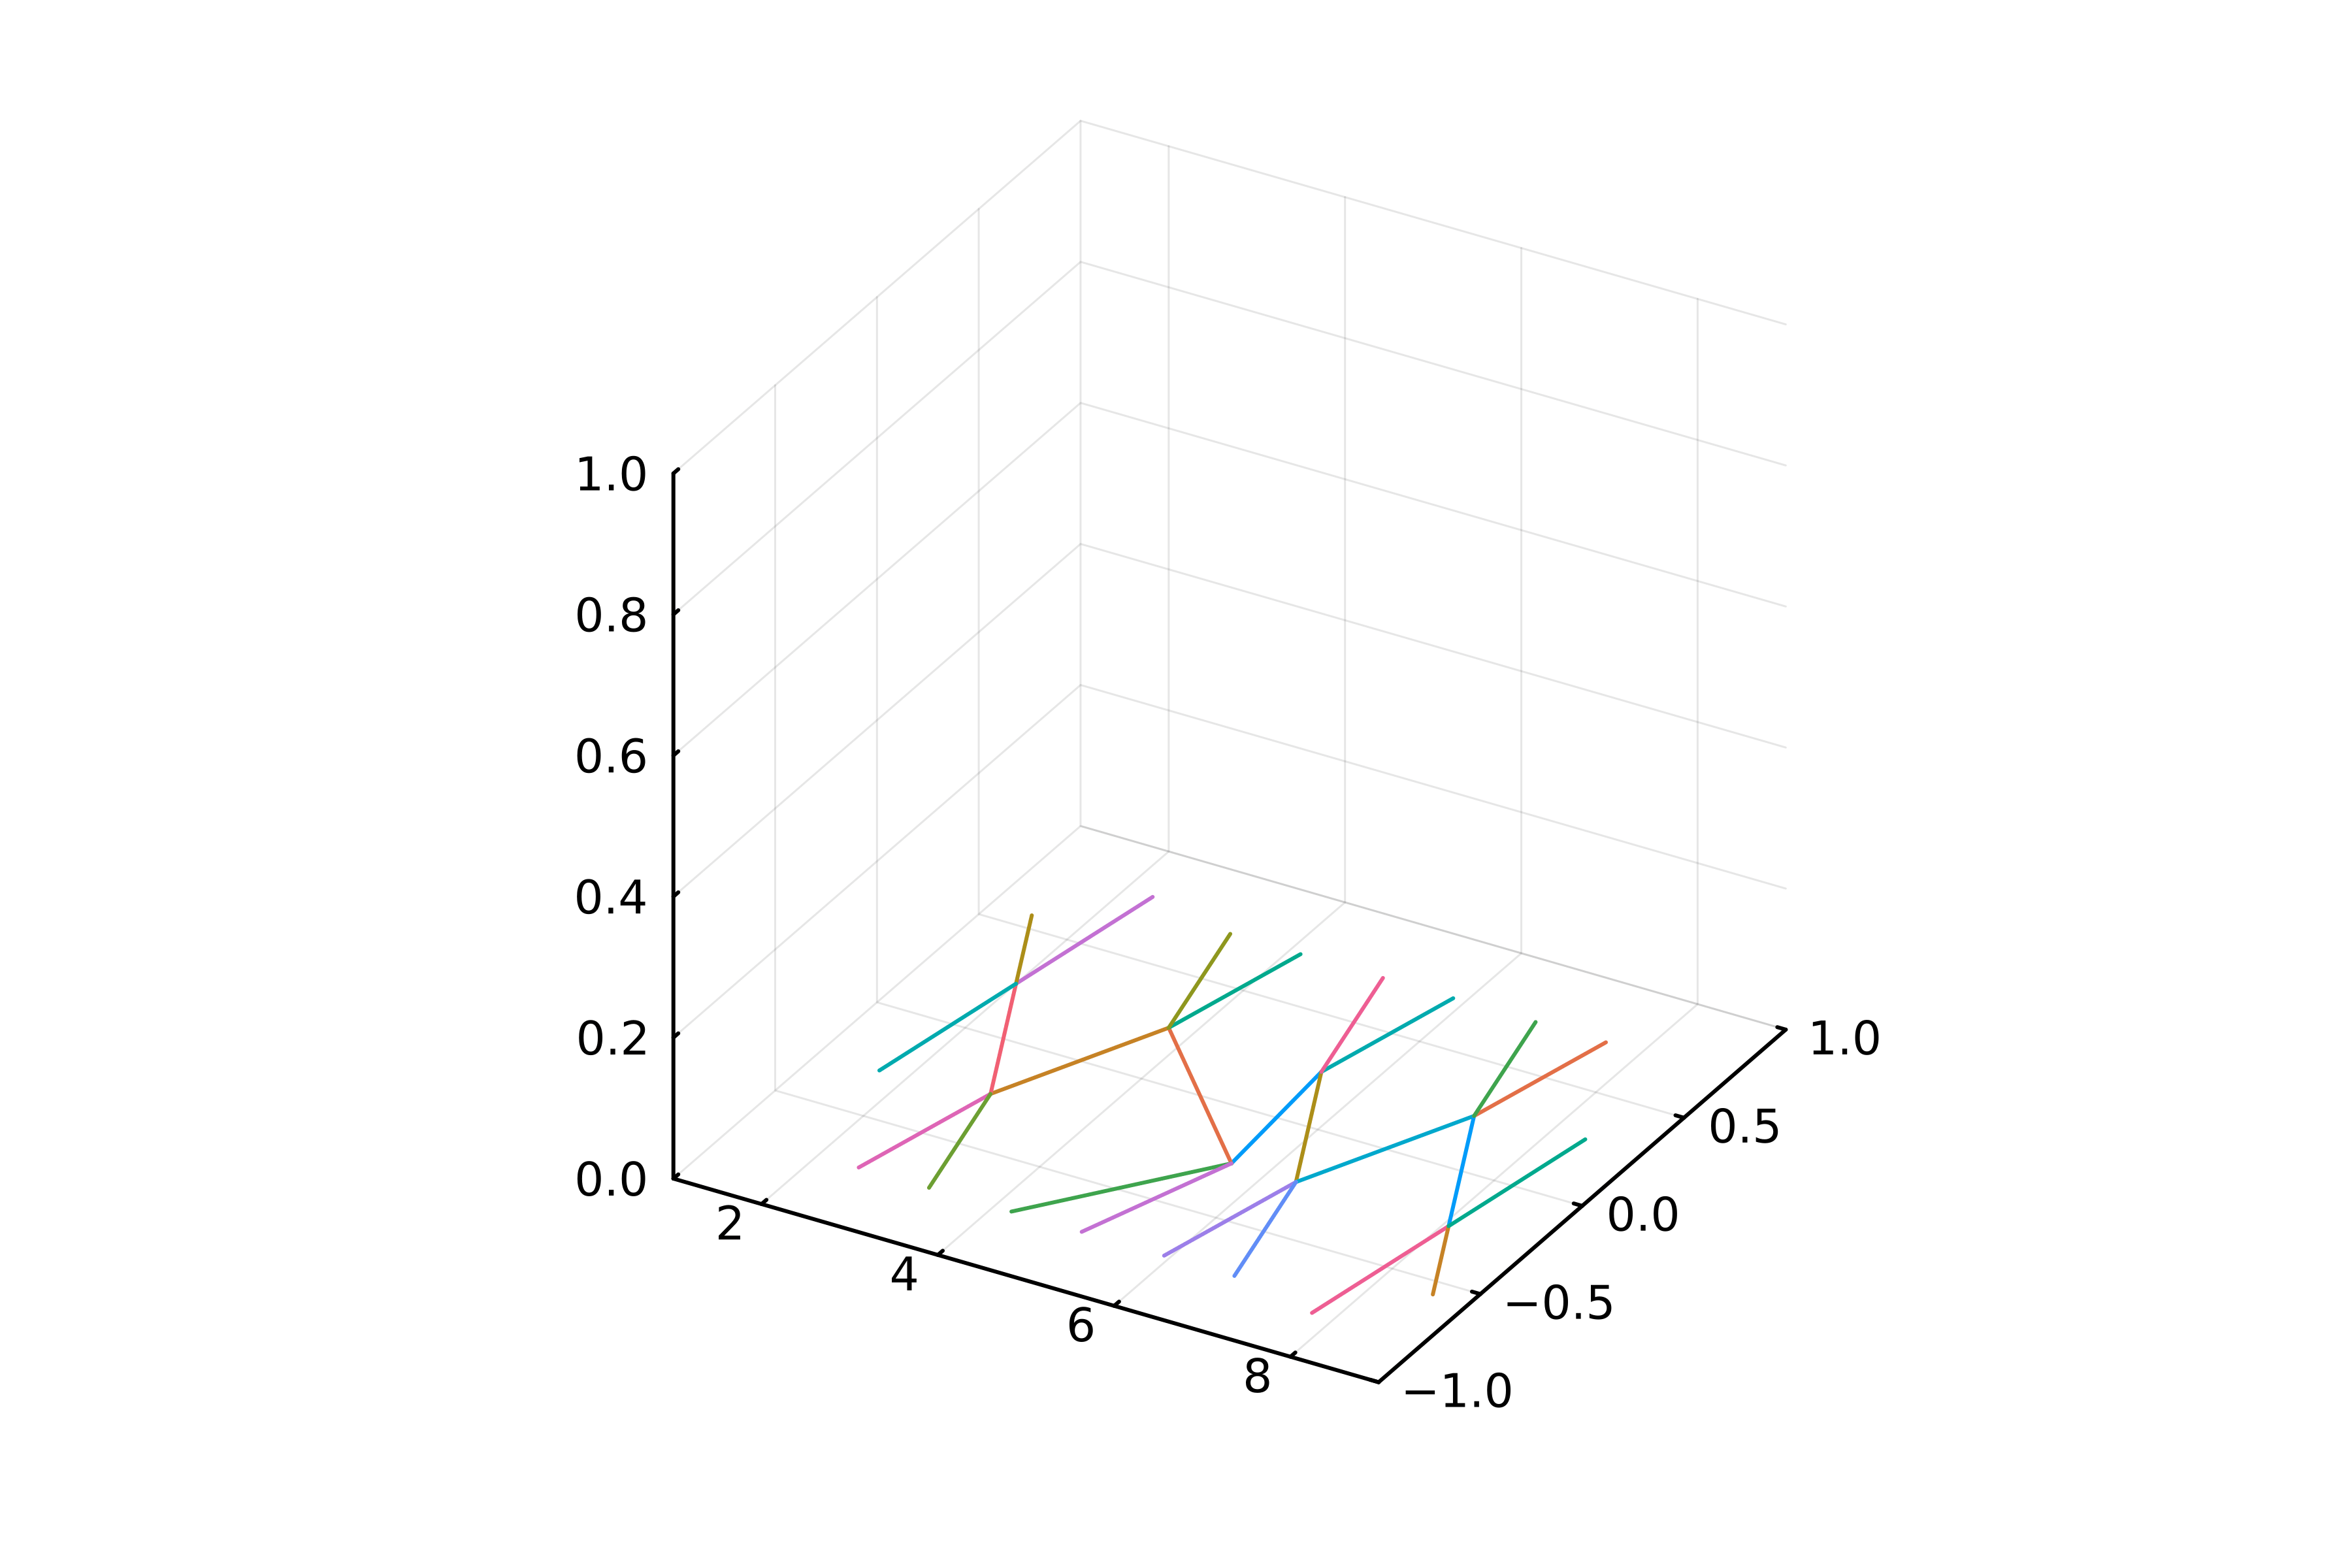

../octane.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_CjA1arWH2b.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:606


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_CVENsNwfm3.gif")
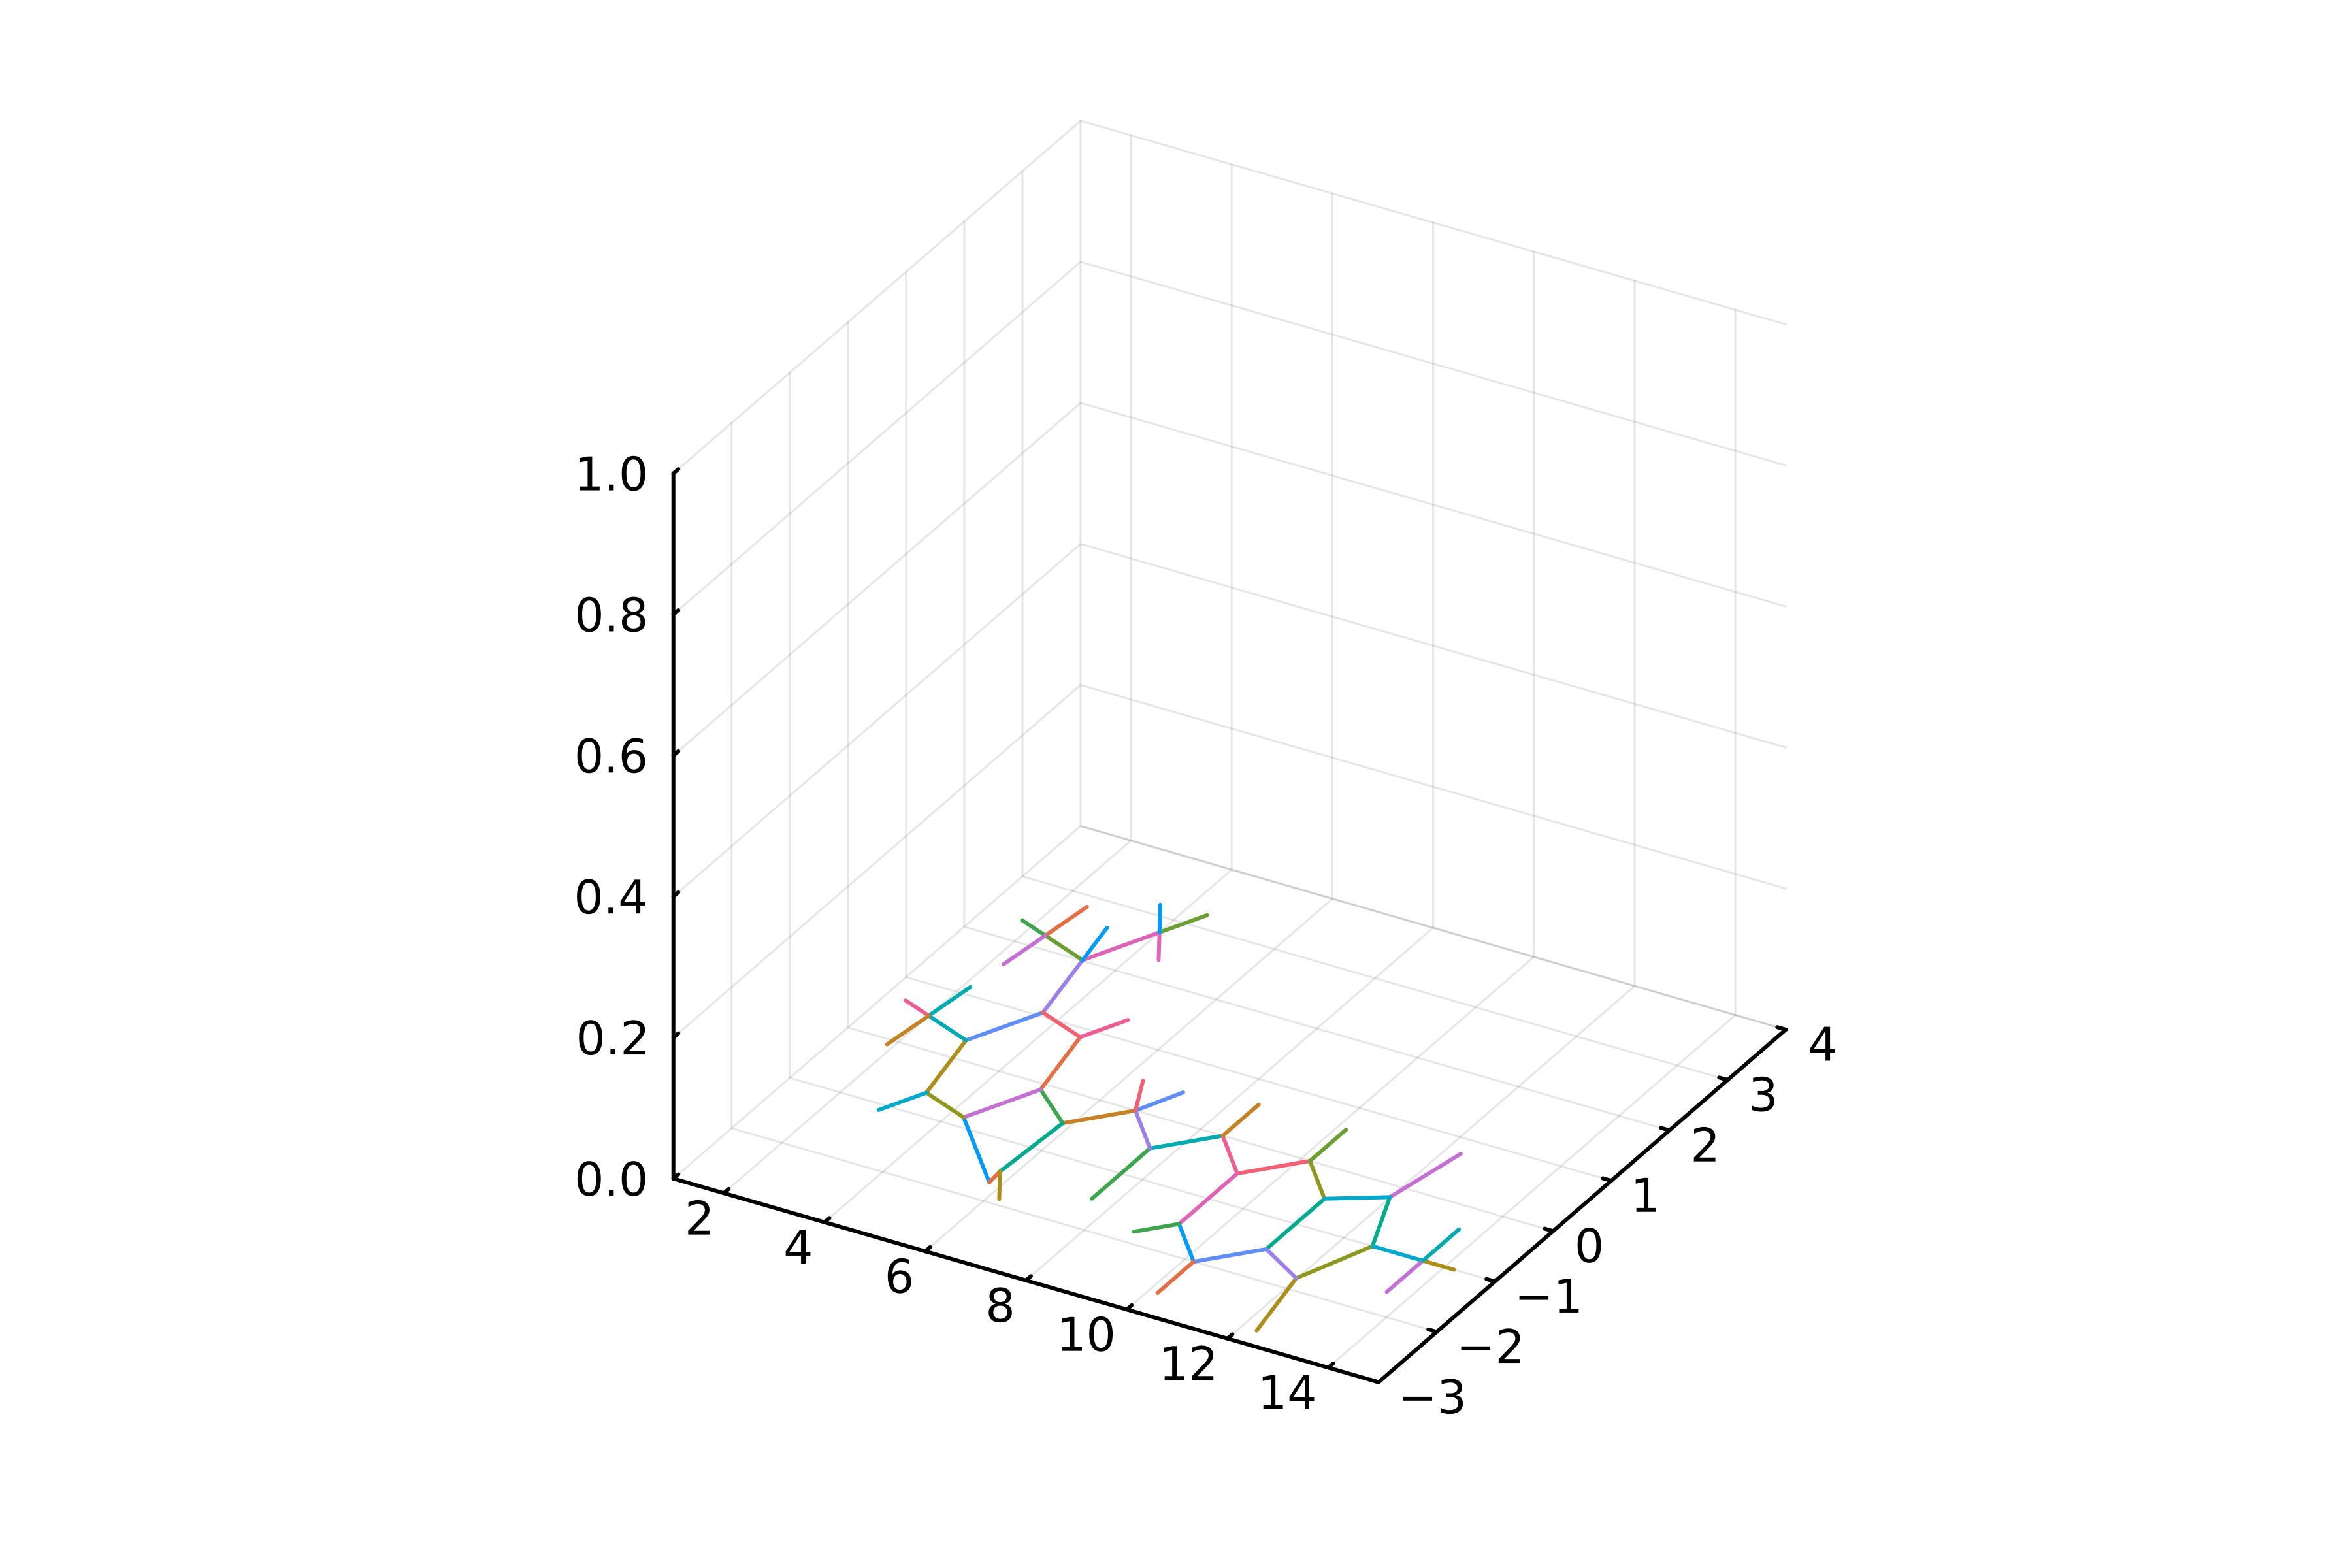

../temp.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_CVENsNwfm3.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156
┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Warning: Automatic dt set the starting dt as NaN, causing instability. Exiting.
└ @ OrdinaryDiffEq C:\Users\Dan\.julia\packages\OrdinaryDiffEq\FFFcA\src\solve.jl:562
┌ Warning: NaN dt detected. Likely a NaN value in the state, parameters, or derivative value caused this outcome.
└ @ SciMLBase C:\Users\Dan\.julia\packages\SciMLBase\szsYq\src\integrator_interface.jl:574


Plots.AnimatedGif("C:\\Users\\Dan\\AppData\\Local\\Temp\\jl_GDGvWzAdcf.gif")
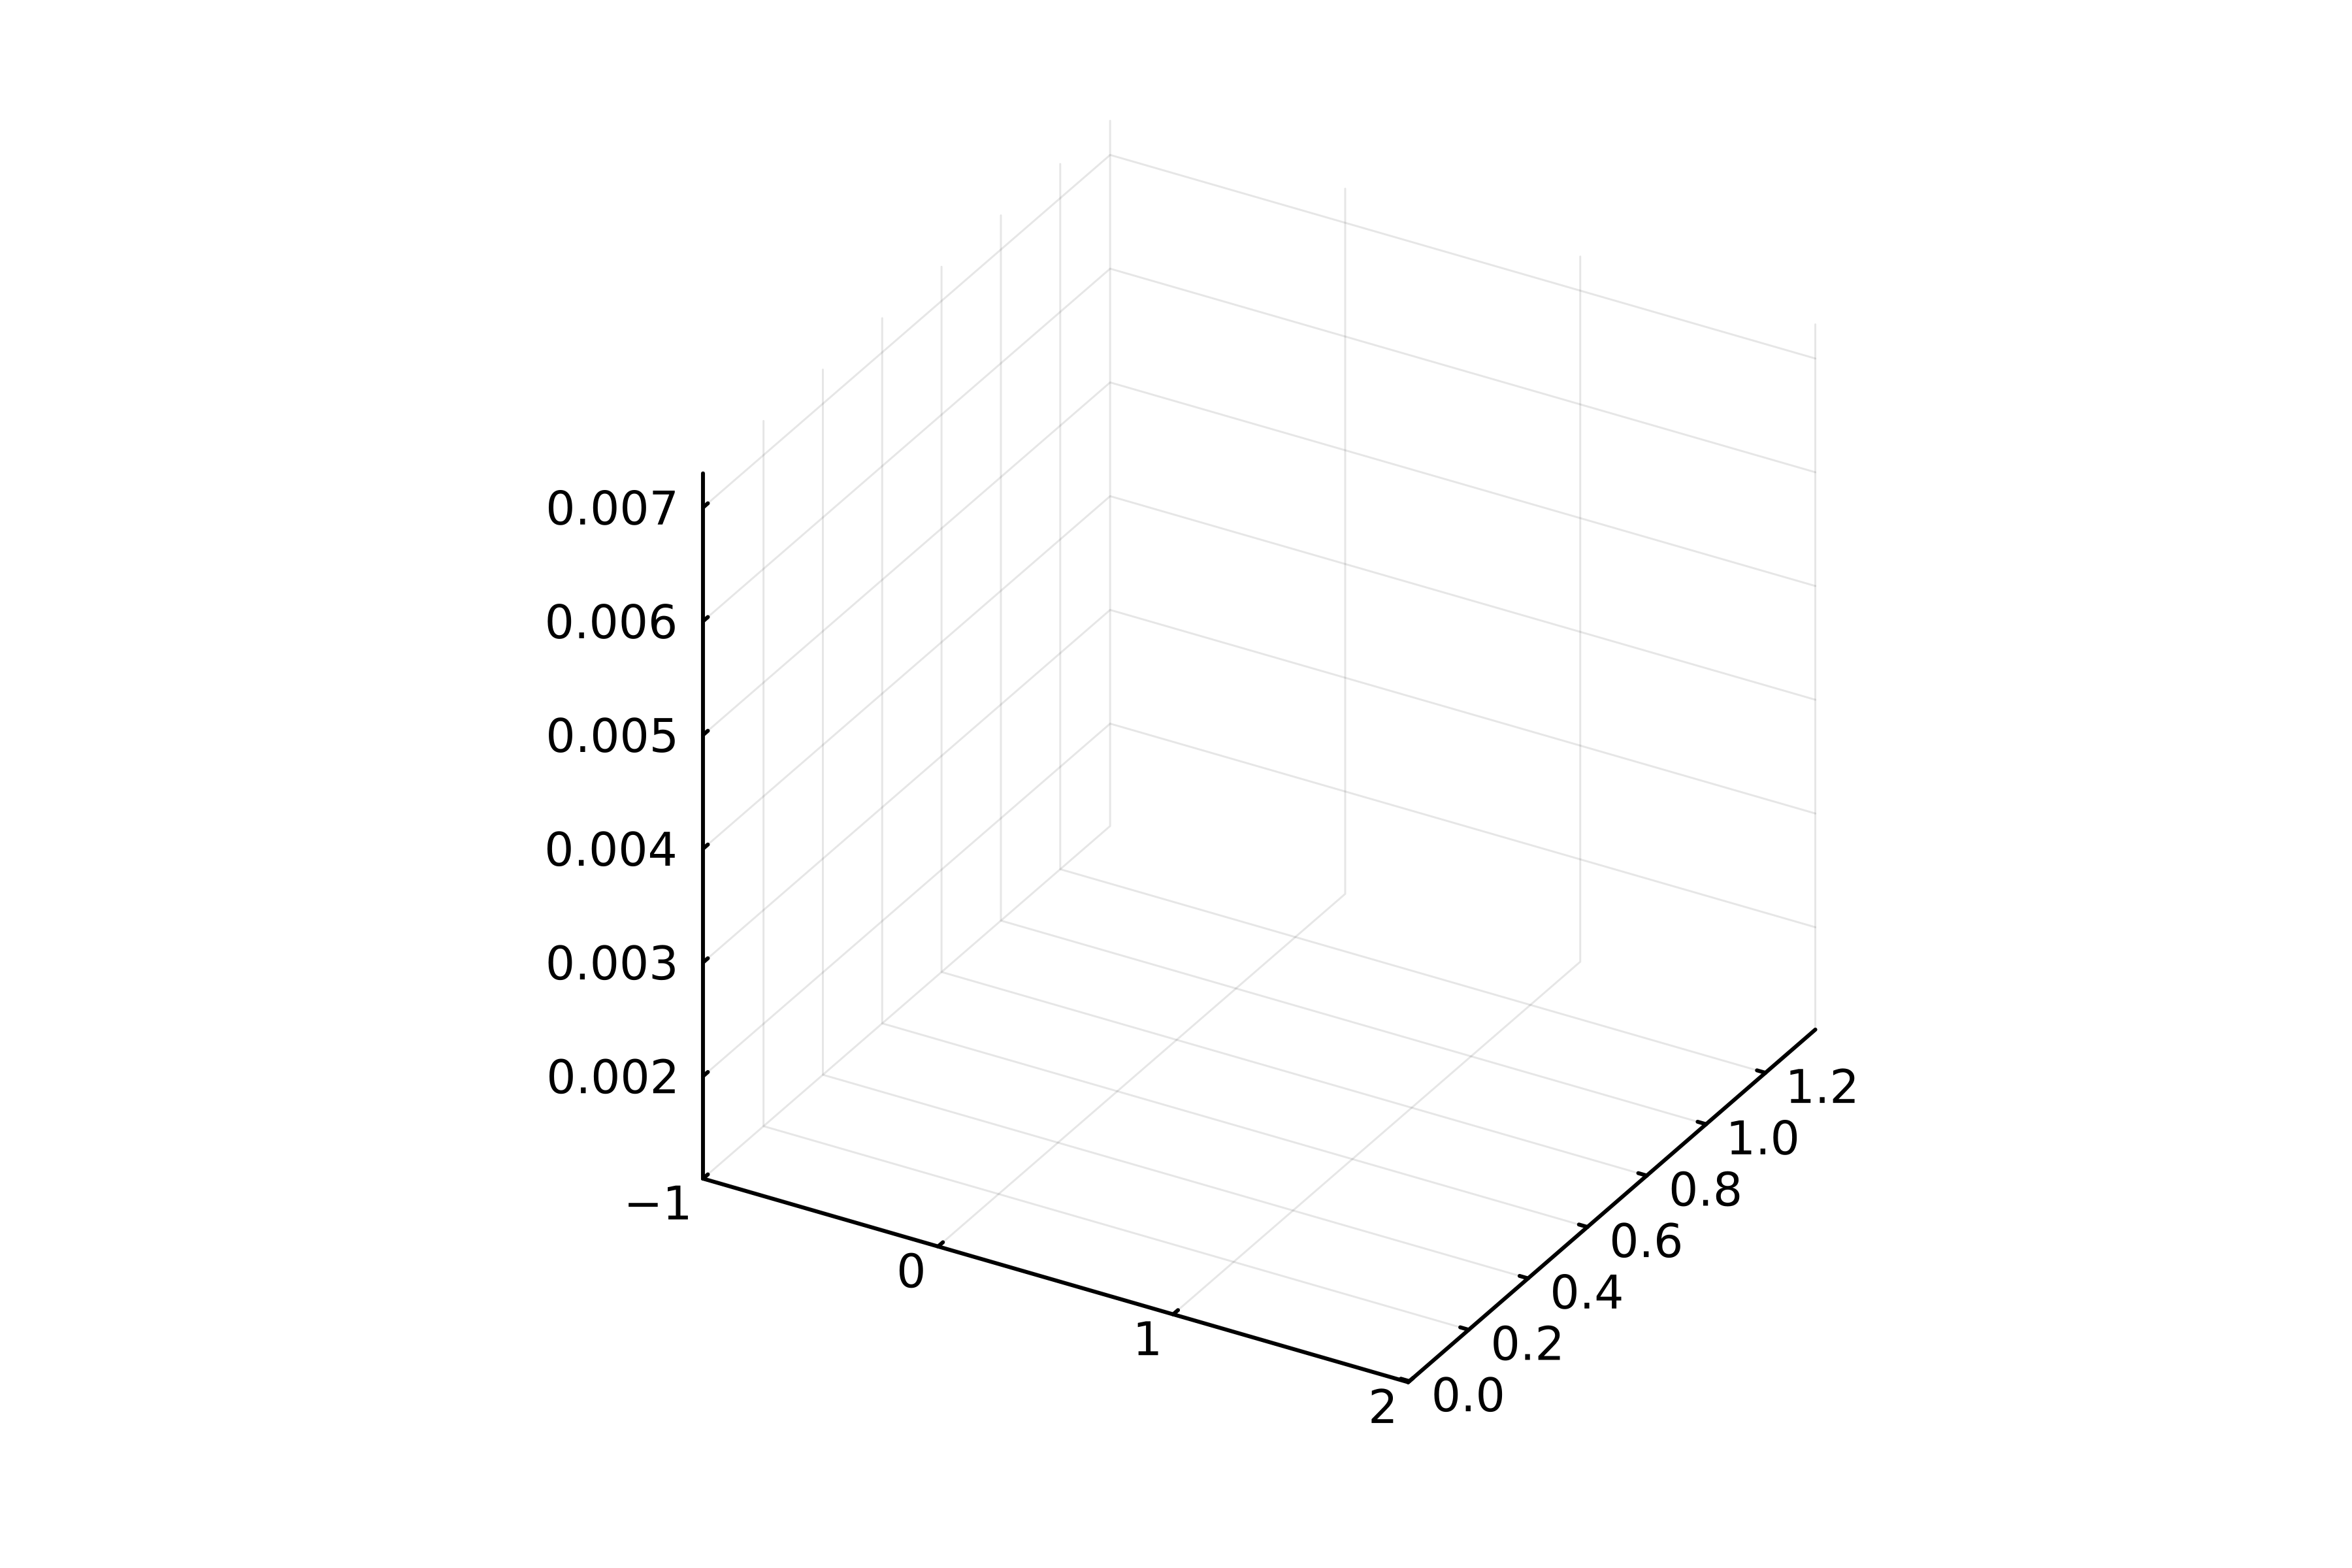

../water.sdf


┌ Info: Saved animation to C:\Users\Dan\AppData\Local\Temp\jl_GDGvWzAdcf.gif
└ @ Plots C:\Users\Dan\.julia\packages\Plots\sxUvK\src\animation.jl:156


In [12]:
tspan = (0f0, 100f0)
for file in readdir("../")
    if endswith(file, ".sdf") && filesize("../"*file) <= 15000 && !occursin("benzene",file)
        sys = load_sdfile("../"*file)
        mm = MMFF94FF(sys)
        first(atoms(mm.system)).r += Vector3(1.0,0,0)
        BA.update!(mm)
        sol = sim_pde(mm, tspan)
        g = plot_pde(sol, mm, tspan, 1000,5)
        println("../"*file)
        display(g)
    end
end 

In [13]:
for file in readdir("../")
    if endswith(file, ".sdf") && filesize("../"*file) <= 15000 && !occursin("adenosine",file)
        @show file

    end end

file = "Conformer3D_COMPOUND_CID_5793.sdf"
file = "GLY_ideal.sdf"
file = "GLY_model.sdf"
file = "Structure2D_COMPOUND_CID_1175.sdf"
file = "Structure2D_COMPOUND_CID_135398635.sdf"
file = "Structure2D_COMPOUND_CID_196182.sdf"
file = "Structure2D_COMPOUND_CID_22568738.sdf"
file = "Structure2D_COMPOUND_CID_56835164.sdf"
file = "Structure2D_COMPOUND_CID_7249.sdf"
file = "Structure2D_COMPOUND_CID_7771.sdf"
file = "Structure2D_COMPOUND_CID_7948.sdf"
file = "Structure2D_COMPOUND_CID_81443.sdf"
file = "Structure2D_COMPOUND_CID_931.sdf"
file = "benzene.sdf"
file = "beta-D-glucose-3D-structure-CT1000926869.sdf"
file = "cpx351.sdf"
file = "glucose.sdf"
file = "octane.sdf"
file = "temp.sdf"
file = "water.sdf"


retest all filesaget pe solver to work properly;get at least a few usable frames

┌ Info: 0 unassigned StretchBends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:274
┌ Info: 0 unassigned bends
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_stretch_bend.jl:349
┌ Info: 2 unassigned Out Of Plane Bends.
└ @ BiochemicalAlgorithms C:\Users\Dan\BiochemicalAlgorithms.jl\src\forcefields\MMFF94\mmff94_out_of_plane_bend.jl:78


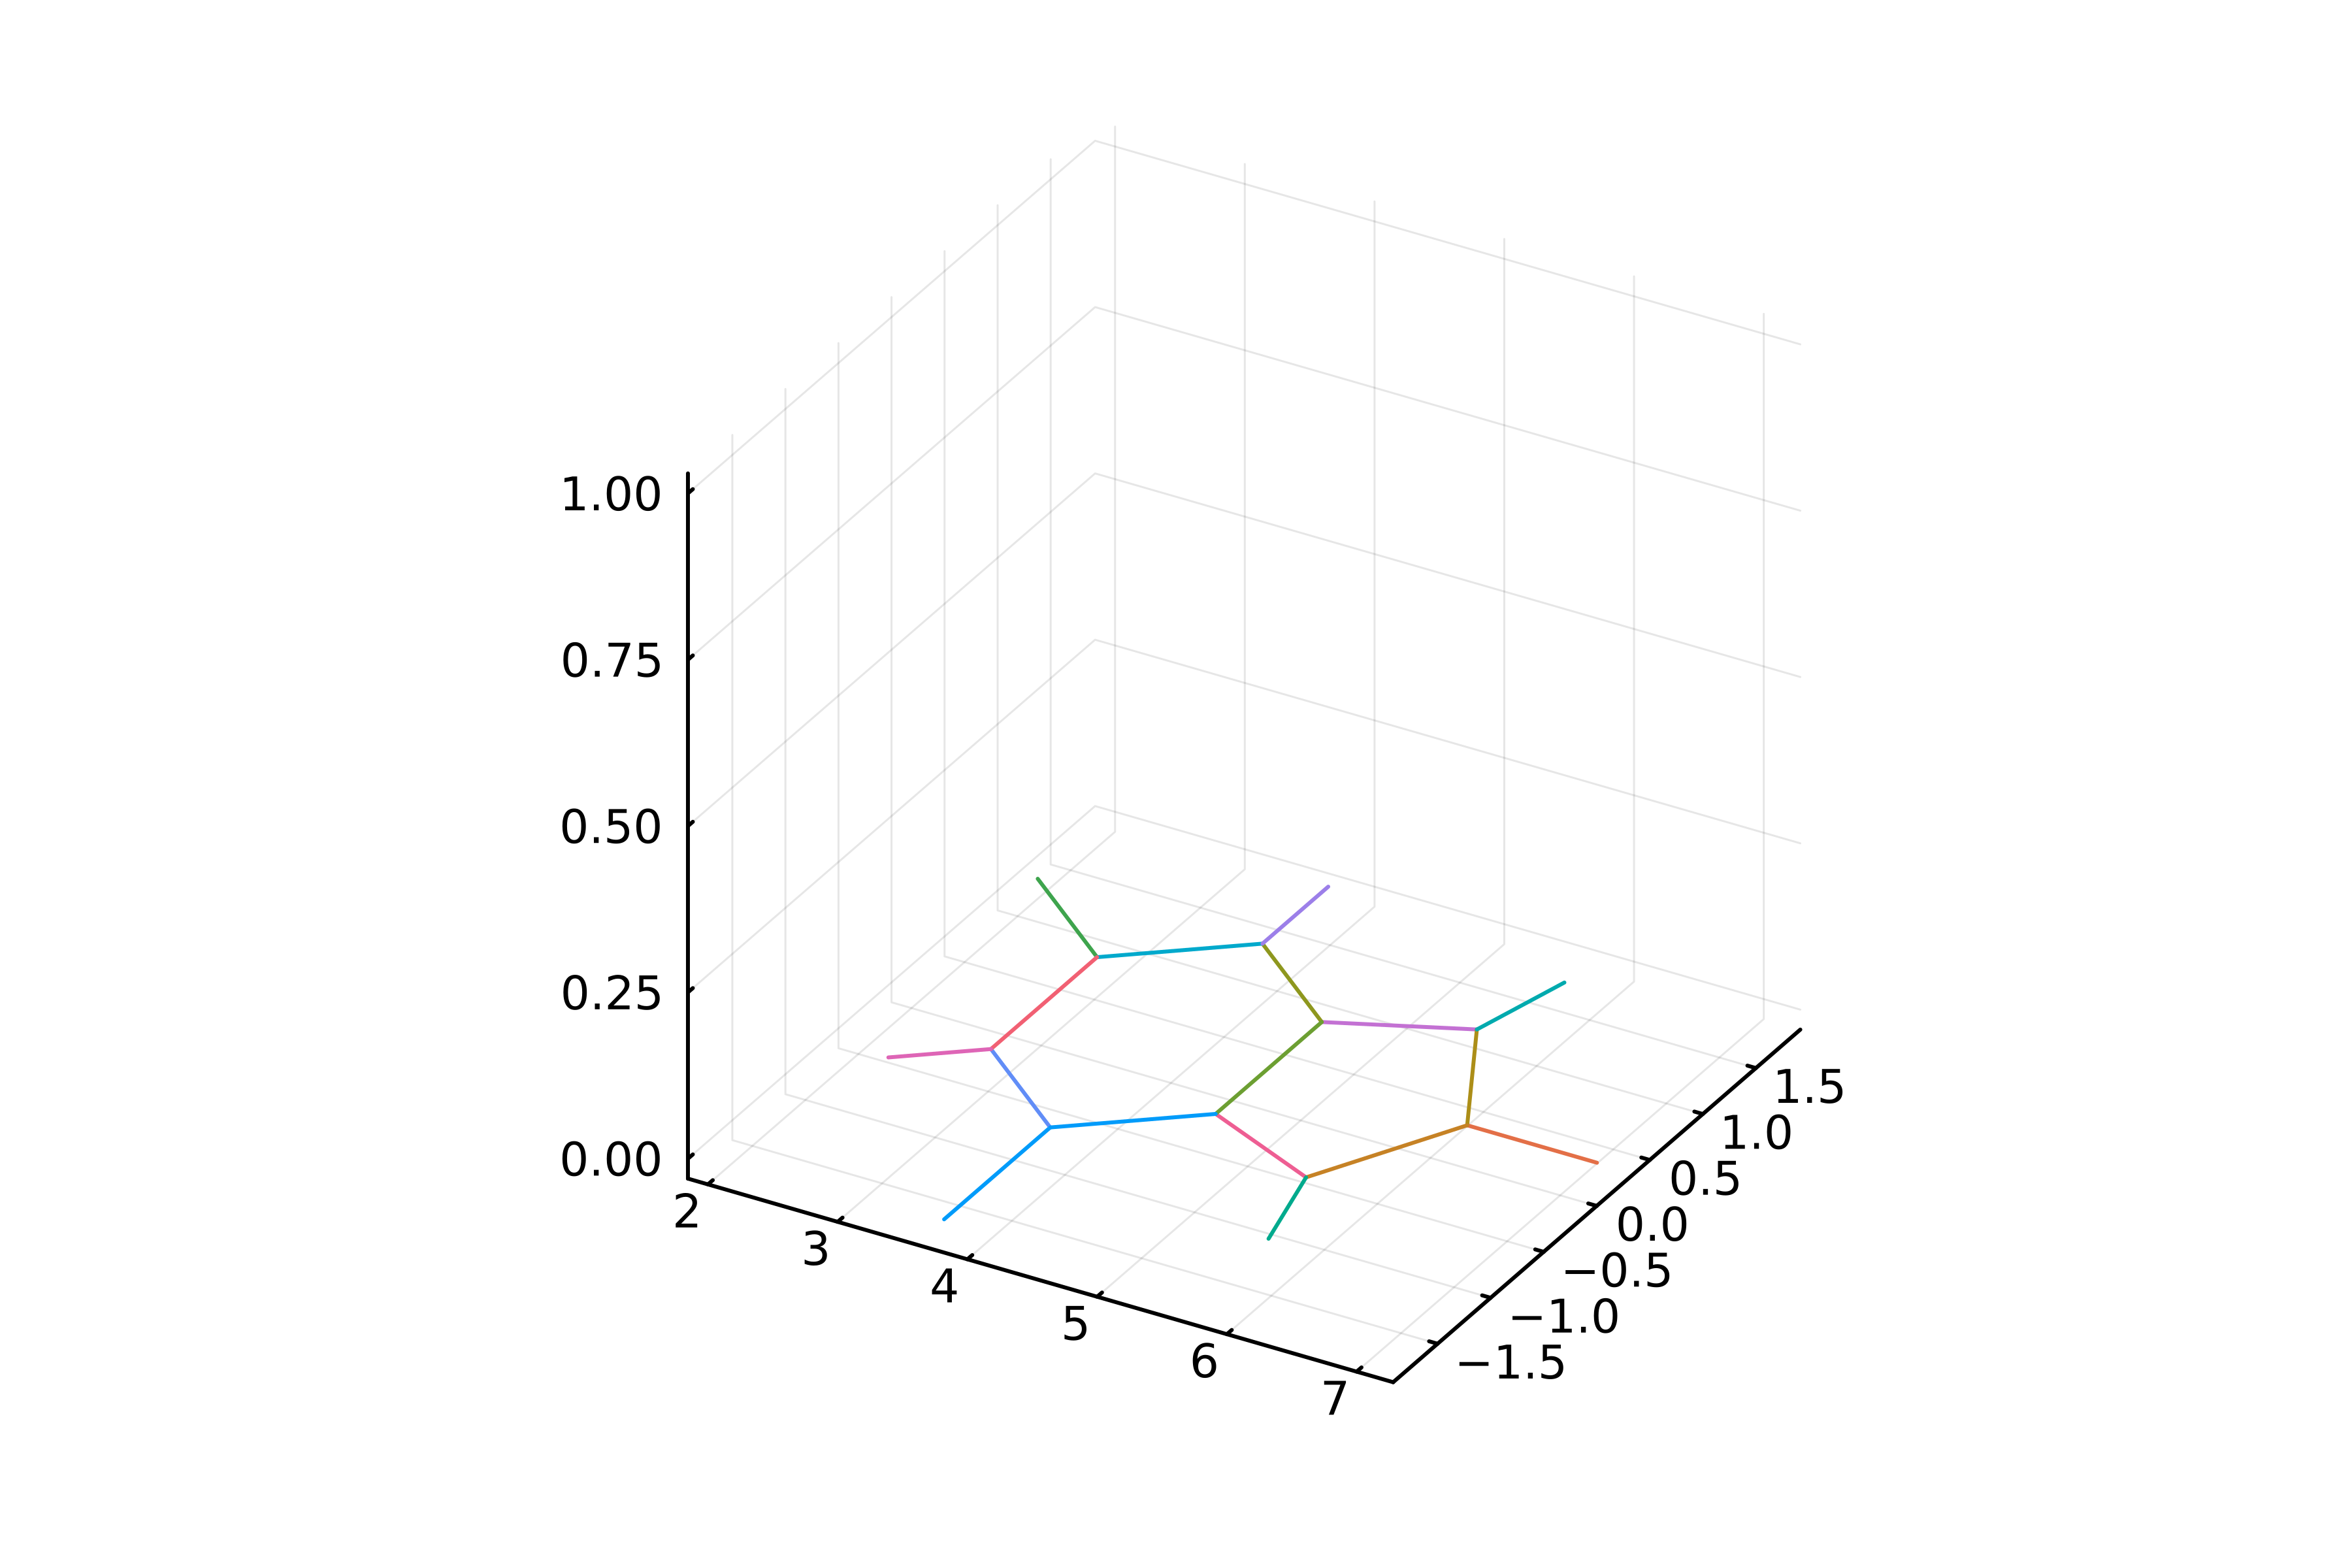

In [ ]:
#pde that works

#algs = [VelocityVerlet, SymplecticEuler, VerletLeapfrog, PseudoVerletLeapfrog, McAte2,]
#for alg in algs
tspan = (0f0, 10000f0)
sys = load_sdfile("../Structure2D_COMPOUND_CID_1175.sdf")
mm = MMFF94FF(sys)
first(atoms(mm.system)).r += Vector3(0,0,0.5)
BA.update!(mm)
sol = sim_pde(mm, tspan, SymplecticEuler, 1e2)
#g = plot_pde(sol, mm, tspan, 1000,1)
g = plot_sol(sol, mm, 1)

println("Integrator: $SymplecticEuler")
display(g)
#end
